<a href="https://colab.research.google.com/github/imrealnow/ForwardContributionTracking-AIML589/blob/main/gp_contribution_tracker.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install --upgrade pandas deap shap ucimlrepo openpyxl xlrd cairosvg
!pip install --force-reinstall --no-deps numpy==2.3.5


  Using cached numpy-2.3.5-cp313-cp313-win_amd64.whl.metadata (60 kB)
Using cached numpy-2.3.5-cp313-cp313-win_amd64.whl (12.8 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 2.3.5
    Uninstalling numpy-2.3.5:
      Successfully uninstalled numpy-2.3.5


## Basic Tests

In [ ]:
from deap import gp
from fcp_tracker import (
    TrackedValue,
    create_tracked_pset,
    evaluate_with_tracking,
    find_counterfactual,
    explain_prediction,
)

from fcp_jupyter_framework import (
    run_all_problems,
    list_problems,
    show_all,
    TestRunner
)

list_problems()

Available FCP Test Problems

Additive Attribution:
  • weighted_sum: 6 test cases
    Symbolic regression: f(x1, x2, x3) = w1*x1 + w2*x2 + w3*x3

Multiplicative Attribution (log-space):
  • multiplicative: 7 test cases
    Symbolic regression: f(x, y, z) = x * y * z
  • mixed_arithmetic: 4 test cases
    Symbolic regression: f(a, b, c, d) = (a + b) * (c + d)

Passthrough Operations:
  • unary_transform: 4 test cases
    Chain of unary transforms: f(x) = sqrt(abs(square(x)))

Polynomial:
  • quadratic: 5 test cases
    Symbolic regression: f(x) = a*x^2 + b*x + c

Conditional (dual-channel):
  • simple_conditional: 7 test cases
    Binary classification: f(x, threshold, a, b) = a if x <= threshold else b
  • nested_conditional: 5 test cases
    Nested conditionals:
  • comparison_as_value: 4 test cases
    Using comparison result as a numeric value:

Min/Max:
  • min_max: 5 test cases
    f(a, b, c) = max(a, min(b, c))

Distance-based Classification:
  • point_in_circle: 10 test cases
  

In [ ]:
runner = TestRunner(
    evaluate_fn=evaluate_with_tracking,
    counterfactual_fn=find_counterfactual
)

results = run_all_problems(runner, create_tracked_pset, TrackedValue, gp, verbose=False)

for key, result in results.items():
    print(f"Problem: {key}")
    show_all(result)

Problem: weighted_sum


TestSuiteResults(problem_name='weighted_sum', timestamp='2026-02-14 23:48:15', results=[AttributionResult(test_case=TestCase(name='equal_inputs', inputs={'x1': 1.0, 'x2': 1.0, 'x3': 1.0}, expected_output=6.0, expected_class=None, description='Attribution should reflect weights: x1=50%, x2=33%, x3=17%', tags=['attribution_test']), output_value=6.0, value_contributions={'x1': 0.5, 'x2': 0.3333333333333333, 'x3': 0.16666666666666666}, decision_contributions={}, decision_margins=[], raw_result=EvaluationResult(output=TrackedValue(6.0000, [x1: 50.00%, x2: 33.33%, x3: 16.67%]), decisions=[], decision_space=None, terminal_values={'x1': 1.0, 'x2': 1.0, 'x3': 1.0}, execution_path=[]), tree_expression='ADD(MUL(w1, x1), ADD(MUL(w2, x2), MUL(w3, x3)))'), AttributionResult(test_case=TestCase(name='x1_dominant', inputs={'x1': 10.0, 'x2': 1.0, 'x3': 1.0}, expected_output=33.0, expected_class=None, description='x1 should dominate attribution (~91%)', tags=['attribution_test']), output_value=33.0, value_contributions={'x1': 0.9090909090909091, 'x2': 0.06060606060606061, 'x3': 0.030303030303030304}, decision_contributions={}, decision_margins=[], raw_result=EvaluationResult(output=TrackedValue(33.0000, [x1: 90.91%, x2: 6.06%, x3: 3.03%]), decisions=[], decision_space=None, terminal_values={'x1': 10.0, 'x2': 1.0, 'x3': 1.0}, execution_path=[]), tree_expression='ADD(MUL(w1, x1), ADD(MUL(w2, x2), MUL(w3, x3)))'), AttributionResult(test_case=TestCase(name='x3_high_value', inputs={'x1': 1.0, 'x2': 1.0, 'x3': 10.0}, expected_output=15.0, expected_class=None, description='Low-weight x3 compensates with high value (~67%)', tags=['attribution_test']), output_value=15.0, value_contributions={'x1': 0.2, 'x2': 0.13333333333333333, 'x3': 0.6666666666377137}, decision_contributions={}, decision_margins=[], raw_result=EvaluationResult(output=TrackedValue(15.0000, [x3: 66.67%, x1: 20.00%, x2: 13.33%]), decisions=[], decision_space=None, terminal_values={'x1': 1.0, 'x2': 1.0, 'x3': 10.0}, execution_path=[]), tree_expression='ADD(MUL(w1, x1), ADD(MUL(w2, x2), MUL(w3, x3)))'), AttributionResult(test_case=TestCase(name='zero_input', inputs={'x1': 0.0, 'x2': 5.0, 'x3': 5.0}, expected_output=15.0, expected_class=None, description='x1 should get 0% attribution', tags=['edge_case']), output_value=15.0, value_contributions={'x1': 0.0, 'x2': 0.6666666666666666, 'x3': 0.33333333331262216}, decision_contributions={}, decision_margins=[], raw_result=EvaluationResult(output=TrackedValue(15.0000, [x2: 66.67%, x3: 33.33%, x1: 0.00%]), decisions=[], decision_space=None, terminal_values={'x1': 0.0, 'x2': 5.0, 'x3': 5.0}, execution_path=[]), tree_expression='ADD(MUL(w1, x1), ADD(MUL(w2, x2), MUL(w3, x3)))'), AttributionResult(test_case=TestCase(name='mixed_signs', inputs={'x1': 2.0, 'x2': -3.0, 'x3': 1.0}, expected_output=1.0, expected_class=None, description='Negative values still contribute by magnitude', tags=['attribution_test']), output_value=1.0, value_contributions={'x1': 0.5454545454545454, 'x2': 0.3896103896103896, 'x3': 0.06493506493506493}, decision_contributions={}, decision_margins=[], raw_result=EvaluationResult(output=TrackedValue(1.0000, [x1: 54.55%, x2: 38.96%, x3: 6.49%]), decisions=[], decision_space=None, terminal_values={'x1': 2.0, 'x2': -3.0, 'x3': 1.0}, execution_path=[]), tree_expression='ADD(MUL(w1, x1), ADD(MUL(w2, x2), MUL(w3, x3)))'), AttributionResult(test_case=TestCase(name='all_equal_contribution', inputs={'x1': 1.0, 'x2': 1.5, 'x3': 3.0}, expected_output=9.0, expected_class=None, description='Designed so all three contribute equally (3*1=2*1.5=1*3)', tags=['attribution_test']), output_value=9.0, value_contributions={'x1': 0.3333333333333333, 'x2': 0.3333333333333333, 'x3': 0.333333333302992}, decision_contributions={}, decision_margins=[], raw_result=EvaluationResult(output=TrackedValue(9.0000, [x1: 33.33%, x2: 33.33%, x3: 33.33%]), decisions=[], decision_space=None, terminal_values={'x1': 1.0, 'x2': 1.5, 'x3': 3.0}, execution_path=[]), tree_expre

x1,+3.0000 ↑,
x2,+2.0000 ↑,
x3,+1.0000 ↑,
Total,6.0000,= Output


x1,+30.0000 ↑,
x2,+2.0000 ↑,
x3,+1.0000 ↑,
Total,33.0000,= Output


x3,+10.0000 ↑,
x1,+3.0000 ↑,
x2,+2.0000 ↑,
Total,15.0000,= Output


x2,+10.0000 ↑,
x3,+5.0000 ↑,
x1,+0.0000 –,
Total,15.0000,= Output


x1,+6.0000 ↑,
x2,-6.0000 ↓,
x3,+1.0000 ↑,
Total,1.0000,= Output


x1,+3.0000 ↑,
x2,+3.0000 ↑,
x3,+3.0000 ↑,
Total,9.0000,= Output


Problem: multiplicative


TestSuiteResults(problem_name='multiplicative', timestamp='2026-02-14 23:48:15', results=[AttributionResult(test_case=TestCase(name='equal_values', inputs={'x': 2.0, 'y': 2.0, 'z': 2.0}, expected_output=8.0, expected_class=None, description='Equal values → equal attribution (~33% each)', tags=['attribution_test']), output_value=8.0, value_contributions={'x': 0.3333333333453558, 'y': 0.3333333333273221, 'z': 0.3333333333273221}, decision_contributions={}, decision_margins=[], raw_result=EvaluationResult(output=TrackedValue(8.0000, [x: 33.33%, y: 33.33%, z: 33.33%]), decisions=[], decision_space=None, terminal_values={'x': 2.0, 'y': 2.0, 'z': 2.0}, execution_path=[]), tree_expression='MUL(x, MUL(y, z))'), AttributionResult(test_case=TestCase(name='x_large', inputs={'x': 10.0, 'y': 1.0, 'z': 1.0}, expected_output=10.0, expected_class=None, description='x=10 vs y,z=1: log(10) vs log(1), x dominates', tags=['attribution_test']), output_value=10.0, value_contributions={'x': 0.9999999999565705, 'y': 2.171472588972382e-11, 'z': 2.171472588972382e-11}, decision_contributions={}, decision_margins=[], raw_result=EvaluationResult(output=TrackedValue(10.0000, [x: 100.00%, y: 0.00%, z: 0.00%]), decisions=[], decision_space=None, terminal_values={'x': 10.0, 'y': 1.0, 'z': 1.0}, execution_path=[]), tree_expression='MUL(x, MUL(y, z))'), AttributionResult(test_case=TestCase(name='z_large', inputs={'x': 1.0, 'y': 1.0, 'z': 10.0}, expected_output=10.0, expected_class=None, description='Same as x_large but z dominates - should be symmetric', tags=['attribution_test']), output_value=10.0, value_contributions={'x': 4.342945177944764e-11, 'y': 4.3429451777561517e-11, 'z': 0.999999999913141}, decision_contributions={}, decision_margins=[], raw_result=EvaluationResult(output=TrackedValue(10.0000, [z: 100.00%, x: 0.00%, y: 0.00%]), decisions=[], decision_space=None, terminal_values={'x': 1.0, 'y': 1.0, 'z': 10.0}, execution_path=[]), tree_expression='MUL(x, MUL(y, z))'), AttributionResult(test_case=TestCase(name='scaling_test', inputs={'x': 10.0, 'y': 10.0, 'z': 1.0}, expected_output=100.0, expected_class=None, description='x and y equal, both larger than z', tags=['attribution_test']), output_value=100.0, value_contributions={'x': 0.5, 'y': 0.49999999997828526, 'z': 2.171472588972382e-11}, decision_contributions={}, decision_margins=[], raw_result=EvaluationResult(output=TrackedValue(100.0000, [x: 50.00%, y: 50.00%, z: 0.00%]), decisions=[], decision_space=None, terminal_values={'x': 10.0, 'y': 10.0, 'z': 1.0}, execution_path=[]), tree_expression='MUL(x, MUL(y, z))'), AttributionResult(test_case=TestCase(name='large_vs_small', inputs={'x': 100.0, 'y': 1.0, 'z': 1.0}, expected_output=100.0, expected_class=None, description='Tests log-space: 100 vs 1 should show strong x dominance', tags=['attribution_test']), output_value=100.0, value_contributions={'x': 0.9999999999782853, 'y': 1.085736294514247e-11, 'z': 1.085736294514247e-11}, decision_contributions={}, decision_margins=[], raw_result=EvaluationResult(output=TrackedValue(100.0000, [x: 100.00%, y: 0.00%, z: 0.00%]), decisions=[], decision_space=None, terminal_values={'x': 100.0, 'y': 1.0, 'z': 1.0}, execution_path=[]), tree_expression='MUL(x, MUL(y, z))'), AttributionResult(test_case=TestCase(name='fractional', inputs={'x': 0.5, 'y': 2.0, 'z': 4.0}, expected_output=4.0, expected_class=None, description='Mixed scales with fraction', tags=['attribution_test']), output_value=4.0, value_contributions={'x': 0.24999999994477182, 'y': 0.25000000002742623, 'z': 0.500000000027802}, decision_contributions={}, decision_margins=[], raw_result=EvaluationResult(output=TrackedValue(4.0000, [z: 50.00%, y: 25.00%, x: 25.00%]), decisions=[], decision_space=None, terminal_values={'x': 0.5, 'y': 2.0, 'z': 4.0}, execution_path=[]), tree_expression='MUL(x, MUL(y, z))'), AttributionResult(test_case=TestCase(name='near_zero', inputs={'x': 0.001, 'y': 1000.0, 'z': 1.0}, expected_output=1.0, expected_class=None, description='E

baseline,+1.0000,
y,+2.4000 ↑,
z,+2.4000 ↑,
x,+2.2000 ↑,
Total,8.0000,= Output


baseline,+1.0000,
x,+9.0000 ↑,
y,+0.0000 –,
z,+0.0000 –,
Total,10.0000,= Output


baseline,+1.0000,
z,+9.0000 ↑,
x,+0.0000 –,
y,+0.0000 –,
Total,10.0000,= Output


baseline,+1.0000,
x,+51.6316 ↑,
y,+47.3684 ↑,
z,+0.0000 –,
Total,100.0000,= Output


baseline,+1.0000,
x,+99.0000 ↑,
y,+0.0000 –,
z,+0.0000 –,
Total,100.0000,= Output


baseline,+1.0000,
z,+2.6667 ↑,
y,+1.0667 ↑,
x,-0.7333 ↓,
Total,4.0000,= Output


baseline,+1.0000,
y,+1.0000 ↑,
x,-1.0000 ↓,
z,+0.0000 –,
Total,1.0000,= Output


Problem: mixed_arithmetic


TestSuiteResults(problem_name='mixed_arithmetic', timestamp='2026-02-14 23:48:15', results=[AttributionResult(test_case=TestCase(name='all_equal', inputs={'a': 1.0, 'b': 1.0, 'c': 1.0, 'd': 1.0}, expected_output=4.0, expected_class=None, description='Symmetric - all should contribute equally (25%)', tags=['attribution_test']), output_value=4.0, value_contributions={'a': 0.25, 'b': 0.25, 'c': 0.25, 'd': 0.25}, decision_contributions={}, decision_margins=[], raw_result=EvaluationResult(output=TrackedValue(4.0000, [a: 25.00%, b: 25.00%, c: 25.00%]), decisions=[], decision_space=None, terminal_values={'a': 1.0, 'b': 1.0, 'c': 1.0, 'd': 1.0}, execution_path=[]), tree_expression='MUL(ADD(a, b), ADD(c, d))'), AttributionResult(test_case=TestCase(name='a_dominant_in_sum', inputs={'a': 10.0, 'b': 1.0, 'c': 1.0, 'd': 1.0}, expected_output=22.0, expected_class=None, description='a dominates (a+b) additively, but (a+b) also larger multiplicatively', tags=['attribution_test']), output_value=22.0, value_contributions={'a': 0.7052328870641232, 'b': 0.07052328870641232, 'c': 0.11212191211473217, 'd': 0.11212191211473217}, decision_contributions={}, decision_margins=[], raw_result=EvaluationResult(output=TrackedValue(22.0000, [a: 70.52%, c: 11.21%, d: 11.21%]), decisions=[], decision_space=None, terminal_values={'a': 10.0, 'b': 1.0, 'c': 1.0, 'd': 1.0}, execution_path=[]), tree_expression='MUL(ADD(a, b), ADD(c, d))'), AttributionResult(test_case=TestCase(name='left_sum_larger', inputs={'a': 5.0, 'b': 5.0, 'c': 1.0, 'd': 1.0}, expected_output=20.0, expected_class=None, description='Left sum (10) vs right sum (2) - affects multiplicative weighting', tags=['attribution_test']), output_value=20.0, value_contributions={'a': 0.3843108934140923, 'b': 0.3843108934140923, 'c': 0.1156891065859077, 'd': 0.1156891065859077}, decision_contributions={}, decision_margins=[], raw_result=EvaluationResult(output=TrackedValue(20.0000, [a: 38.43%, b: 38.43%, c: 11.57%]), decisions=[], decision_space=None, terminal_values={'a': 5.0, 'b': 5.0, 'c': 1.0, 'd': 1.0}, execution_path=[]), tree_expression='MUL(ADD(a, b), ADD(c, d))'), AttributionResult(test_case=TestCase(name='balanced_sums_unequal_terms', inputs={'a': 8.0, 'b': 2.0, 'c': 2.0, 'd': 8.0}, expected_output=100.0, expected_class=None, description='Both sums equal (10), but internal distribution differs', tags=['attribution_test']), output_value=100.0, value_contributions={'a': 0.4, 'b': 0.1, 'c': 0.1, 'd': 0.4}, decision_contributions={}, decision_margins=[], raw_result=EvaluationResult(output=TrackedValue(100.0000, [a: 40.00%, d: 40.00%, b: 10.00%]), decisions=[], decision_space=None, terminal_values={'a': 8.0, 'b': 2.0, 'c': 2.0, 'd': 8.0}, execution_path=[]), tree_expression='MUL(ADD(a, b), ADD(c, d))')], counterfactual_results=[], tree_expression='MUL(ADD(a, b), ADD(c, d))')

baseline,+1.0000,
a,+0.7500 ↑,
b,+0.7500 ↑,
c,+0.7500 ↑,
d,+0.7500 ↑,
Total,4.0000,= Output


baseline,+1.0000,
a,+16.7832 ↑,
b,+1.6783 ↑,
c,+1.2692 ↑,
d,+1.2692 ↑,
Total,22.0000,= Output


baseline,+1.0000,
a,+8.2500 ↑,
b,+8.2500 ↑,
c,+1.2500 ↑,
d,+1.2500 ↑,
Total,20.0000,= Output


baseline,+1.0000,
a,+39.6000 ↑,
d,+39.6000 ↑,
b,+9.9000 ↑,
c,+9.9000 ↑,
Total,100.0000,= Output


Problem: quadratic


TestSuiteResults(problem_name='quadratic', timestamp='2026-02-14 23:48:15', results=[AttributionResult(test_case=TestCase(name='at_zero', inputs={'x': 0.0}, expected_output=1.0, expected_class=None, description='At x=0, only constant term contributes', tags=['polynomial_test']), output_value=1.0, value_contributions={'x': 0.0}, decision_contributions={}, decision_margins=[], raw_result=EvaluationResult(output=TrackedValue(1.0000, [x: 0.00%]), decisions=[], decision_space=None, terminal_values={'x': 0.0}, execution_path=[]), tree_expression='ADD(ADD(MUL(a, SQUARE(x)), MUL(b, x)), c)'), AttributionResult(test_case=TestCase(name='at_one', inputs={'x': 1.0}, expected_output=0.0, expected_class=None, description='', tags=['polynomial_test']), output_value=0.0, value_contributions={'x': 1.0}, decision_contributions={}, decision_margins=[], raw_result=EvaluationResult(output=TrackedValue(0.0000, [x: 100.00%]), decisions=[], decision_space=None, terminal_values={'x': 1.0}, execution_path=[]), tree_expression='ADD(ADD(MUL(a, SQUARE(x)), MUL(b, x)), c)'), AttributionResult(test_case=TestCase(name='at_vertex', inputs={'x': 1.0}, expected_output=0.0, expected_class=None, description='At vertex x=1.00, minimum/maximum of parabola', tags=['polynomial_test']), output_value=0.0, value_contributions={'x': 1.0}, decision_contributions={}, decision_margins=[], raw_result=EvaluationResult(output=TrackedValue(0.0000, [x: 100.00%]), decisions=[], decision_space=None, terminal_values={'x': 1.0}, execution_path=[]), tree_expression='ADD(ADD(MUL(a, SQUARE(x)), MUL(b, x)), c)'), AttributionResult(test_case=TestCase(name='large_x', inputs={'x': 10.0}, expected_output=81.0, expected_class=None, description='Large x, quadratic term dominates', tags=['polynomial_test']), output_value=81.0, value_contributions={'x': 1.0}, decision_contributions={}, decision_margins=[], raw_result=EvaluationResult(output=TrackedValue(81.0000, [x: 100.00%]), decisions=[], decision_space=None, terminal_values={'x': 10.0}, execution_path=[]), tree_expression='ADD(ADD(MUL(a, SQUARE(x)), MUL(b, x)), c)'), AttributionResult(test_case=TestCase(name='negative_x', inputs={'x': -3.0}, expected_output=16.0, expected_class=None, description='', tags=['polynomial_test']), output_value=16.0, value_contributions={'x': 1.0}, decision_contributions={}, decision_margins=[], raw_result=EvaluationResult(output=TrackedValue(16.0000, [x: 100.00%]), decisions=[], decision_space=None, terminal_values={'x': -3.0}, execution_path=[]), tree_expression='ADD(ADD(MUL(a, SQUARE(x)), MUL(b, x)), c)')], counterfactual_results=[], tree_expression='ADD(ADD(MUL(a, SQUARE(x)), MUL(b, x)), c)')

baseline,+1.0000,
x,+0.0000 –,
Total,1.0000,= Output


baseline,+2.0000,
x,-2.0000 ↓,
Total,0.0000,= Output


baseline,+2.0000,
x,-2.0000 ↓,
Total,0.0000,= Output


baseline,+2.0000,
x,+79.0000 ↑,
Total,81.0000,= Output


baseline,+2.0000,
x,+14.0000 ↑,
Total,16.0000,= Output


Problem: unary_transform


TestSuiteResults(problem_name='unary_transform', timestamp='2026-02-14 23:48:15', results=[AttributionResult(test_case=TestCase(name='positive', inputs={'x': 4.0}, expected_output=4.0, expected_class=None, description='x should have 100% value contribution', tags=['passthrough_test']), output_value=4.0, value_contributions={'x': 1.0}, decision_contributions={}, decision_margins=[], raw_result=EvaluationResult(output=TrackedValue(4.0000, [x: 100.00%]), decisions=[], decision_space=None, terminal_values={'x': 4.0}, execution_path=[]), tree_expression='SQRT(ABS(SQUARE(x)))'), AttributionResult(test_case=TestCase(name='negative', inputs={'x': -4.0}, expected_output=4.0, expected_class=None, description='Negative input, x still has 100% attribution', tags=['passthrough_test']), output_value=4.0, value_contributions={'x': 1.0}, decision_contributions={}, decision_margins=[], raw_result=EvaluationResult(output=TrackedValue(4.0000, [x: 100.00%]), decisions=[], decision_space=None, terminal_values={'x': -4.0}, execution_path=[]), tree_expression='SQRT(ABS(SQUARE(x)))'), AttributionResult(test_case=TestCase(name='small', inputs={'x': 0.5}, expected_output=0.5, expected_class=None, description='', tags=['passthrough_test']), output_value=0.5, value_contributions={'x': 1.0}, decision_contributions={}, decision_margins=[], raw_result=EvaluationResult(output=TrackedValue(0.5000, [x: 100.00%]), decisions=[], decision_space=None, terminal_values={'x': 0.5}, execution_path=[]), tree_expression='SQRT(ABS(SQUARE(x)))'), AttributionResult(test_case=TestCase(name='zero', inputs={'x': 0.0}, expected_output=0.0, expected_class=None, description='', tags=['passthrough_test', 'edge_case']), output_value=0.0, value_contributions={'x': 1.0}, decision_contributions={}, decision_margins=[], raw_result=EvaluationResult(output=TrackedValue(0.0000, [x: 100.00%]), decisions=[], decision_space=None, terminal_values={'x': 0.0}, execution_path=[]), tree_expression='SQRT(ABS(SQUARE(x)))')], counterfactual_results=[], tree_expression='SQRT(ABS(SQUARE(x)))')

baseline,+0.2500,
x,+3.7500 ↑,
Total,4.0000,= Output


baseline,+0.2500,
x,+3.7500 ↑,
Total,4.0000,= Output


baseline,+2.0000,
x,-1.5000 ↓,
Total,0.5000,= Output


AttributionResult(test_case=TestCase(name='zero', inputs={'x': 0.0}, expected_output=0.0, expected_class=None, description='', tags=['passthrough_test', 'edge_case']), output_value=0.0, value_contributions={'x': 1.0}, decision_contributions={}, decision_margins=[], raw_result=EvaluationResult(output=TrackedValue(0.0000, [x: 100.00%]), decisions=[], decision_space=None, terminal_values={'x': 0.0}, execution_path=[]), tree_expression=None)

Problem: simple_conditional


TestSuiteResults(problem_name='simple_conditional', timestamp='2026-02-14 23:48:15', results=[AttributionResult(test_case=TestCase(name='condition_true_comfortable', inputs={'x': 3.0, 'threshold': 10.0, 'a': 100.0, 'b': 0.0}, expected_output=100.0, expected_class=None, description='x < threshold: value from a, decision from x & threshold', tags=['decision_test']), output_value=100.0, value_contributions={'a': 1.0}, decision_contributions={'x': 0.23076923076923078, 'threshold': 0.7692307692307693}, decision_margins=[], raw_result=EvaluationResult(output=TrackedValue(100.0000, [a: 100.00%]), decisions=[Decision[0](3 <= 10 → T, power=50.0%)], decision_space=None, terminal_values={'x': 3.0, 'threshold': 10.0, 'a': 100.0, 'b': 0.0}, execution_path=['then']), tree_expression='IFLTE(x, threshold, a, b)'), AttributionResult(test_case=TestCase(name='condition_false_comfortable', inputs={'x': 15.0, 'threshold': 10.0, 'a': 100.0, 'b': 0.0}, expected_output=0.0, expected_class=None, description='x > threshold: value from b, decision from x & threshold', tags=['decision_test']), output_value=0.0, value_contributions={'b': 1.0}, decision_contributions={'x': 0.6, 'threshold': 0.4}, decision_margins=[], raw_result=EvaluationResult(output=TrackedValue(0.0000, [b: 100.00%]), decisions=[Decision[0](15 <= 10 → F, power=50.0%)], decision_space=None, terminal_values={'x': 15.0, 'threshold': 10.0, 'a': 100.0, 'b': 0.0}, execution_path=['else']), tree_expression='IFLTE(x, threshold, a, b)'), AttributionResult(test_case=TestCase(name='condition_true_barely', inputs={'x': 9.9, 'threshold': 10.0, 'a': 100.0, 'b': 0.0}, expected_output=100.0, expected_class=None, description='Just barely true - small margin', tags=['decision_test', 'boundary']), output_value=100.0, value_contributions={'a': 1.0}, decision_contributions={'x': 0.4974874371859297, 'threshold': 0.5025125628140704}, decision_margins=[], raw_result=EvaluationResult(output=TrackedValue(100.0000, [a: 100.00%]), decisions=[Decision[0](9.9 <= 10 → T, power=50.0%)], decision_space=None, terminal_values={'x': 9.9, 'threshold': 10.0, 'a': 100.0, 'b': 0.0}, execution_path=['then']), tree_expression='IFLTE(x, threshold, a, b)'), AttributionResult(test_case=TestCase(name='condition_false_barely', inputs={'x': 10.1, 'threshold': 10.0, 'a': 100.0, 'b': 0.0}, expected_output=0.0, expected_class=None, description='Just barely false - small margin', tags=['decision_test', 'boundary']), output_value=0.0, value_contributions={'b': 1.0}, decision_contributions={'x': 0.5024875621890547, 'threshold': 0.49751243781094523}, decision_margins=[], raw_result=EvaluationResult(output=TrackedValue(0.0000, [b: 100.00%]), decisions=[Decision[0](10.1 <= 10 → F, power=50.0%)], decision_space=None, terminal_values={'x': 10.1, 'threshold': 10.0, 'a': 100.0, 'b': 0.0}, execution_path=['else']), tree_expression='IFLTE(x, threshold, a, b)'), AttributionResult(test_case=TestCase(name='large_x_dominates_decision', inputs={'x': 100.0, 'threshold': 1.0, 'a': 5.0, 'b': 10.0}, expected_output=10.0, expected_class=None, description='x much larger than threshold in decision contribution', tags=['decision_test', 'attribution_test']), output_value=10.0, value_contributions={'b': 1.0}, decision_contributions={'x': 0.9900990099009901, 'threshold': 0.009900990099009901}, decision_margins=[], raw_result=EvaluationResult(output=TrackedValue(10.0000, [b: 100.00%]), decisions=[Decision[0](100 <= 1 → F, power=50.0%)], decision_space=None, terminal_values={'x': 100.0, 'threshold': 1.0, 'a': 5.0, 'b': 10.0}, execution_path=['else']), tree_expression='IFLTE(x, threshold, a, b)'), AttributionResult(test_case=TestCase(name='large_threshold_dominates_decision', inputs={'x': 1.0, 'threshold': 100.0, 'a': 5.0, 'b': 10.0}, expected_output=5.0, expected_class=None, description='threshold much larger than x in decision contribution', tags=['decision_test', 'attribution_test']), output_value=5.0, value_contributions={'a': 1.0}, decision_contributions={'x': 0.

a,+100.0000 ↑,
Total,100.0000,= Output


b,+0.0000 –,
Total,0.0000,= Output


a,+100.0000 ↑,
Total,100.0000,= Output


b,+0.0000 –,
Total,0.0000,= Output


b,+10.0000 ↑,
Total,10.0000,= Output


a,+5.0000 ↑,
Total,5.0000,= Output


a,+100.0000 ↑,
Total,100.0000,= Output


Problem: nested_conditional


TestSuiteResults(problem_name='nested_conditional', timestamp='2026-02-14 23:48:15', results=[AttributionResult(test_case=TestCase(name='outer_true_inner_true', inputs={'x': 1.0, 't1': 5.0, 'y': 1.0, 't2': 5.0, 'a': 100.0, 'b': 50.0, 'c': 0.0}, expected_output=100.0, expected_class=None, description='Both conditions true → a. Decision involves x, t1, y, t2', tags=['decision_test']), output_value=100.0, value_contributions={'a': 1.0}, decision_contributions={'x': 0.16666666666666666, 't1': 0.8333333333333334}, decision_margins=[], raw_result=EvaluationResult(output=TrackedValue(100.0000, [a: 100.00%]), decisions=[Decision[0](1 <= 5 → T, power=50.0%), Decision[0](1 <= 5 → T, power=50.0%)], decision_space=None, terminal_values={'x': 1.0, 't1': 5.0, 'y': 1.0, 't2': 5.0, 'a': 100.0, 'b': 50.0, 'c': 0.0}, execution_path=['then', 'then']), tree_expression='IFLTE(x, t1, IFLTE(y, t2, a, b), c)'), AttributionResult(test_case=TestCase(name='outer_true_inner_false', inputs={'x': 1.0, 't1': 5.0, 'y': 10.0, 't2': 5.0, 'a': 100.0, 'b': 50.0, 'c': 0.0}, expected_output=50.0, expected_class=None, description='Outer true, inner false → b', tags=['decision_test']), output_value=50.0, value_contributions={'b': 1.0}, decision_contributions={'x': 0.16666666666666666, 't1': 0.8333333333333334}, decision_margins=[], raw_result=EvaluationResult(output=TrackedValue(50.0000, [b: 100.00%]), decisions=[Decision[0](10 <= 5 → F, power=50.0%), Decision[0](1 <= 5 → T, power=50.0%)], decision_space=None, terminal_values={'x': 1.0, 't1': 5.0, 'y': 10.0, 't2': 5.0, 'a': 100.0, 'b': 50.0, 'c': 0.0}, execution_path=['else', 'then']), tree_expression='IFLTE(x, t1, IFLTE(y, t2, a, b), c)'), AttributionResult(test_case=TestCase(name='outer_false', inputs={'x': 10.0, 't1': 5.0, 'y': 1.0, 't2': 5.0, 'a': 100.0, 'b': 50.0, 'c': 0.0}, expected_output=0.0, expected_class=None, description='Outer false → c. Inner condition not evaluated', tags=['decision_test']), output_value=0.0, value_contributions={'c': 1.0}, decision_contributions={'x': 0.6666666666666666, 't1': 0.3333333333333333}, decision_margins=[], raw_result=EvaluationResult(output=TrackedValue(0.0000, [c: 100.00%]), decisions=[Decision[0](1 <= 5 → T, power=50.0%), Decision[0](10 <= 5 → F, power=50.0%)], decision_space=None, terminal_values={'x': 10.0, 't1': 5.0, 'y': 1.0, 't2': 5.0, 'a': 100.0, 'b': 50.0, 'c': 0.0}, execution_path=['then', 'else']), tree_expression='IFLTE(x, t1, IFLTE(y, t2, a, b), c)'), AttributionResult(test_case=TestCase(name='outer_barely_true', inputs={'x': 4.9, 't1': 5.0, 'y': 1.0, 't2': 5.0, 'a': 100.0, 'b': 50.0, 'c': 0.0}, expected_output=100.0, expected_class=None, description='Outer condition just barely true', tags=['decision_test', 'boundary']), output_value=100.0, value_contributions={'a': 1.0}, decision_contributions={'x': 0.494949494949495, 't1': 0.5050505050505051}, decision_margins=[], raw_result=EvaluationResult(output=TrackedValue(100.0000, [a: 100.00%]), decisions=[Decision[0](1 <= 5 → T, power=50.0%), Decision[0](4.9 <= 5 → T, power=50.0%)], decision_space=None, terminal_values={'x': 4.9, 't1': 5.0, 'y': 1.0, 't2': 5.0, 'a': 100.0, 'b': 50.0, 'c': 0.0}, execution_path=['then', 'then']), tree_expression='IFLTE(x, t1, IFLTE(y, t2, a, b), c)'), AttributionResult(test_case=TestCase(name='outer_barely_false', inputs={'x': 5.1, 't1': 5.0, 'y': 1.0, 't2': 5.0, 'a': 100.0, 'b': 50.0, 'c': 0.0}, expected_output=0.0, expected_class=None, description='Outer condition just barely false', tags=['decision_test', 'boundary']), output_value=0.0, value_contributions={'c': 1.0}, decision_contributions={'x': 0.504950495049505, 't1': 0.49504950495049505}, decision_margins=[], raw_result=EvaluationResult(output=TrackedValue(0.0000, [c: 100.00%]), decisions=[Decision[0](1 <= 5 → T, power=50.0%), Decision[0](5.1 <= 5 → F, power=50.0%)], decision_space=None, terminal_values={'x': 5.1, 't1': 5.0, 'y': 1.0, 't2': 5.0, 'a': 100.0, 'b': 50.0, 'c': 0.0}, execution_path=['then', 'else']), tree_expressio

a,+100.0000 ↑,
Total,100.0000,= Output


b,+50.0000 ↑,
Total,50.0000,= Output


c,+0.0000 –,
Total,0.0000,= Output


a,+100.0000 ↑,
Total,100.0000,= Output


c,+0.0000 –,
Total,0.0000,= Output


Problem: comparison_as_value


TestSuiteResults(problem_name='comparison_as_value', timestamp='2026-02-14 23:48:15', results=[AttributionResult(test_case=TestCase(name='comparison_true', inputs={'x': 3.0, 'y': 10.0, 'scale': 5.0}, expected_output=5.0, expected_class=None, description='x < y is true, output is scale', tags=['comparison_test']), output_value=5.0, value_contributions={'x': 1.4338499674423877e-11, 'y': 4.7794998914746256e-11, 'scale': 0.9999999999378665}, decision_contributions={'x': 0.23076923076923078, 'y': 0.7692307692307693}, decision_margins=[], raw_result=EvaluationResult(output=TrackedValue(5.0000, [scale: 100.00%, y: 0.00%, x: 0.00%]), decisions=[Decision[0](3 < 10 → T, power=50.0%)], decision_space=None, terminal_values={'x': 3.0, 'y': 10.0, 'scale': 5.0}, execution_path=[]), tree_expression='MUL(LT(x, y), scale)'), AttributionResult(test_case=TestCase(name='comparison_false', inputs={'x': 10.0, 'y': 3.0, 'scale': 5.0}, expected_output=0.0, expected_class=None, description='x < y is false, output is 0', tags=['comparison_test']), output_value=0.0, value_contributions={}, decision_contributions={'x': 0.7692307692307693, 'y': 0.23076923076923078}, decision_margins=[], raw_result=EvaluationResult(output=TrackedValue(0.0000, []), decisions=[Decision[0](10 < 3 → F, power=50.0%)], decision_space=None, terminal_values={'x': 10.0, 'y': 3.0, 'scale': 5.0}, execution_path=[]), tree_expression='MUL(LT(x, y), scale)'), AttributionResult(test_case=TestCase(name='barely_true', inputs={'x': 9.99, 'y': 10.0, 'scale': 100.0}, expected_output=100.0, expected_class=None, description='Just barely x < y', tags=['comparison_test', 'boundary']), output_value=100.0, value_contributions={'x': 1.0851931547971314e-11, 'y': 1.0862794342313629e-11, 'scale': 0.9999999999782853}, decision_contributions={'x': 0.49974987493746875, 'y': 0.5002501250625313}, decision_margins=[], raw_result=EvaluationResult(output=TrackedValue(100.0000, [scale: 100.00%, y: 0.00%, x: 0.00%]), decisions=[Decision[0](9.99 < 10 → T, power=50.0%)], decision_space=None, terminal_values={'x': 9.99, 'y': 10.0, 'scale': 100.0}, execution_path=[]), tree_expression='MUL(LT(x, y), scale)'), AttributionResult(test_case=TestCase(name='barely_false', inputs={'x': 10.01, 'y': 10.0, 'scale': 100.0}, expected_output=0.0, expected_class=None, description='Just barely x >= y', tags=['comparison_test', 'boundary']), output_value=0.0, value_contributions={}, decision_contributions={'x': 0.5002498750624688, 'y': 0.4997501249375313}, decision_margins=[], raw_result=EvaluationResult(output=TrackedValue(0.0000, []), decisions=[Decision[0](10.01 < 10 → F, power=50.0%)], decision_space=None, terminal_values={'x': 10.01, 'y': 10.0, 'scale': 100.0}, execution_path=[]), tree_expression='MUL(LT(x, y), scale)')], counterfactual_results=[], tree_expression='MUL(LT(x, y), scale)')

baseline,+1.0000,
scale,+4.0000 ↑,
x,+0.0000 –,
y,+0.0000 –,
Total,5.0000,= Output


scale,+0.0000 –,
Total,0.0000,= Output


baseline,+1.0000,
scale,+99.0000 ↑,
x,+0.0000 –,
y,+0.0000 –,
Total,100.0000,= Output


scale,+0.0000 –,
Total,0.0000,= Output


Problem: min_max


TestSuiteResults(problem_name='min_max', timestamp='2026-02-14 23:48:15', results=[AttributionResult(test_case=TestCase(name='a_wins', inputs={'a': 10.0, 'b': 5.0, 'c': 3.0}, expected_output=10.0, expected_class=None, description='a > min(b,c), so output is a', tags=['minmax_test']), output_value=10.0, value_contributions={'a': 1.0}, decision_contributions={}, decision_margins=[], raw_result=EvaluationResult(output=TrackedValue(10.0000, [a: 100.00%]), decisions=[Decision[0](5 <= 3 → F, power=50.0%), Decision[0](10 >= 3 → T, power=50.0%)], decision_space=None, terminal_values={'a': 10.0, 'b': 5.0, 'c': 3.0}, execution_path=['right', 'left']), tree_expression='MAX(a, MIN(b, c))'), AttributionResult(test_case=TestCase(name='min_bc_wins', inputs={'a': 1.0, 'b': 5.0, 'c': 3.0}, expected_output=3.0, expected_class=None, description='a < min(b,c)=c, so output is c', tags=['minmax_test']), output_value=3.0, value_contributions={'c': 1.0}, decision_contributions={}, decision_margins=[], raw_result=EvaluationResult(output=TrackedValue(3.0000, [c: 100.00%]), decisions=[Decision[0](5 <= 3 → F, power=50.0%), Decision[0](1 >= 3 → F, power=50.0%)], decision_space=None, terminal_values={'a': 1.0, 'b': 5.0, 'c': 3.0}, execution_path=['right', 'right']), tree_expression='MAX(a, MIN(b, c))'), AttributionResult(test_case=TestCase(name='b_is_min', inputs={'a': 1.0, 'b': 2.0, 'c': 5.0}, expected_output=2.0, expected_class=None, description='min(b,c)=b, and b > a', tags=['minmax_test']), output_value=2.0, value_contributions={'b': 1.0}, decision_contributions={}, decision_margins=[], raw_result=EvaluationResult(output=TrackedValue(2.0000, [b: 100.00%]), decisions=[Decision[0](2 <= 5 → T, power=50.0%), Decision[0](1 >= 2 → F, power=50.0%)], decision_space=None, terminal_values={'a': 1.0, 'b': 2.0, 'c': 5.0}, execution_path=['left', 'right']), tree_expression='MAX(a, MIN(b, c))'), AttributionResult(test_case=TestCase(name='all_equal', inputs={'a': 5.0, 'b': 5.0, 'c': 5.0}, expected_output=5.0, expected_class=None, description='All equal', tags=['minmax_test', 'edge_case']), output_value=5.0, value_contributions={'a': 1.0}, decision_contributions={}, decision_margins=[], raw_result=EvaluationResult(output=TrackedValue(5.0000, [a: 100.00%]), decisions=[Decision[0](5 <= 5 → T, power=50.0%), Decision[0](5 >= 5 → T, power=50.0%)], decision_space=None, terminal_values={'a': 5.0, 'b': 5.0, 'c': 5.0}, execution_path=['left', 'left']), tree_expression='MAX(a, MIN(b, c))'), AttributionResult(test_case=TestCase(name='a_equals_min', inputs={'a': 3.0, 'b': 5.0, 'c': 3.0}, expected_output=3.0, expected_class=None, description='a equals min(b,c) - boundary case', tags=['minmax_test', 'boundary']), output_value=3.0, value_contributions={'a': 1.0}, decision_contributions={}, decision_margins=[], raw_result=EvaluationResult(output=TrackedValue(3.0000, [a: 100.00%]), decisions=[Decision[0](5 <= 3 → F, power=50.0%), Decision[0](3 >= 3 → T, power=50.0%)], decision_space=None, terminal_values={'a': 3.0, 'b': 5.0, 'c': 3.0}, execution_path=['right', 'left']), tree_expression='MAX(a, MIN(b, c))')], counterfactual_results=[], tree_expression='MAX(a, MIN(b, c))')

a,+10.0000 ↑,
Total,10.0000,= Output


c,+3.0000 ↑,
Total,3.0000,= Output


b,+2.0000 ↑,
Total,2.0000,= Output


a,+5.0000 ↑,
Total,5.0000,= Output


a,+3.0000 ↑,
Total,3.0000,= Output


Problem: point_in_circle


TestSuiteResults(problem_name='point_in_circle', timestamp='2026-02-14 23:48:15', results=[AttributionResult(test_case=TestCase(name='inside_comfortable', inputs={'cx': 5.0, 'cy': 5.0, 'r': 3.0, 'px': 6.0, 'py': 5.5}, expected_output=None, expected_class=1, description='', tags=['inside', 'standard']), output_value=1.0, value_contributions={}, decision_contributions={'cx': 0.0987261919647946, 'px': 0.11847143035775351, 'cy': 0.025856859800303344, 'py': 0.028442545780333686, 'r': 0.7285029720968149}, decision_margins=[], raw_result=EvaluationResult(output=TrackedValue(1.0000, []), decisions=[Decision[0](1.118 <= 3 → T, power=50.0%)], decision_space=None, terminal_values={'cx': 5.0, 'cy': 5.0, 'r': 3.0, 'px': 6.0, 'py': 5.5}, execution_path=['then']), tree_expression='IFLTE(SQRT(ADD(SQUARE(SUB(cx, px)), SQUARE(SUB(cy, py)))), r, ONE, ZERO)'), AttributionResult(test_case=TestCase(name='outside_comfortable', inputs={'cx': 5.0, 'cy': 5.0, 'r': 3.0, 'px': 10.0, 'py': 5.0}, expected_output=None, expected_class=0, description='', tags=['outside', 'standard']), output_value=0.0, value_contributions={}, decision_contributions={'cx': 0.20833333333333331, 'px': 0.41666666666666663, 'cy': 0.0, 'py': 0.0, 'r': 0.375}, decision_margins=[], raw_result=EvaluationResult(output=TrackedValue(0.0000, []), decisions=[Decision[0](5 <= 3 → F, power=50.0%)], decision_space=None, terminal_values={'cx': 5.0, 'cy': 5.0, 'r': 3.0, 'px': 10.0, 'py': 5.0}, execution_path=['else']), tree_expression='IFLTE(SQRT(ADD(SQUARE(SUB(cx, px)), SQUARE(SUB(cy, py)))), r, ONE, ZERO)'), AttributionResult(test_case=TestCase(name='outside_barely', inputs={'cx': 5.0, 'cy': 5.0, 'r': 3.0, 'px': 8.1, 'py': 5.0}, expected_output=None, expected_class=0, description='', tags=['outside', 'boundary']), output_value=0.0, value_contributions={}, decision_contributions={'cx': 0.19396821424102118, 'px': 0.3142285070704543, 'cy': 0.0, 'py': 0.0, 'r': 0.49180327868852464}, decision_margins=[], raw_result=EvaluationResult(output=TrackedValue(0.0000, []), decisions=[Decision[0](3.1 <= 3 → F, power=50.0%)], decision_space=None, terminal_values={'cx': 5.0, 'cy': 5.0, 'r': 3.0, 'px': 8.1, 'py': 5.0}, execution_path=['else']), tree_expression='IFLTE(SQRT(ADD(SQUARE(SUB(cx, px)), SQUARE(SUB(cy, py)))), r, ONE, ZERO)'), AttributionResult(test_case=TestCase(name='inside_barely', inputs={'cx': 5.0, 'cy': 5.0, 'r': 3.0, 'px': 7.9, 'py': 5.0}, expected_output=None, expected_class=1, description='', tags=['inside', 'boundary']), output_value=1.0, value_contributions={}, decision_contributions={'cx': 0.1905137301274471, 'px': 0.3010116936013664, 'cy': 0.0, 'py': 0.0, 'r': 0.5084745762711864}, decision_margins=[], raw_result=EvaluationResult(output=TrackedValue(1.0000, []), decisions=[Decision[0](2.9 <= 3 → T, power=50.0%)], decision_space=None, terminal_values={'cx': 5.0, 'cy': 5.0, 'r': 3.0, 'px': 7.9, 'py': 5.0}, execution_path=['then']), tree_expression='IFLTE(SQRT(ADD(SQUARE(SUB(cx, px)), SQUARE(SUB(cy, py)))), r, ONE, ZERO)'), AttributionResult(test_case=TestCase(name='on_boundary', inputs={'cx': 5.0, 'cy': 5.0, 'r': 3.0, 'px': 8.0, 'py': 5.0}, expected_output=None, expected_class=1, description='', tags=['boundary', 'edge_case']), output_value=1.0, value_contributions={}, decision_contributions={'cx': 0.19230769230769232, 'px': 0.3076923076923077, 'cy': 0.0, 'py': 0.0, 'r': 0.5}, decision_margins=[], raw_result=EvaluationResult(output=TrackedValue(1.0000, []), decisions=[Decision[0](3 <= 3 → T, power=50.0%)], decision_space=None, terminal_values={'cx': 5.0, 'cy': 5.0, 'r': 3.0, 'px': 8.0, 'py': 5.0}, execution_path=['then']), tree_expression='IFLTE(SQRT(ADD(SQUARE(SUB(cx, px)), SQUARE(SUB(cy, py)))), r, ONE, ZERO)'), AttributionResult(test_case=TestCase(name='at_center', inputs={'cx': 5.0, 'cy': 5.0, 'r': 3.0, 'px': 5.0, 'py': 5.0}, expected_output=None, expected_class=1, description='', tags=['inside', 'edge_case']), output_value=1.0, value_contributions={}, decision_contributions={'py': 0.0, 

baseline,+1.0000,
Total,1.0000,= Output


AttributionResult(test_case=TestCase(name='outside_comfortable', inputs={'cx': 5.0, 'cy': 5.0, 'r': 3.0, 'px': 10.0, 'py': 5.0}, expected_output=None, expected_class=0, description='', tags=['outside', 'standard']), output_value=0.0, value_contributions={}, decision_contributions={'cx': 0.20833333333333331, 'px': 0.41666666666666663, 'cy': 0.0, 'py': 0.0, 'r': 0.375}, decision_margins=[], raw_result=EvaluationResult(output=TrackedValue(0.0000, []), decisions=[Decision[0](5 <= 3 → F, power=50.0%)], decision_space=None, terminal_values={'cx': 5.0, 'cy': 5.0, 'r': 3.0, 'px': 10.0, 'py': 5.0}, execution_path=['else']), tree_expression=None)

AttributionResult(test_case=TestCase(name='outside_barely', inputs={'cx': 5.0, 'cy': 5.0, 'r': 3.0, 'px': 8.1, 'py': 5.0}, expected_output=None, expected_class=0, description='', tags=['outside', 'boundary']), output_value=0.0, value_contributions={}, decision_contributions={'cx': 0.19396821424102118, 'px': 0.3142285070704543, 'cy': 0.0, 'py': 0.0, 'r': 0.49180327868852464}, decision_margins=[], raw_result=EvaluationResult(output=TrackedValue(0.0000, []), decisions=[Decision[0](3.1 <= 3 → F, power=50.0%)], decision_space=None, terminal_values={'cx': 5.0, 'cy': 5.0, 'r': 3.0, 'px': 8.1, 'py': 5.0}, execution_path=['else']), tree_expression=None)

baseline,+1.0000,
Total,1.0000,= Output


baseline,+1.0000,
Total,1.0000,= Output


baseline,+1.0000,
Total,1.0000,= Output


baseline,+1.0000,
Total,1.0000,= Output


baseline,+1.0000,
Total,1.0000,= Output


baseline,+1.0000,
Total,1.0000,= Output


AttributionResult(test_case=TestCase(name='small_radius', inputs={'cx': 0.0, 'cy': 0.0, 'r': 1.0, 'px': 10.0, 'py': 10.0}, expected_output=None, expected_class=0, description='Displacement dominates decision', tags=['outside', 'attribution_test']), output_value=0.0, value_contributions={}, decision_contributions={'cx': 0.0, 'px': 0.4669795587343443, 'cy': 0.0, 'py': 0.4669795587343443, 'r': 0.06604088253131131}, decision_margins=[], raw_result=EvaluationResult(output=TrackedValue(0.0000, []), decisions=[Decision[0](14.14 <= 1 → F, power=50.0%)], decision_space=None, terminal_values={'cx': 0.0, 'cy': 0.0, 'r': 1.0, 'px': 10.0, 'py': 10.0}, execution_path=['else']), tree_expression=None)

Problem: distance_3d


TestSuiteResults(problem_name='distance_3d', timestamp='2026-02-14 23:48:15', results=[AttributionResult(test_case=TestCase(name='inside_origin', inputs={'cx': 0.0, 'cy': 0.0, 'cz': 0.0, 'px': 1.0, 'py': 1.0, 'pz': 1.0, 'r': 3.0}, expected_output=None, expected_class=1, description='Point (1,1,1) within r=3 of origin', tags=['3d_test']), output_value=1.0, value_contributions={}, decision_contributions={'cx': 0.0, 'px': 0.12200846792814621, 'cy': 0.0, 'py': 0.12200846792814621, 'cz': 0.0, 'pz': 0.12200846792814621, 'r': 0.6339745962155614}, decision_margins=[], raw_result=EvaluationResult(output=TrackedValue(1.0000, []), decisions=[Decision[0](1.732 <= 3 → T, power=50.0%)], decision_space=None, terminal_values={'cx': 0.0, 'cy': 0.0, 'cz': 0.0, 'px': 1.0, 'py': 1.0, 'pz': 1.0, 'r': 3.0}, execution_path=['then']), tree_expression='IFLTE(SQRT(ADD(ADD(SQUARE(SUB(cx, px)), SQUARE(SUB(cy, py))), SQUARE(SUB(cz, pz)))), r, ONE, ZERO)'), AttributionResult(test_case=TestCase(name='outside', inputs={'cx': 0.0, 'cy': 0.0, 'cz': 0.0, 'px': 5.0, 'py': 5.0, 'pz': 5.0, 'r': 3.0}, expected_output=None, expected_class=0, description='Point (5,5,5) outside r=3 sphere', tags=['3d_test']), output_value=0.0, value_contributions={}, decision_contributions={'cx': 0.0, 'px': 0.24757190851750932, 'cy': 0.0, 'py': 0.24757190851750932, 'cz': 0.0, 'pz': 0.24757190851750932, 'r': 0.2572842744474721}, decision_margins=[], raw_result=EvaluationResult(output=TrackedValue(0.0000, []), decisions=[Decision[0](8.66 <= 3 → F, power=50.0%)], decision_space=None, terminal_values={'cx': 0.0, 'cy': 0.0, 'cz': 0.0, 'px': 5.0, 'py': 5.0, 'pz': 5.0, 'r': 3.0}, execution_path=['else']), tree_expression='IFLTE(SQRT(ADD(ADD(SQUARE(SUB(cx, px)), SQUARE(SUB(cy, py))), SQUARE(SUB(cz, pz)))), r, ONE, ZERO)'), AttributionResult(test_case=TestCase(name='z_dominant', inputs={'cx': 0.0, 'cy': 0.0, 'cz': 0.0, 'px': 0.1, 'py': 0.1, 'pz': 4.0, 'r': 5.0}, expected_output=None, expected_class=1, description='Z-displacement dominates distance', tags=['3d_test', 'attribution_test']), output_value=1.0, value_contributions={}, decision_contributions={'cx': 0.0, 'px': 0.0002775272624273598, 'cy': 0.0, 'py': 0.0002775272624273598, 'cz': 0.0, 'pz': 0.4440436198837756, 'r': 0.5554013255913696}, decision_margins=[], raw_result=EvaluationResult(output=TrackedValue(1.0000, []), decisions=[Decision[0](4.002 <= 5 → T, power=50.0%)], decision_space=None, terminal_values={'cx': 0.0, 'cy': 0.0, 'cz': 0.0, 'px': 0.1, 'py': 0.1, 'pz': 4.0, 'r': 5.0}, execution_path=['then']), tree_expression='IFLTE(SQRT(ADD(ADD(SQUARE(SUB(cx, px)), SQUARE(SUB(cy, py))), SQUARE(SUB(cz, pz)))), r, ONE, ZERO)'), AttributionResult(test_case=TestCase(name='on_surface', inputs={'cx': 0.0, 'cy': 0.0, 'cz': 0.0, 'px': 3.0, 'py': 0.0, 'pz': 0.0, 'r': 3.0}, expected_output=None, expected_class=1, description='Exactly on sphere surface', tags=['3d_test', 'boundary']), output_value=1.0, value_contributions={}, decision_contributions={'cx': 0.0, 'px': 0.5, 'py': 0.0, 'cy': 0.0, 'cz': 0.0, 'pz': 0.0, 'r': 0.5}, decision_margins=[], raw_result=EvaluationResult(output=TrackedValue(1.0000, []), decisions=[Decision[0](3 <= 3 → T, power=50.0%)], decision_space=None, terminal_values={'cx': 0.0, 'cy': 0.0, 'cz': 0.0, 'px': 3.0, 'py': 0.0, 'pz': 0.0, 'r': 3.0}, execution_path=['then']), tree_expression='IFLTE(SQRT(ADD(ADD(SQUARE(SUB(cx, px)), SQUARE(SUB(cy, py))), SQUARE(SUB(cz, pz)))), r, ONE, ZERO)')], counterfactual_results=[], tree_expression='IFLTE(SQRT(ADD(ADD(SQUARE(SUB(cx, px)), SQUARE(SUB(cy, py))), SQUARE(SUB(cz, pz)))), r, ONE, ZERO)')

baseline,+1.0000,
Total,1.0000,= Output


AttributionResult(test_case=TestCase(name='outside', inputs={'cx': 0.0, 'cy': 0.0, 'cz': 0.0, 'px': 5.0, 'py': 5.0, 'pz': 5.0, 'r': 3.0}, expected_output=None, expected_class=0, description='Point (5,5,5) outside r=3 sphere', tags=['3d_test']), output_value=0.0, value_contributions={}, decision_contributions={'cx': 0.0, 'px': 0.24757190851750932, 'cy': 0.0, 'py': 0.24757190851750932, 'cz': 0.0, 'pz': 0.24757190851750932, 'r': 0.2572842744474721}, decision_margins=[], raw_result=EvaluationResult(output=TrackedValue(0.0000, []), decisions=[Decision[0](8.66 <= 3 → F, power=50.0%)], decision_space=None, terminal_values={'cx': 0.0, 'cy': 0.0, 'cz': 0.0, 'px': 5.0, 'py': 5.0, 'pz': 5.0, 'r': 3.0}, execution_path=['else']), tree_expression=None)

baseline,+1.0000,
Total,1.0000,= Output


baseline,+1.0000,
Total,1.0000,= Output


Problem: credit_score


TestSuiteResults(problem_name='credit_score', timestamp='2026-02-14 23:48:15', results=[AttributionResult(test_case=TestCase(name='high_income_approved', inputs={'income': 100000.0, 'debt': 10000.0, 'age': 35.0, 'threshold': 700.0}, expected_output=None, expected_class=1, description='High income ($100k), low debt → approved', tags=['real_world']), output_value=1.0, value_contributions={}, decision_contributions={'threshold': 0.3218390804597701, 'income': 0.5273833671399594, 'debt': 0.07031778228532792, 'age': 0.08045977011494253}, decision_margins=[], raw_result=EvaluationResult(output=TrackedValue(1.0000, []), decisions=[Decision[0](700 <= 1475 → T, power=50.0%)], decision_space=None, terminal_values={'income': 100000.0, 'debt': 10000.0, 'age': 35.0, 'threshold': 700.0}, execution_path=['then']), tree_expression='IFLTE(threshold, ADD(ADD(ADD(BASE, MUL(INCOME_WEIGHT, income)), NEG(MUL(DEBT_WEIGHT, debt))), MUL(AGE_BONUS, age)), ONE, ZERO)'), AttributionResult(test_case=TestCase(name='high_debt_denied', inputs={'income': 50000.0, 'debt': 80000.0, 'age': 25.0, 'threshold': 700.0}, expected_output=None, expected_class=0, description='Moderate income but high debt → denied', tags=['real_world']), output_value=0.0, value_contributions={}, decision_contributions={'threshold': 0.5957446808510638, 'income': 0.128675433150855, 'debt': 0.20588069304136802, 'age': 0.06969919295671313}, decision_margins=[], raw_result=EvaluationResult(output=TrackedValue(0.0000, []), decisions=[Decision[0](700 <= -475 → F, power=50.0%)], decision_space=None, terminal_values={'income': 50000.0, 'debt': 80000.0, 'age': 25.0, 'threshold': 700.0}, execution_path=['else']), tree_expression='IFLTE(threshold, ADD(ADD(ADD(BASE, MUL(INCOME_WEIGHT, income)), NEG(MUL(DEBT_WEIGHT, debt))), MUL(AGE_BONUS, age)), ONE, ZERO)'), AttributionResult(test_case=TestCase(name='young_low_income', inputs={'income': 30000.0, 'debt': 5000.0, 'age': 22.0, 'threshold': 600.0}, expected_output=None, expected_class=1, description='Young, low income but also low debt', tags=['real_world']), output_value=1.0, value_contributions={}, decision_contributions={'threshold': 0.425531914893617, 'income': 0.4412923561859732, 'debt': 0.05516154452324665, 'age': 0.07801418439716312}, decision_margins=[], raw_result=EvaluationResult(output=TrackedValue(1.0000, []), decisions=[Decision[0](600 <= 810 → T, power=50.0%)], decision_space=None, terminal_values={'income': 30000.0, 'debt': 5000.0, 'age': 22.0, 'threshold': 600.0}, execution_path=['then']), tree_expression='IFLTE(threshold, ADD(ADD(ADD(BASE, MUL(INCOME_WEIGHT, income)), NEG(MUL(DEBT_WEIGHT, debt))), MUL(AGE_BONUS, age)), ONE, ZERO)'), AttributionResult(test_case=TestCase(name='borderline', inputs={'income': 60000.0, 'debt': 30000.0, 'age': 30.0, 'threshold': 710.0}, expected_output=None, expected_class=0, description='Score ~700, threshold 710 → just denied', tags=['real_world', 'boundary']), output_value=0.0, value_contributions={}, decision_contributions={'threshold': 0.5220588235294118, 'income': 0.23788927335640142, 'debt': 0.12975778546712805, 'age': 0.11029411764705883}, decision_margins=[], raw_result=EvaluationResult(output=TrackedValue(0.0000, []), decisions=[Decision[0](710 <= 650 → F, power=50.0%)], decision_space=None, terminal_values={'income': 60000.0, 'debt': 30000.0, 'age': 30.0, 'threshold': 710.0}, execution_path=['else']), tree_expression='IFLTE(threshold, ADD(ADD(ADD(BASE, MUL(INCOME_WEIGHT, income)), NEG(MUL(DEBT_WEIGHT, debt))), MUL(AGE_BONUS, age)), ONE, ZERO)'), AttributionResult(test_case=TestCase(name='age_compensates', inputs={'income': 40000.0, 'debt': 20000.0, 'age': 55.0, 'threshold': 650.0}, expected_output=None, expected_class=1, description='Lower income but age bonus helps', tags=['real_world', 'attribution_test']), output_value=1.0, value_contributions={}, decision_contributions={'threshold': 0.45614035087719296, 'income': 0.24291497975708504, 'debt': 0.10796221322537113, 'age': 0.1929824561403509}, deci

baseline,+1.0000,
Total,1.0000,= Output


AttributionResult(test_case=TestCase(name='high_debt_denied', inputs={'income': 50000.0, 'debt': 80000.0, 'age': 25.0, 'threshold': 700.0}, expected_output=None, expected_class=0, description='Moderate income but high debt → denied', tags=['real_world']), output_value=0.0, value_contributions={}, decision_contributions={'threshold': 0.5957446808510638, 'income': 0.128675433150855, 'debt': 0.20588069304136802, 'age': 0.06969919295671313}, decision_margins=[], raw_result=EvaluationResult(output=TrackedValue(0.0000, []), decisions=[Decision[0](700 <= -475 → F, power=50.0%)], decision_space=None, terminal_values={'income': 50000.0, 'debt': 80000.0, 'age': 25.0, 'threshold': 700.0}, execution_path=['else']), tree_expression=None)

baseline,+1.0000,
Total,1.0000,= Output


AttributionResult(test_case=TestCase(name='borderline', inputs={'income': 60000.0, 'debt': 30000.0, 'age': 30.0, 'threshold': 710.0}, expected_output=None, expected_class=0, description='Score ~700, threshold 710 → just denied', tags=['real_world', 'boundary']), output_value=0.0, value_contributions={}, decision_contributions={'threshold': 0.5220588235294118, 'income': 0.23788927335640142, 'debt': 0.12975778546712805, 'age': 0.11029411764705883}, decision_margins=[], raw_result=EvaluationResult(output=TrackedValue(0.0000, []), decisions=[Decision[0](710 <= 650 → F, power=50.0%)], decision_space=None, terminal_values={'income': 60000.0, 'debt': 30000.0, 'age': 30.0, 'threshold': 710.0}, execution_path=['else']), tree_expression=None)

baseline,+1.0000,
Total,1.0000,= Output


## German Credit

In [ ]:
from gp_evolve_explain import GPConfig, run_experiment, fitness_cost_matrix
from german_credit_preprocessing import load_german_credit_original

# Load data with transparent preprocessing
X, y, info_g = load_german_credit_original(
    'data/german.data',
    drop_gender=True,
    drop_foreign_worker=True,
)

# Split
split = int(0.7 * len(X))
X_train_g, X_test_g = X[:split], X[split:]
y_train_g, y_test_g = y[:split], y[split:]

# Configure
config_g = GPConfig(
    feature_names=info_g.names,
    protected_features=info_g.get_protected_names(),
    actionable_features=info_g.get_actionable_names(),
    mu=150,
    lambda_=300,
    generations=300,
    parsimony_coefficient=0.5,
)

# German Credit cost matrix: FP costs 5x more than FN
fitness = fitness_cost_matrix(fp_cost=5, fn_cost=1)

results_g = run_experiment(
    X_train_g, y_train_g, X_test_g, y_test_g, config_g,
    fitness_fn=fitness,
    n_explanations=3,
    simplify=True,
)


Loaded 1000 samples with 19 features
Class distribution: 700 good (70.0%), 300 bad

Features (19):
   0. checking_status [actionable]
      Status of checking account: 0=<0DM, 1=0-200DM, 2=>=200DM, 3=none
   1. duration_months [actionable]
      Loan duration in months
   2. credit_history
      Credit history: 0=critical, 1=delays, 2=current ok, 3=all paid, 4=no credits
   3. purpose_risk
      Purpose risk category: 0=investment, 1=moderate, 2=consumption
   4. credit_amount [actionable]
      Credit amount in DM
   5. savings_status [actionable]
      Savings: 0=unknown, 1=<100DM, 2=100-500DM, 3=500-1000DM, 4=>=1000DM
   6. employment_years
      Employment duration: 0=unemployed, 1=<1yr, 2=1-4yr, 3=4-7yr, 4=>=7yr
   7. installment_rate [actionable]
      Installment rate as % of disposable income (1-4)
   8. marital_status
      Marital status: 0=single, 1=divorced/separated, 2=married/widowed
   9. other_debtors
      Other debtors/guarantors: 0=none, 1=co-applicant, 2=guarantor
 

e:\Programs\NewAnaconda\Lib\site-packages\deap\gp.py:257: RuntimeWarning: Ephemeral W function cannot be pickled because its generating function is a lambda function. Use functools.partial instead.
  warnings.warn("Ephemeral {name} function cannot be "
e:\Programs\NewAnaconda\Lib\site-packages\deap\gp.py:257: RuntimeWarning: Ephemeral T function cannot be pickled because its generating function is a lambda function. Use functools.partial instead.
  warnings.warn("Ephemeral {name} function cannot be "


(μ + λ) Evolution: μ=150, λ=300
Fitness: custom

 Gen      Fitness        Avg   Size
------------------------------------
   0     494.5000   832.4867   20.2
   1     424.0000   495.8133    6.7
   2     399.0000   492.1067    3.2
   3     399.0000   479.4400    4.6
   4     398.5000   436.4600    8.6
   5     398.5000   411.1300    7.8
   6     398.5000   398.9100    5.8
   7     398.5000   398.5333    5.1
   8     398.5000   398.5000    5.0
   9     393.5000   398.4667    5.0
  10     393.5000   398.2667    5.2
  11     381.5000   397.4800    5.8
  12     381.5000   394.7867    7.9
  13     376.5000   392.3000    8.3
  14     375.5000   389.7267    7.2
  15     375.5000   383.3300    8.0
  16     375.5000   378.3733    9.4
  17     375.5000   376.0967   10.2
  18     375.5000   375.5600    9.1
  19     375.5000   375.5000    9.0
  20     375.5000   375.5000    9.0
  21     375.5000   375.5000    9.0
  22     371.5000   375.4733    9.0
  23     371.5000   375.4200    9.0
  24     371.5

Instance 0:


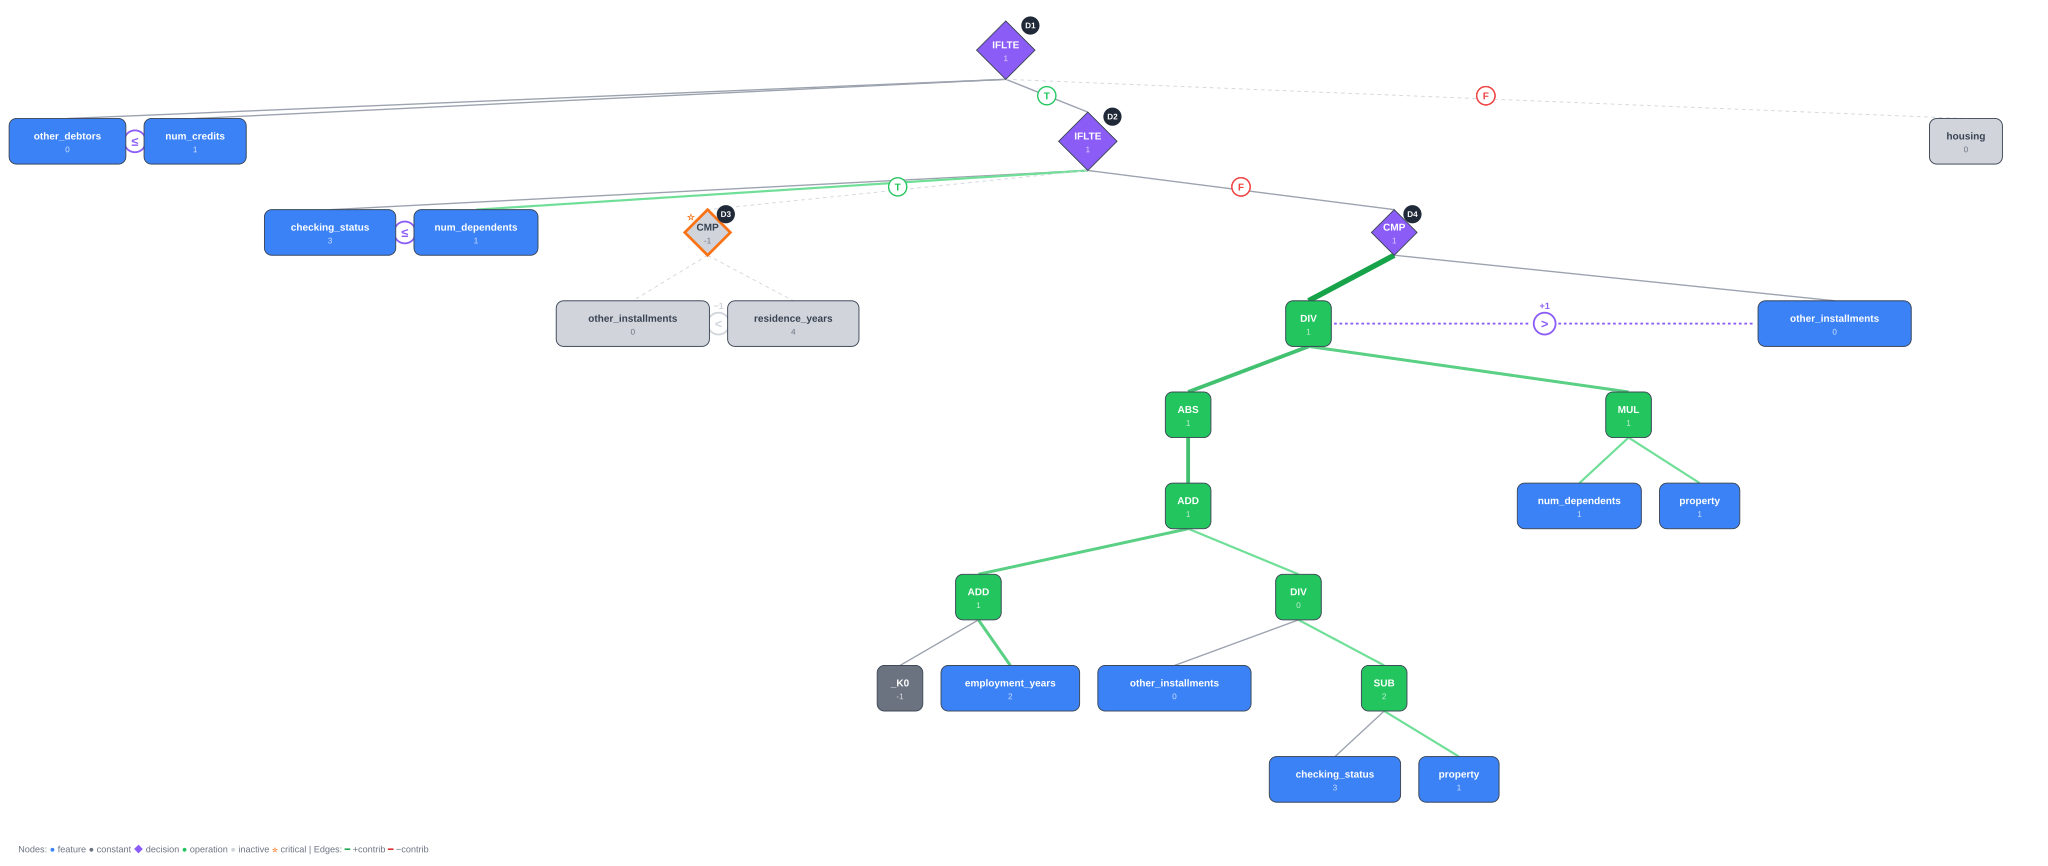

Instance 1:


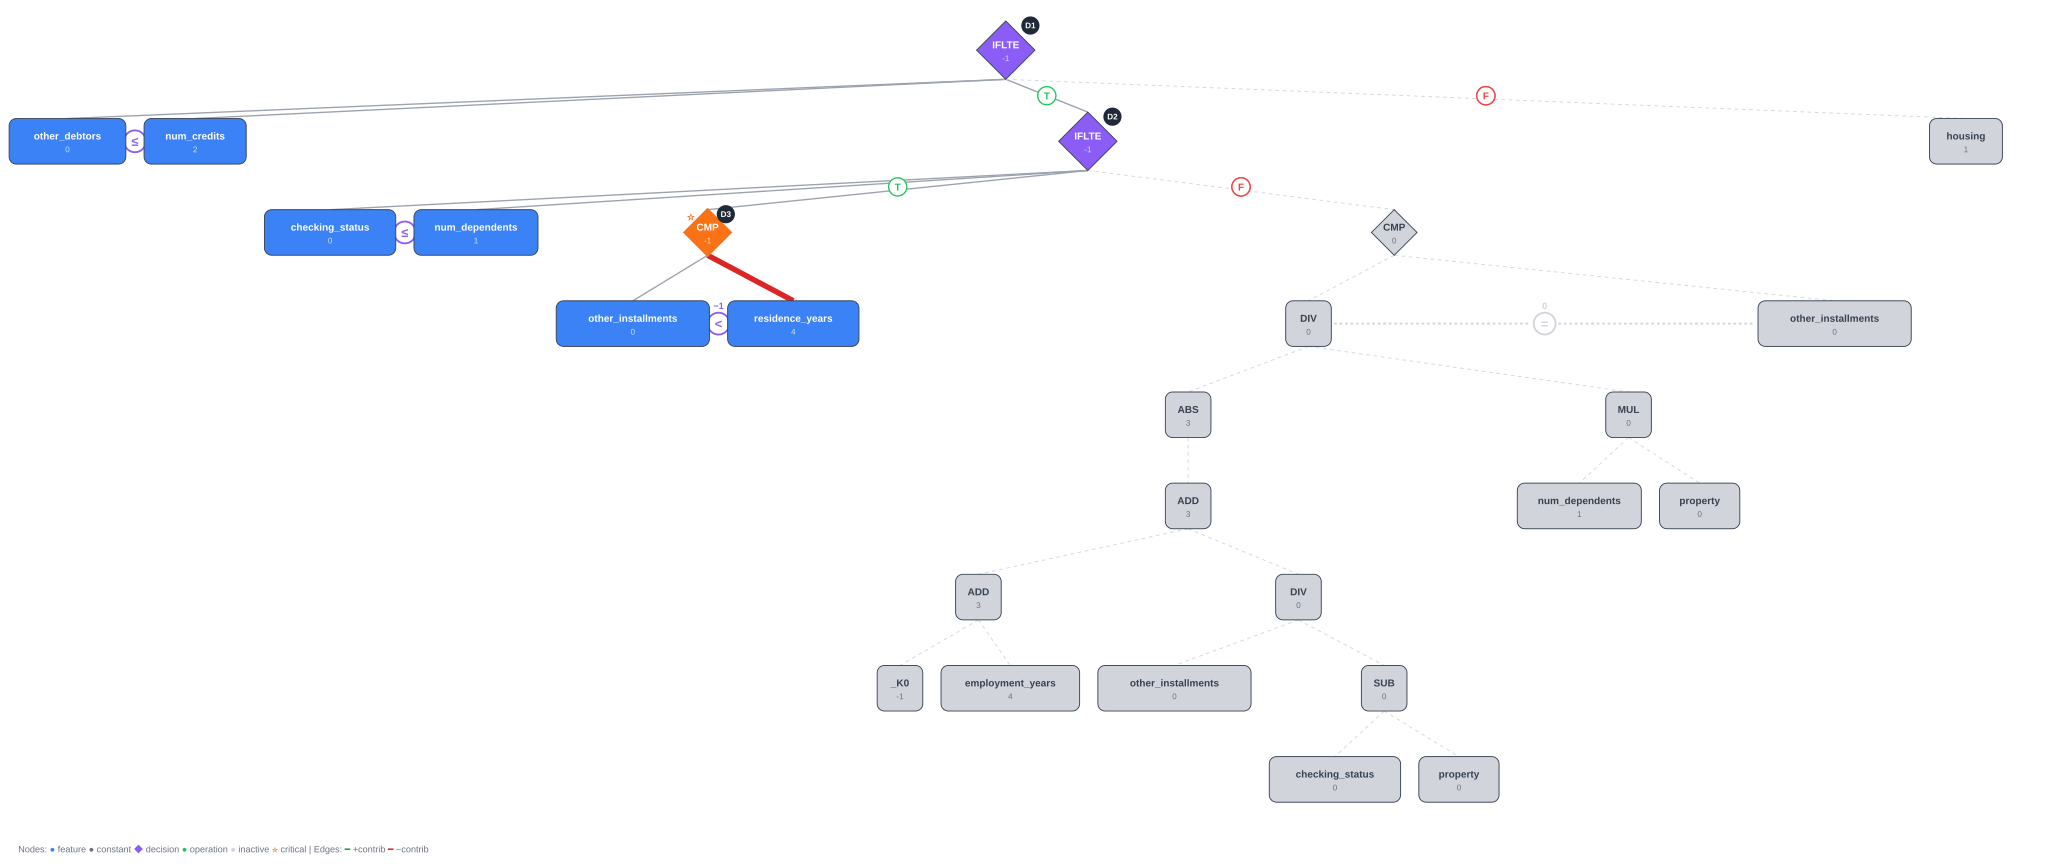

Instance 2:


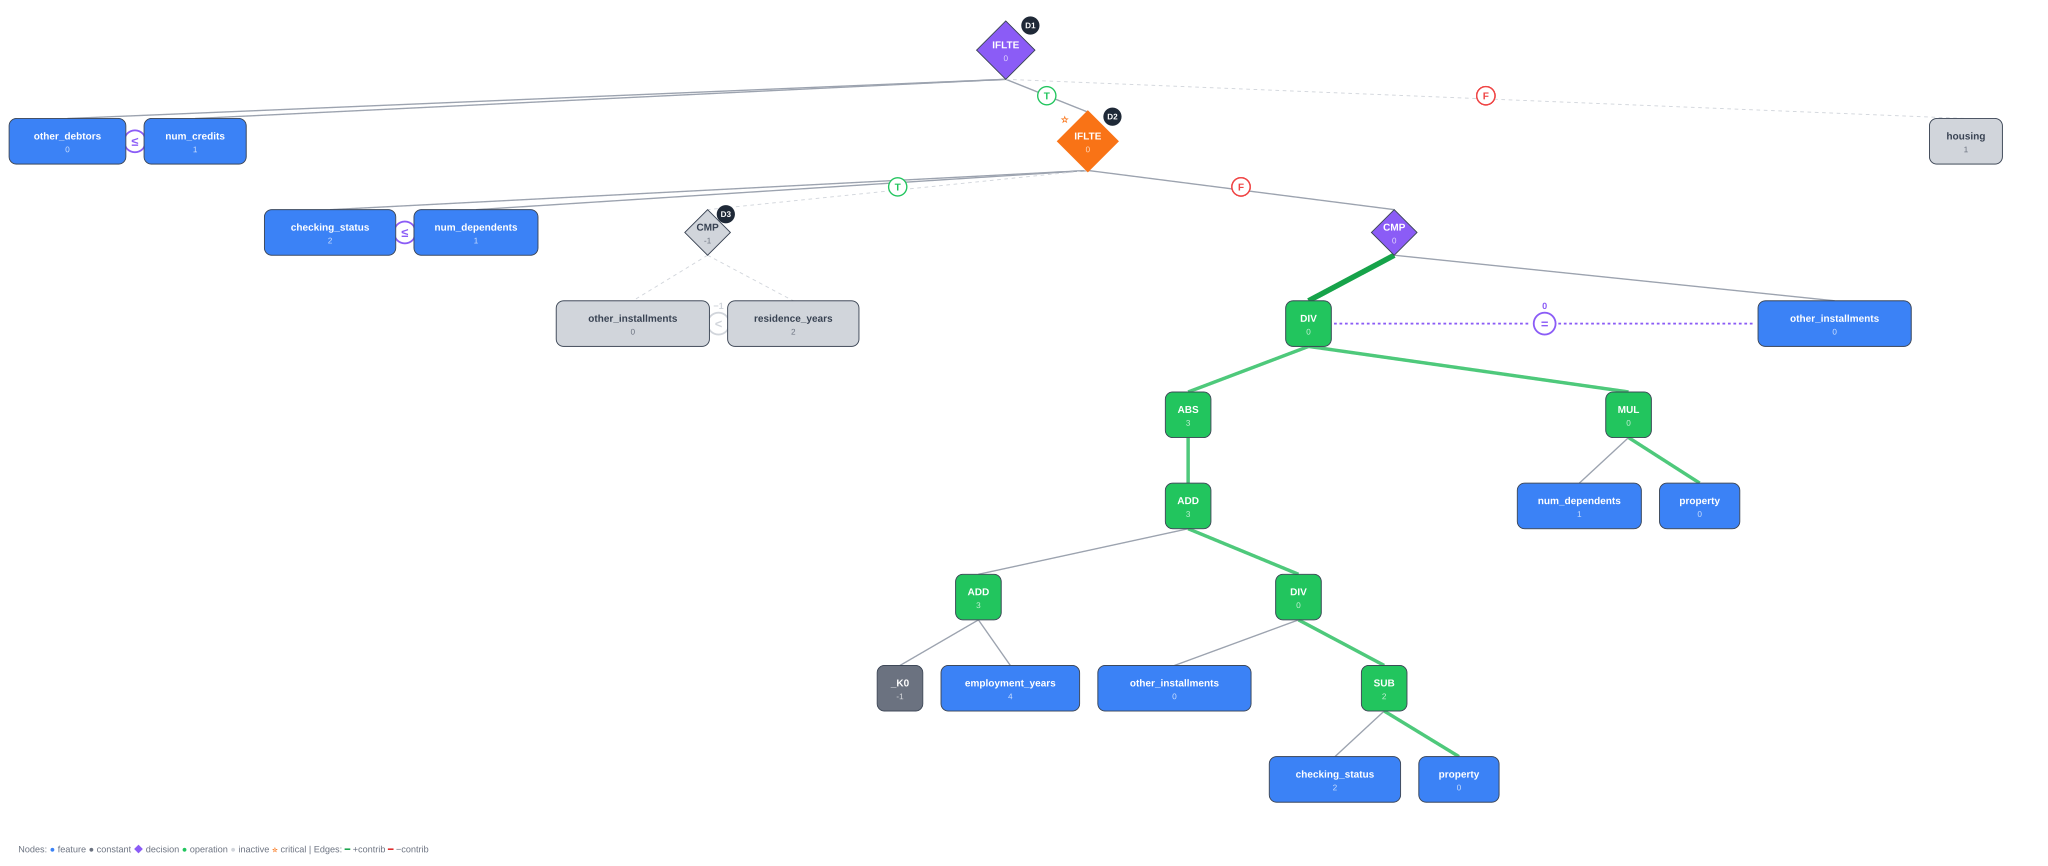

In [ ]:
from IPython.display import SVG, display

for i, svg in enumerate(results_g['svgs']):
    if svg:
        print(f"Instance {i}:")
        display(SVG(svg))

  0%|          | 0/300 [00:00<?, ?it/s]

[<Figure size 1600x600 with 2 Axes>,
 <Figure size 1600x600 with 2 Axes>,
 <Figure size 1600x600 with 2 Axes>]

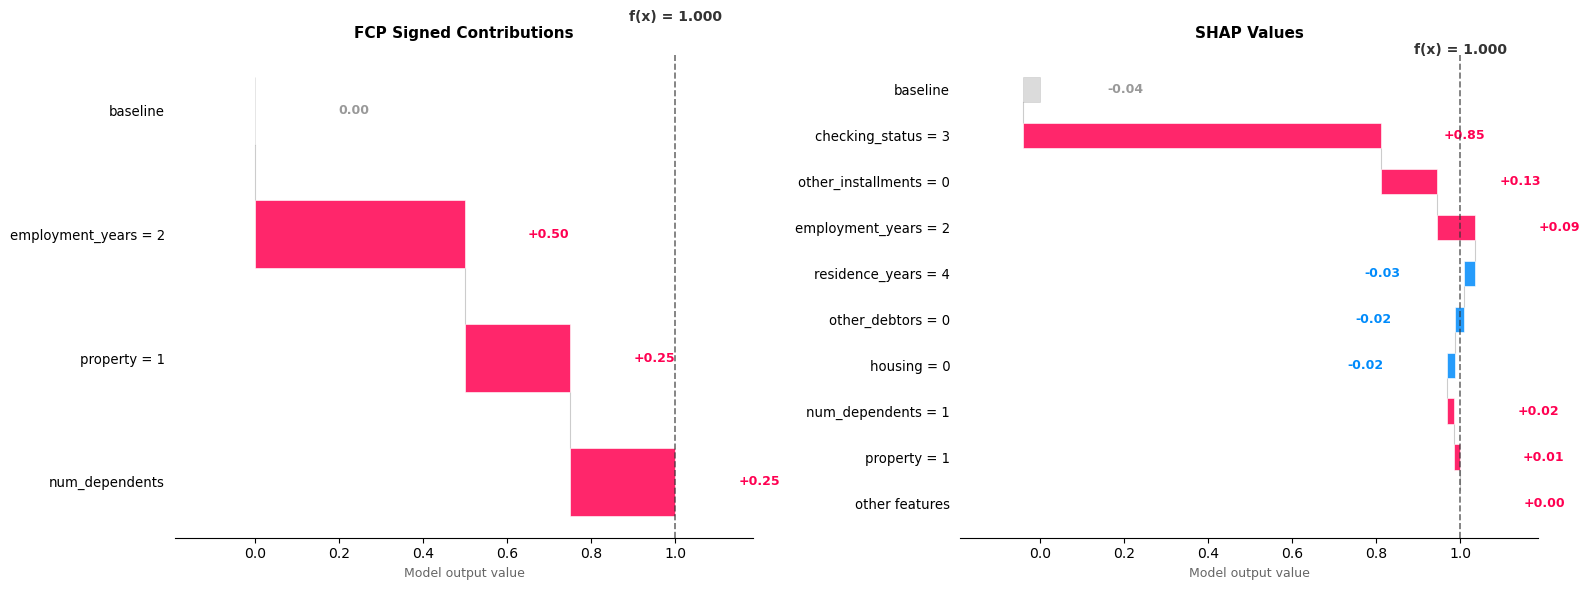

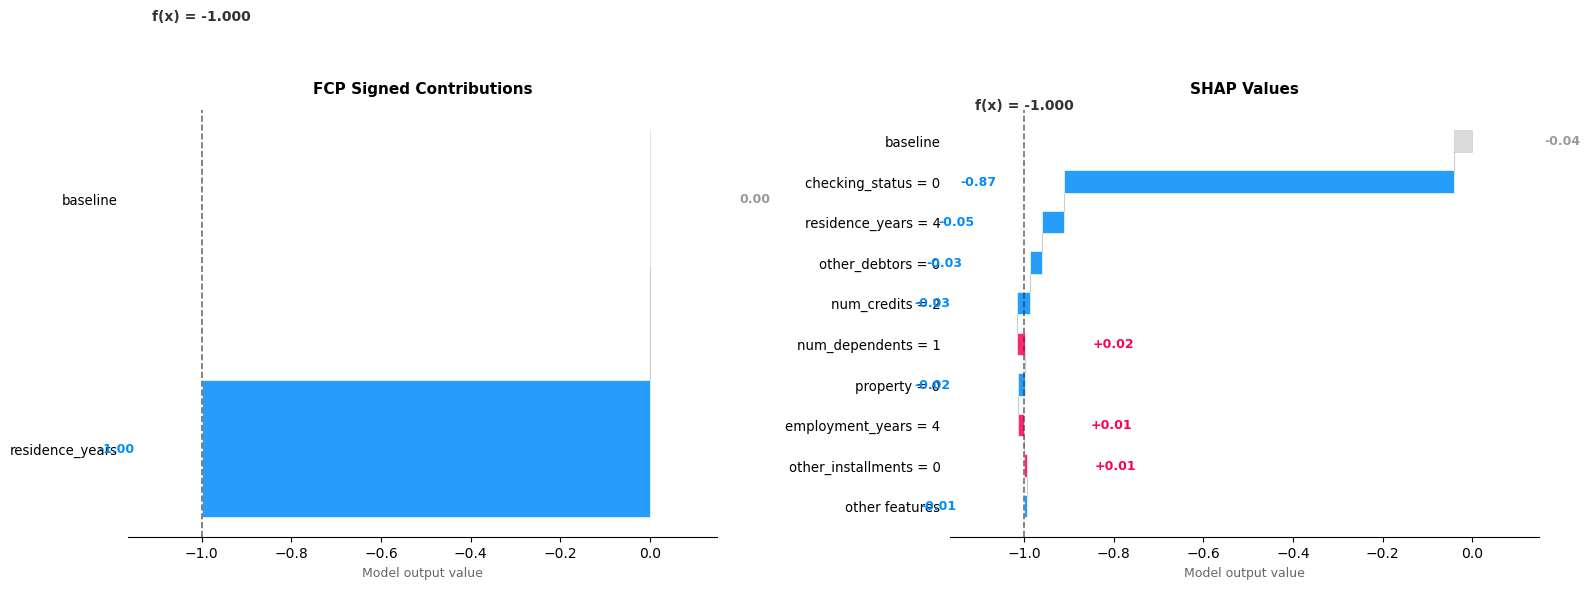

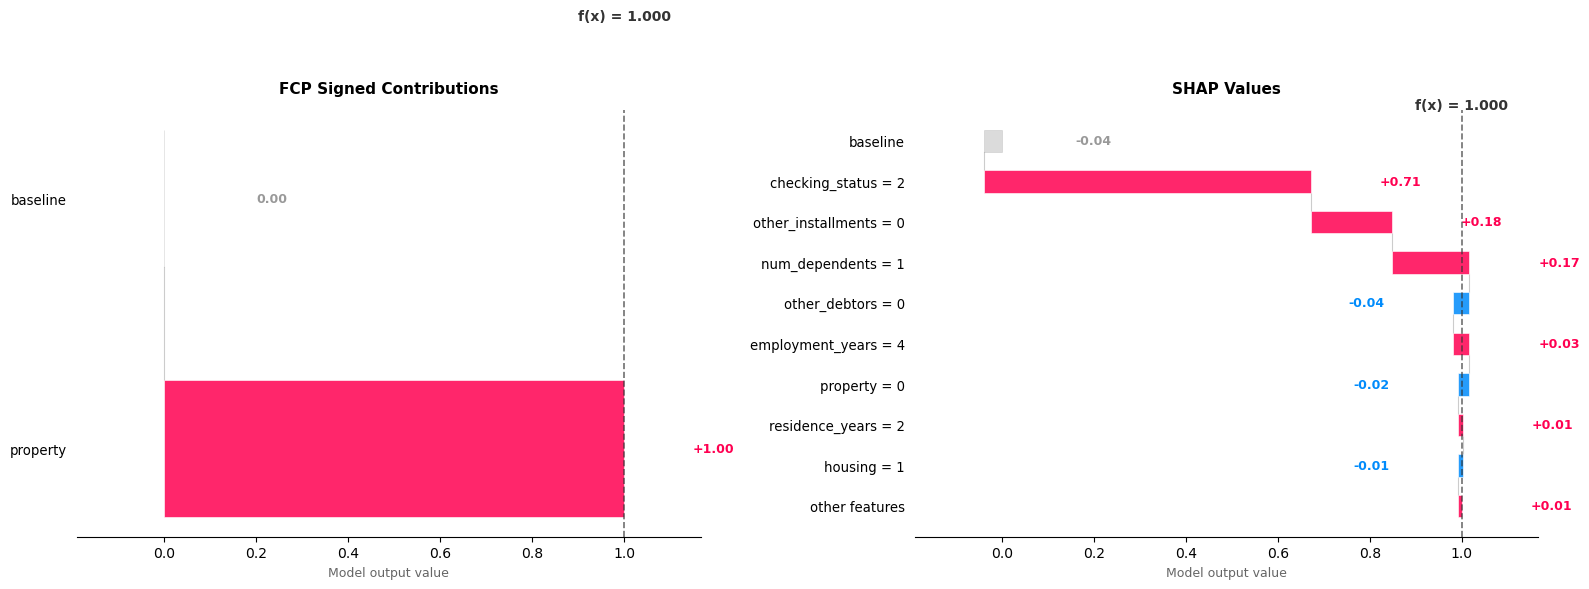

In [ ]:
import shap
import numpy as np
from deap import gp
from fcp_waterfall import plot_fcp_vs_shap, make_fcp_shap_comparison

make_fcp_shap_comparison(results_g, X_test_g, info_g, sample_count=100)

## Concrete Compressive Strength

In [ ]:
from concrete_preprocessing import (
    load_and_preprocess_concrete,
    get_concrete_gp_config,
    evaluate_regression,
)
from gp_evolve_explain import GPConfig, run_experiment, TaskType

X_train_c, y_train_c, X_test_c, y_test_c, info_c = load_and_preprocess_concrete(
    filepath='./data/Concrete_Data.xls',
    scale_features=False,
    test_size=0.3,
    random_state=42,
    verbose=True,
)


import numpy as np

config_c = GPConfig(
    **get_concrete_gp_config(),
    task_type=TaskType.REGRESSION,
    seed=42,
)

# MSE fitness for regression
def concrete_fitness(individual, toolbox, X, y):
    func = toolbox.compile(expr=individual)
    errors = []
    for xi, yi in zip(X, y):
        try:
            pred = func(*xi)
            if not np.isfinite(pred):
                errors.append(1e4)
            else:
                errors.append((yi - pred) ** 2)
        except Exception:
            errors.append(1e4)
    return (np.mean(errors),)

results_c = run_experiment(
    X_train_c, y_train_c,
    X_test_c, y_test_c,
    config_c,
    fitness_fn=concrete_fitness,
    n_explanations=3,
    verbose=True,
    simplify=True,
)

Concrete Compressive Strength Dataset
  Total samples: 1030
  Train: 721, Test: 309
  Features: 8 (all continuous)
  Target range: 2.3 - 82.6 MPa
  Target mean: 35.8 MPa, std: 16.7 MPa
  Scaled: False
GP Evolution Experiment
Training samples: 721
Test samples: 309
Features: 8



e:\Programs\NewAnaconda\Lib\site-packages\deap\gp.py:257: RuntimeWarning: Ephemeral W function cannot be pickled because its generating function is a lambda function. Use functools.partial instead.
  warnings.warn("Ephemeral {name} function cannot be "
e:\Programs\NewAnaconda\Lib\site-packages\deap\gp.py:257: RuntimeWarning: Ephemeral T function cannot be pickled because its generating function is a lambda function. Use functools.partial instead.
  warnings.warn("Ephemeral {name} function cannot be "


(μ + λ) Evolution: μ=150, λ=300
Fitness: custom

 Gen      Fitness        Avg   Size
------------------------------------
   0    1015.2990 253576403.5078   20.4
   1     706.3625  1431.2872   10.6
   2     688.5286  1123.6039   13.7
   3     511.6182   812.6239   15.0
   4     511.1182   689.9052   18.3
   5     380.0154   642.4735   16.6
   6     294.4059   517.9856   16.7
   7     277.5396   391.8616   18.3
   8     259.9857   316.3398   15.4
   9     259.9857   286.3368   16.8
  10     259.9857   268.3569   19.8
  11     258.9857   260.9400   12.7
  12     258.9857   259.9190   10.9
  13     258.9857   259.7557   10.5
  14     258.9857   259.3836    9.8
  15     258.9857   258.9857    9.0
  16     258.9857   258.9857    9.0
  17     258.9857   258.9857    9.0
  18     258.9857   258.9857    9.0
  19     258.9857   258.9857    9.0
  20     258.9857   258.9857    9.0
  21     258.9857   258.9857    9.0
  22     258.9857   258.9857    9.0
  23     258.9857   258.9857    9.0
  24     2

Concrete Regression Metrics:
  rmse: 10.4823
  mae: 8.3654
  r2: 0.5505
  mape: 30.5709

Evolved expression: ADD(SUB(superplasticizer, CMP(_K0, age)), ABS(ADD(ADD(ADD(ADD(ADD(ADD(ADD(SUB(_K1, MUL(_K2, MIN(age, _K3))), MUL(_K3, CMP(water, cement))), CMP(_K3, blast_furnace_slag)), CMP(_K2, blast_furnace_slag)), CMP(_K0, age)), CMP(fly_ash, age)), DIV(_K4, CMP(_K5, age))), MIN(fly_ash, _K6))))

Instance 0: True strength = 39.7 MPa
             Predicted     = 40.4 MPa

Feature values:
  cement: 228.0
  blast_furnace_slag: 342.1
  fly_ash: 0.0
  water: 185.7
  superplasticizer: 0.0
  coarse_aggregate: 955.8
  fine_aggregate: 674.3
  age: 28.0

Top value contributors:
  age: 32.7%
  cement: 26.5%
  water: 21.6%
  blast_furnace_slag: 19.2%
  superplasticizer: 0.0%


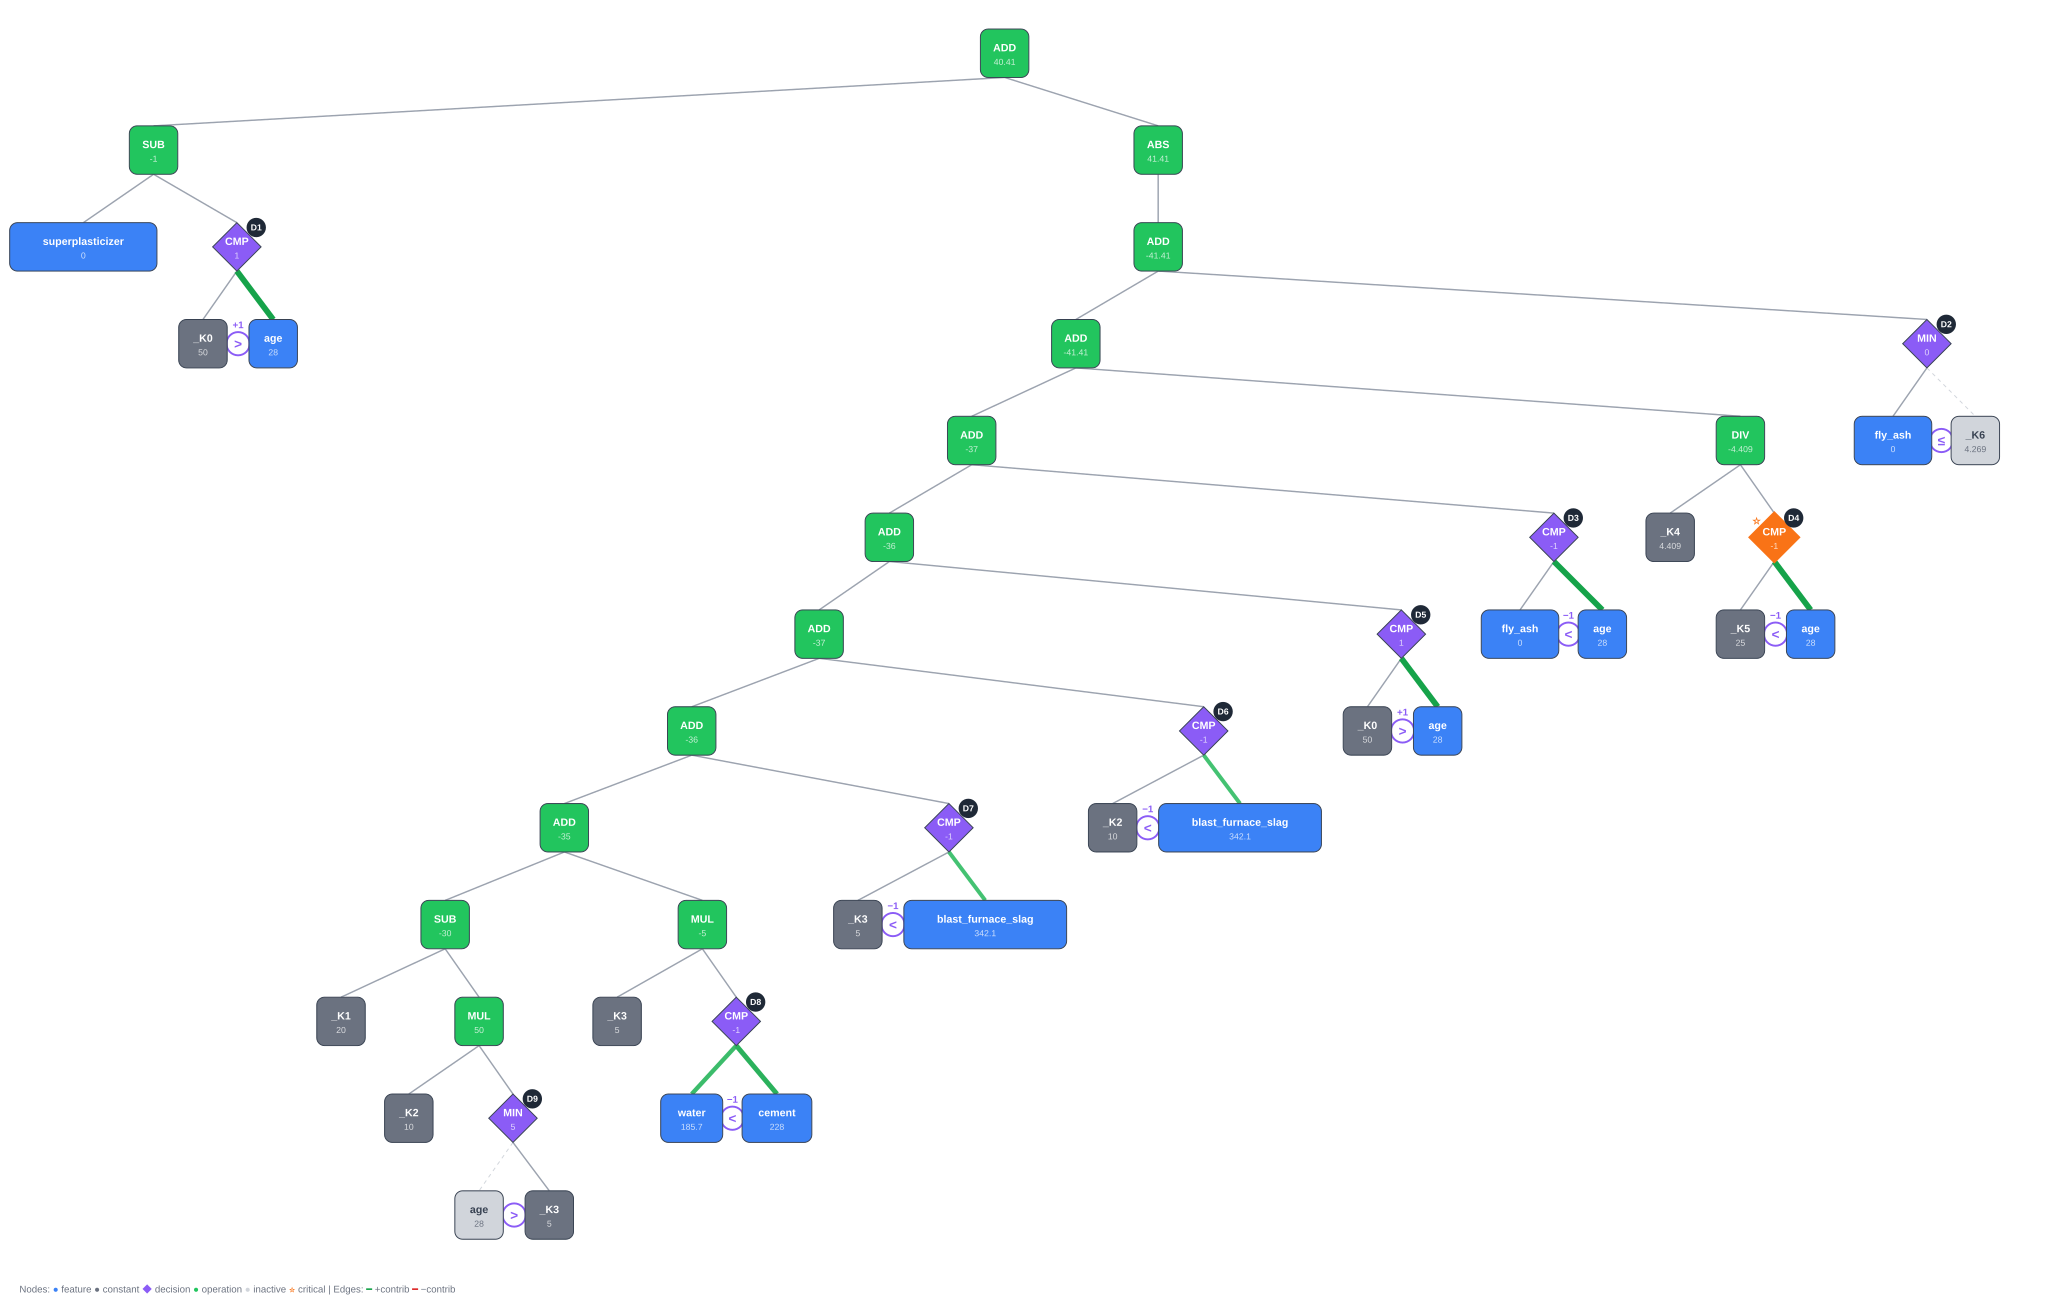


Instance 1: True strength = 12.5 MPa
             Predicted     = 7.6 MPa

Feature values:
  cement: 307.0
  blast_furnace_slag: 0.0
  fly_ash: 0.0
  water: 193.0
  superplasticizer: 0.0
  coarse_aggregate: 968.0
  fine_aggregate: 812.0
  age: 3.0

Top value contributors:
  age: 83.1%
  cement: 10.4%
  water: 6.5%
  superplasticizer: 0.0%
  fly_ash: 0.0%


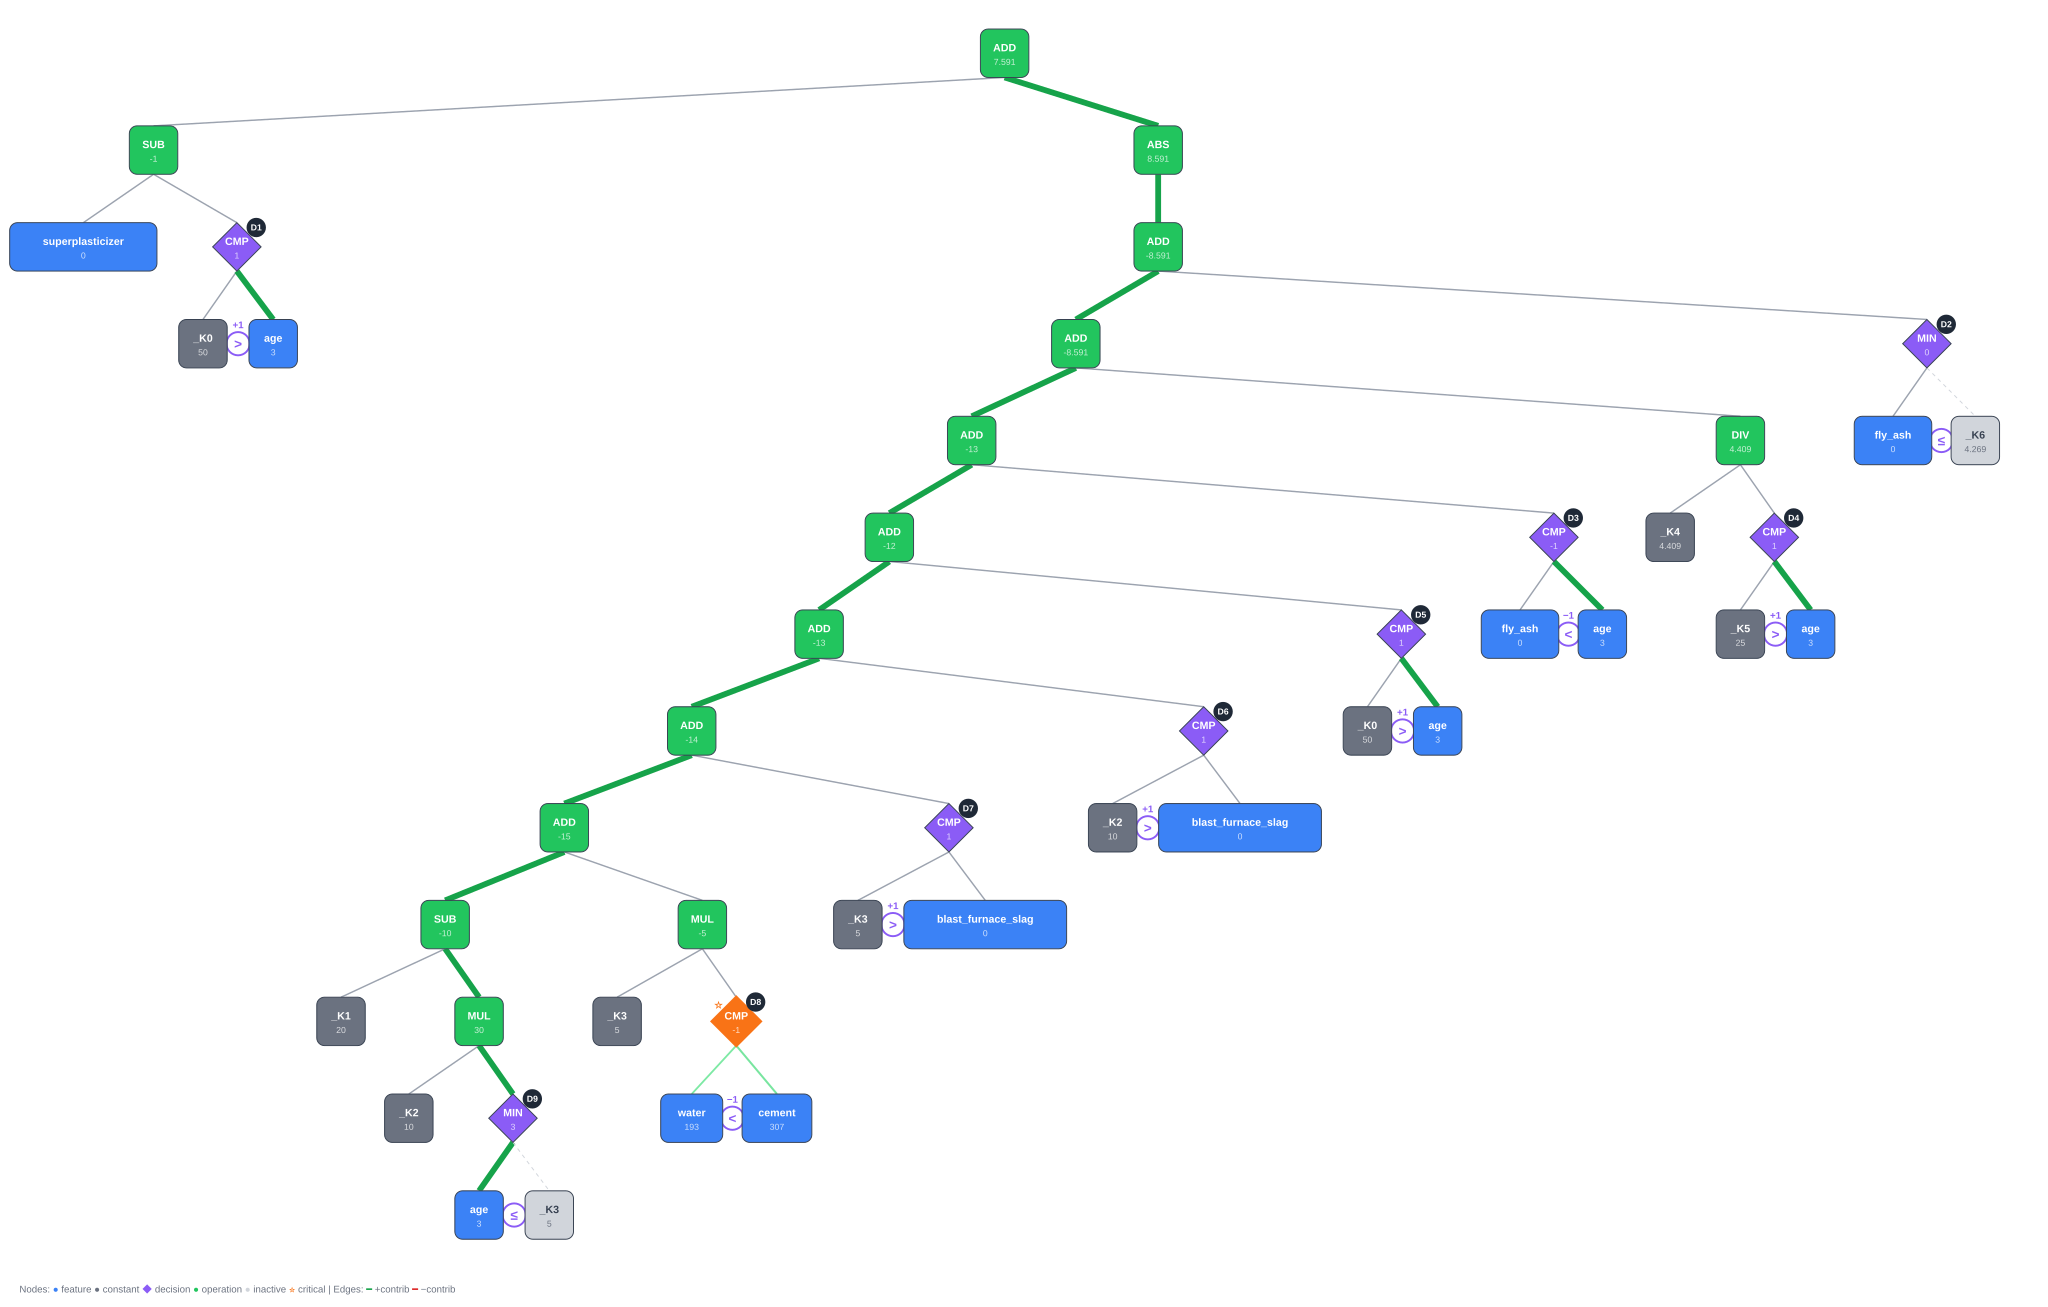


Instance 2: True strength = 31.0 MPa
             Predicted     = 27.6 MPa

Feature values:
  cement: 297.0
  blast_furnace_slag: 0.0
  fly_ash: 0.0
  water: 186.0
  superplasticizer: 0.0
  coarse_aggregate: 1040.0
  fine_aggregate: 734.0
  age: 7.0

Top value contributors:
  age: 52.0%
  cement: 29.5%
  water: 18.5%
  superplasticizer: 0.0%
  fly_ash: 0.0%


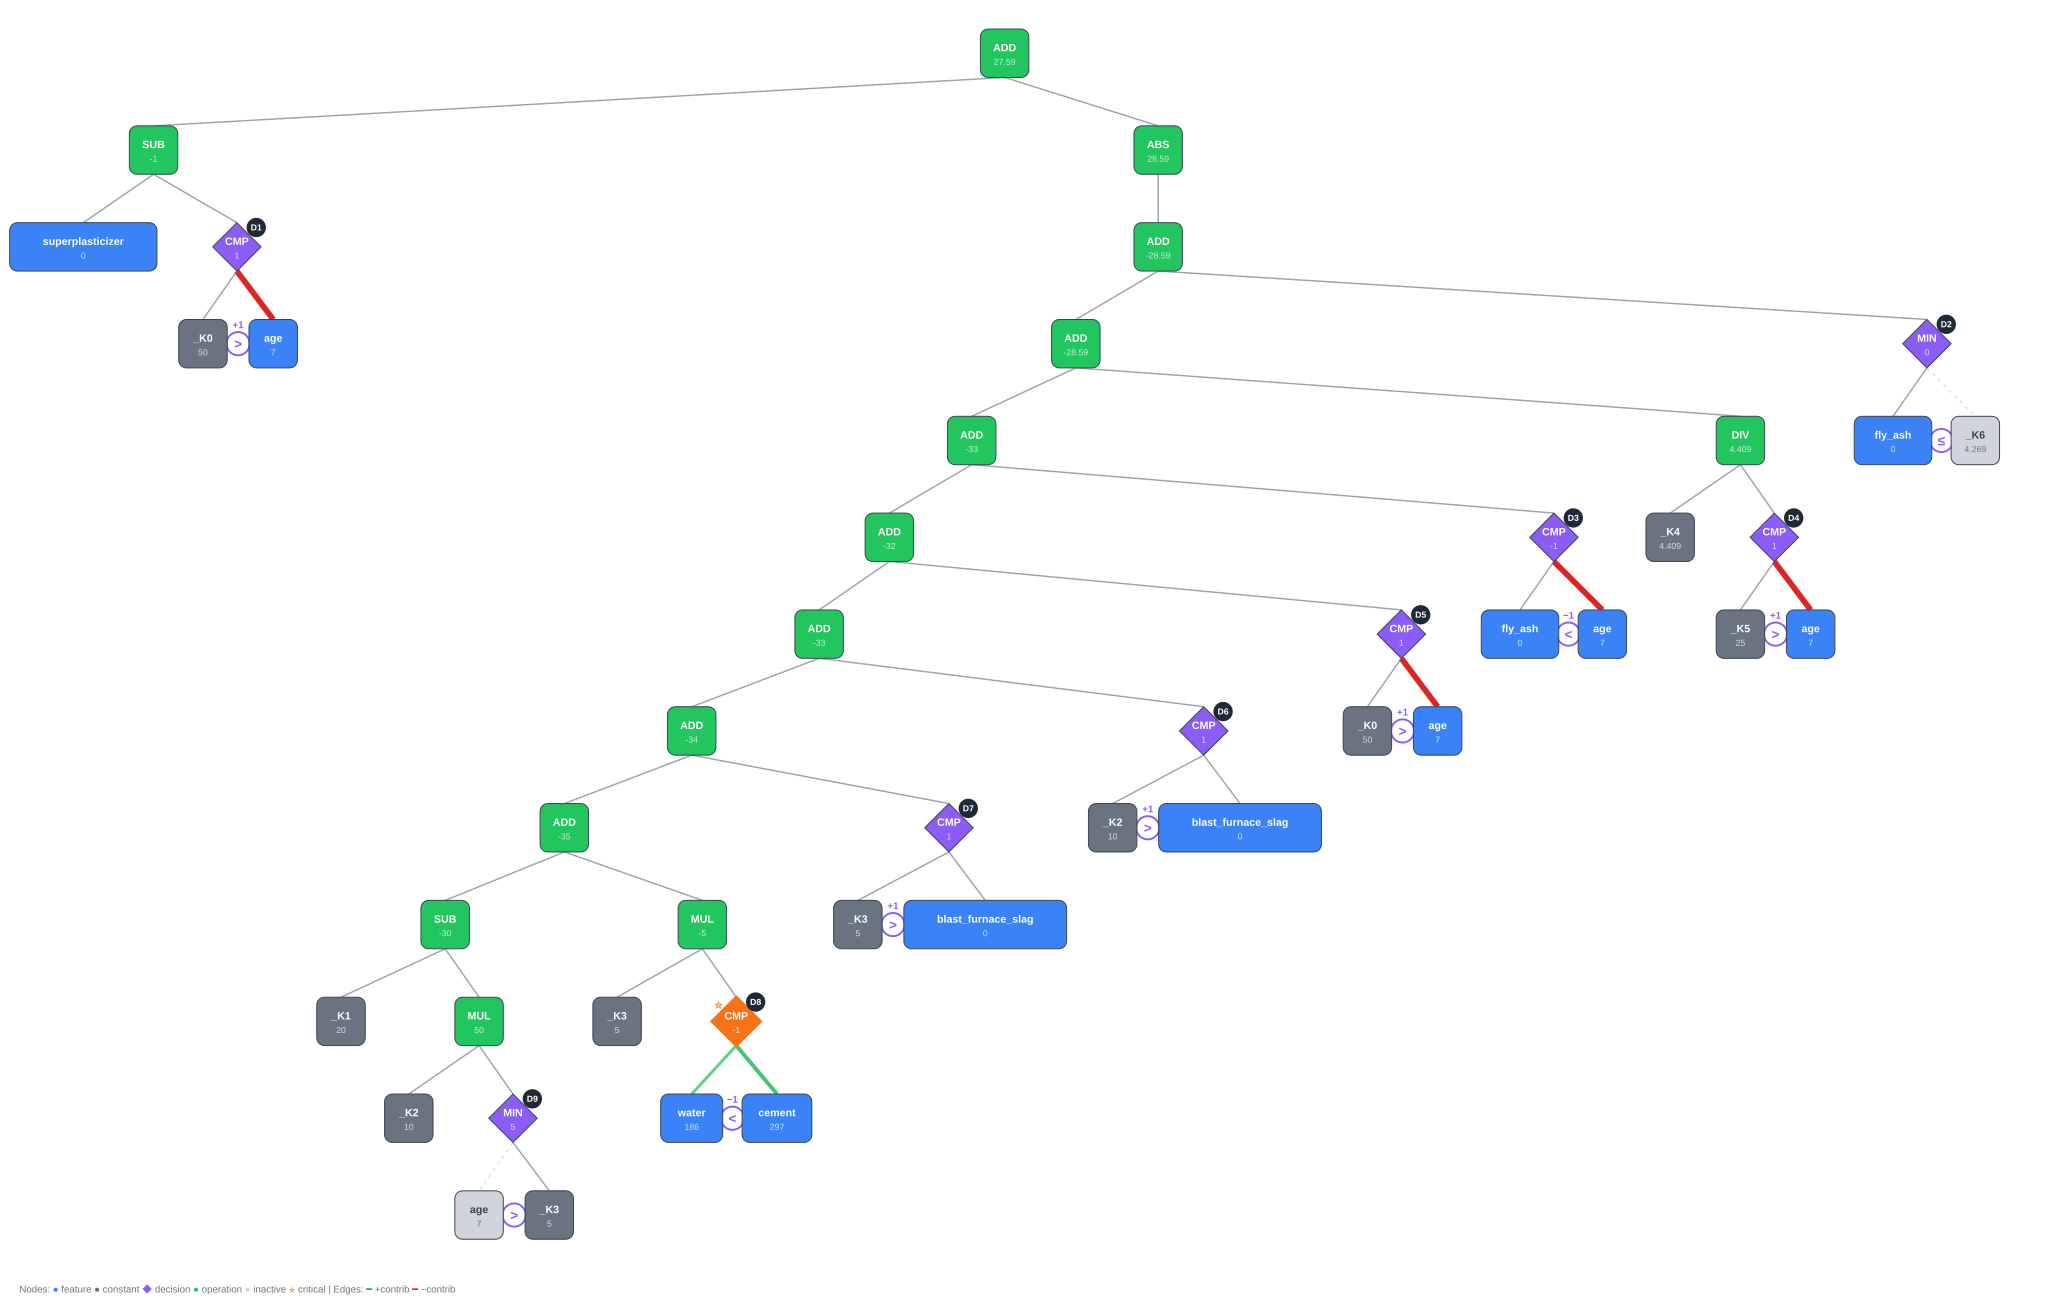

In [ ]:
from deap import gp

func_c = gp.compile(results_c['best_tree'], results_c['pset'])
y_pred_c = []
for xi in X_test_c:
    try:
        pred = func_c(*xi)
        y_pred_c.append(pred if np.isfinite(pred) else np.mean(y_train_c))
    except Exception:
        y_pred_c.append(np.mean(y_train_c))
y_pred_c = np.array(y_pred_c)

metrics_c = evaluate_regression(y_test_c, y_pred_c)
print("Concrete Regression Metrics:")
for k, v in metrics_c.items():
    print(f"  {k}: {v:.4f}")

print(f"\nEvolved expression: {results_c['best_tree']}")

# %%
# Display FCP explanations for concrete predictions

from IPython.display import display, SVG, HTML

for i, (explanation, svg) in enumerate(zip(results_c['explanations'], results_c['svgs'])):
    true_val = explanation.get('true_label', '?')
    pred_val = explanation.get('score', '?')

    print(f"\n{'='*60}")
    print(f"Instance {i}: True strength = {true_val:.1f} MPa")
    if isinstance(pred_val, (int, float)):
        print(f"             Predicted     = {pred_val:.1f} MPa")

    # Show feature values for this instance
    idx = explanation.get('instance_idx', i)
    print(f"\nFeature values:")
    for j, name in enumerate(info_c.names):
        print(f"  {name}: {X_test_c[idx, j]:.1f}")

    # Show attribution
    exp = explanation.get('explanation', None)
    if exp is not None:
        print(f"\nTop value contributors:")
        for factor in exp.primary_factors[:5]:
            print(f"  {factor.name}: {factor.importance:.1%}")

    # Display tree SVG
    if svg is not None:
        display(SVG(svg))

  0%|          | 0/309 [00:00<?, ?it/s]

[<Figure size 1600x600 with 2 Axes>,
 <Figure size 1600x600 with 2 Axes>,
 <Figure size 1600x600 with 2 Axes>]

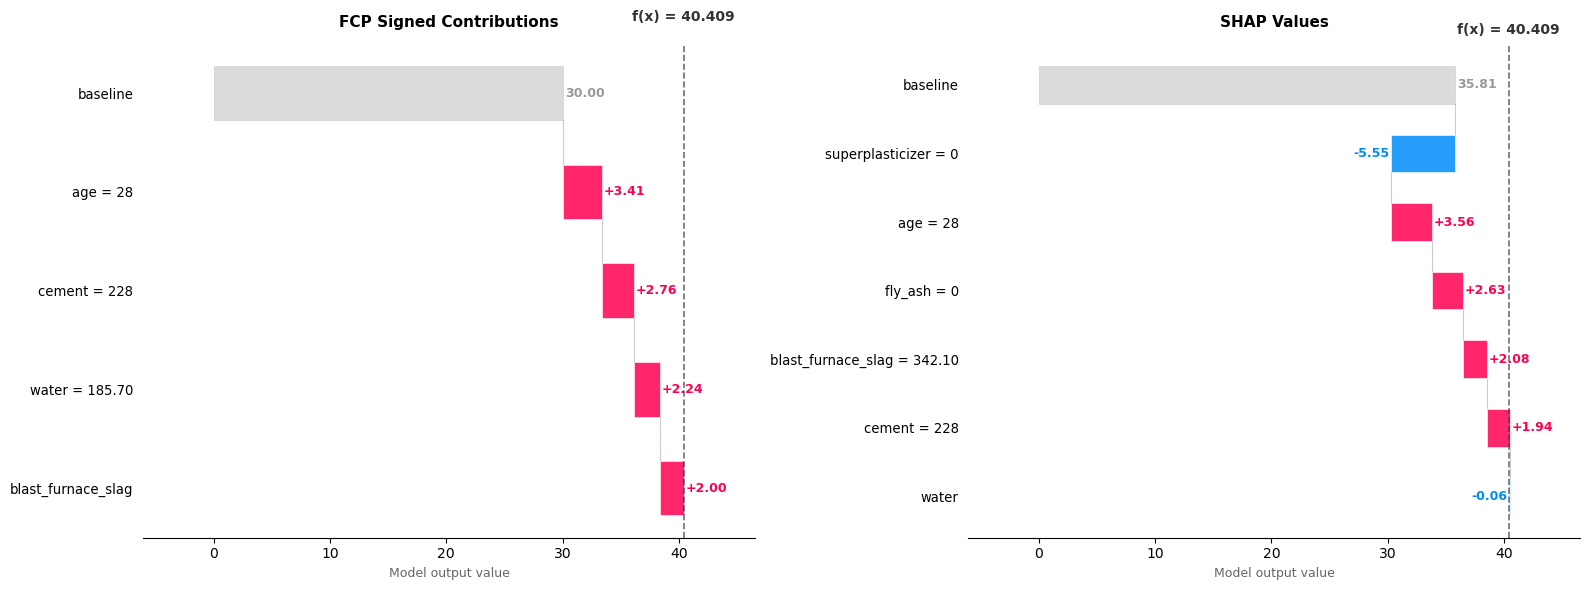

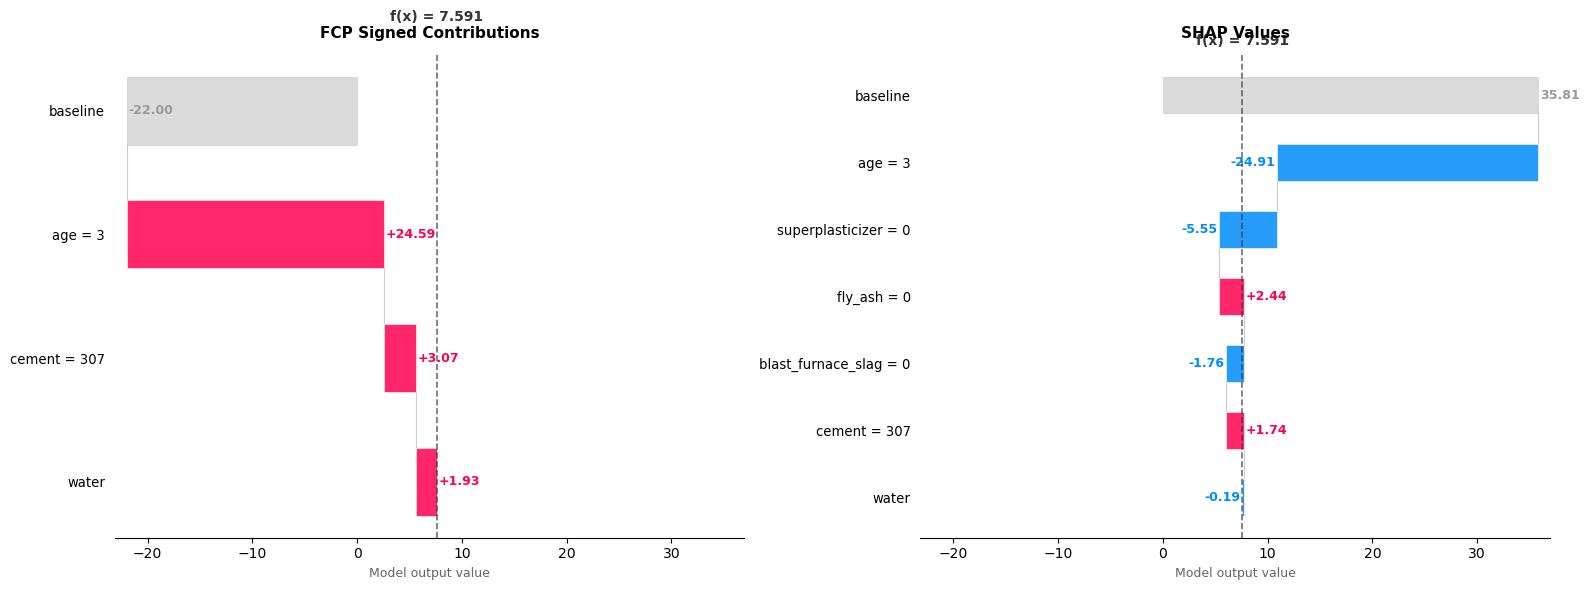

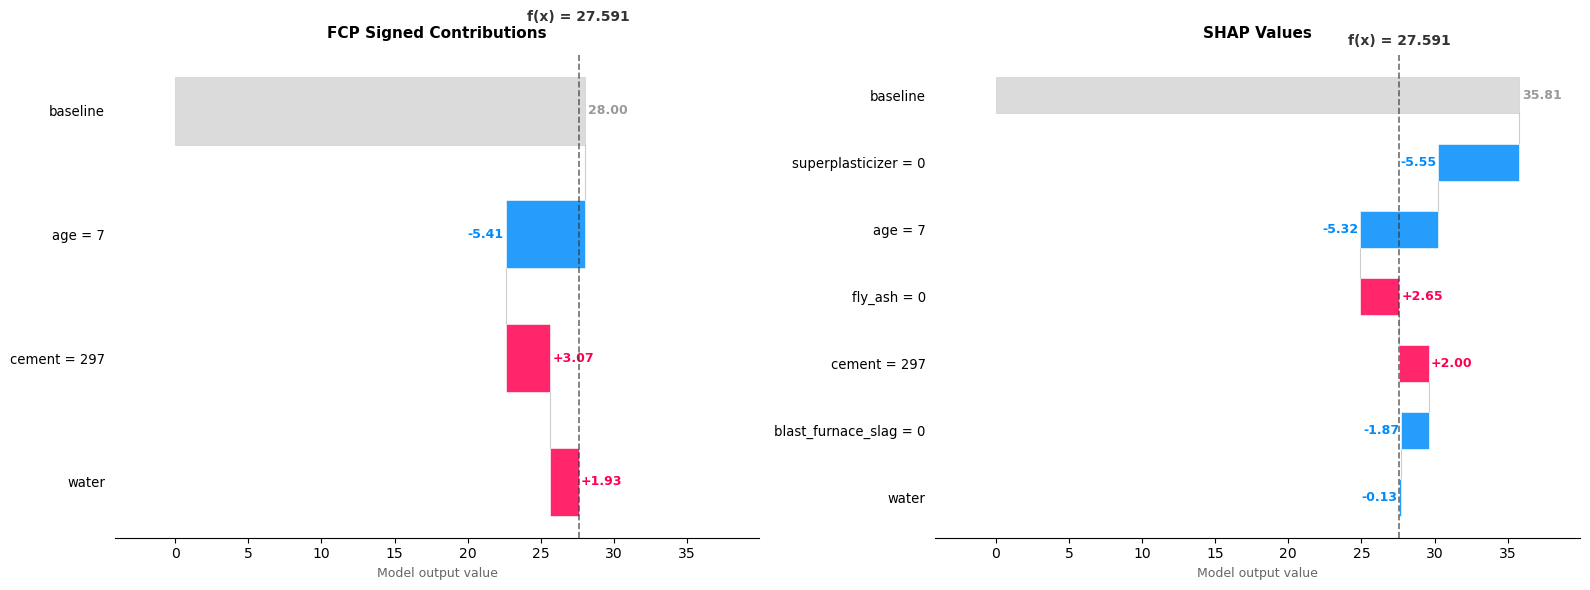

In [ ]:
import shap
import numpy as np
from deap import gp
from fcp_waterfall import plot_fcp_vs_shap, make_fcp_shap_comparison

make_fcp_shap_comparison(results_c, X_test_c, info_c, sample_count=100)



## Diabetes Diagnosis

In [ ]:
from diabetes_preprocessing import (
    load_and_preprocess_diabetes,
    get_diabetes_gp_config,
    evaluate_classification,
)
from gp_evolve_explain import GPConfig, fitness_cost_matrix, run_experiment, TaskType

X_train_d, y_train_d, X_test_d, y_test_d, info_d = load_and_preprocess_diabetes(
    filepath='./data/diabetes_data_upload.csv',
    scale_age=False,
    test_size=0.3,
    random_state=42,
    verbose=True,
)

config_d = GPConfig(
    **get_diabetes_gp_config(),
    task_type=TaskType.BINARY_CLASSIFICATION,
    seed=42,
)

diabetes_fitness = fitness_cost_matrix(fp_cost=1, fn_cost=2)

results_d = run_experiment(
    X_train_d, y_train_d,
    X_test_d, y_test_d,
    config_d,
    fitness_fn=diabetes_fitness,
    n_explanations=3,
    verbose=True,
    simplify=True,
)


Early Stage Diabetes Risk Prediction Dataset
  Total samples: 520
  Train: 364, Test: 156
  Features: 16 (15 binary + age)
  Class balance: 320 positive (61.5%), 200 negative (38.5%)
  Age range: 16-90 years
  Age scaled: False
GP Evolution Experiment
Training samples: 364
Test samples: 156
Features: 16

(μ + λ) Evolution: μ=150, λ=300
Fitness: custom

 Gen      Fitness        Avg   Size
------------------------------------
   0      92.0400   273.4025   22.5


e:\Programs\NewAnaconda\Lib\site-packages\deap\gp.py:257: RuntimeWarning: Ephemeral W function cannot be pickled because its generating function is a lambda function. Use functools.partial instead.
  warnings.warn("Ephemeral {name} function cannot be "
e:\Programs\NewAnaconda\Lib\site-packages\deap\gp.py:257: RuntimeWarning: Ephemeral T function cannot be pickled because its generating function is a lambda function. Use functools.partial instead.
  warnings.warn("Ephemeral {name} function cannot be "


   1      92.0400   135.4980   11.3
   2      74.0060   108.7230   36.4
   3      74.0060    90.0852   38.6
   4      74.0060    82.5266   33.2
   5      74.0060    76.6142   14.2
   6      74.0060    74.0060    6.0
   7      74.0060    74.0060    6.0
   8      74.0060    74.0060    6.0
   9      74.0060    74.0060    6.0
  10      74.0060    74.0060    6.0
  11      70.0080    73.9793    6.0
  12      70.0080    73.8461    6.1
  13      70.0080    73.2065    6.5
  14      70.0080    70.6218    8.5
  15      70.0080    70.0080    8.0
  16      55.0100    69.9080    8.0
  17      52.0080    69.1881    8.1
  18      52.0080    66.4885    8.5
  19      52.0080    56.8299    9.9
  20      43.0130    52.4489    8.9
  21      43.0130    51.4217    8.3
  22      43.0110    48.8632    9.9
  23      43.0110    43.0133   13.3
  24      43.0090    43.0125   12.5
  25      43.0090    43.0115   11.5
  26      43.0090    43.0105   10.5
  27      43.0090    43.0095    9.5
  28      43.0090    43.0090

Diabetes Classification Metrics:
  accuracy: 0.9167
  balanced_accuracy: 0.8965
  precision: 0.8962
  recall: 0.9794
  specificity: 0.8136
  f1: 0.9360
  tp: 95
  tn: 48
  fp: 11
  fn: 2

Evolved expression: ADD(ADD(ADD(ADD(SUB(SUB(ADD(irritability, sudden_weight_loss), alopecia), gender), MUL(_K0, polydipsia)), MUL(_K0, polyuria)), CMP(ADD(ADD(ADD(genital_thrush, polydipsia), polyuria), CMP(IFLTE(muscle_stiffness, weakness, _K1, muscle_stiffness), delayed_healing)), gender)), MIN(irritability, muscle_stiffness))

Instance 0: True = Positive (diabetic), Predicted = positive
             Raw score = 5.000

Symptom profile:
  age: 58
  gender: Yes
  polyuria: Yes
  polydipsia: Yes
  sudden_weight_loss: Yes
  weakness: Yes
  polyphagia: Yes
  genital_thrush: No
  visual_blurring: Yes
  itching: No
  irritability: No
  delayed_healing: Yes
  partial_paresis: Yes
  muscle_stiffness: Yes
  alopecia: No
  obesity: Yes

Top value contributors:
  muscle_stiffness <= weakness: 50.0%
  polydipsia

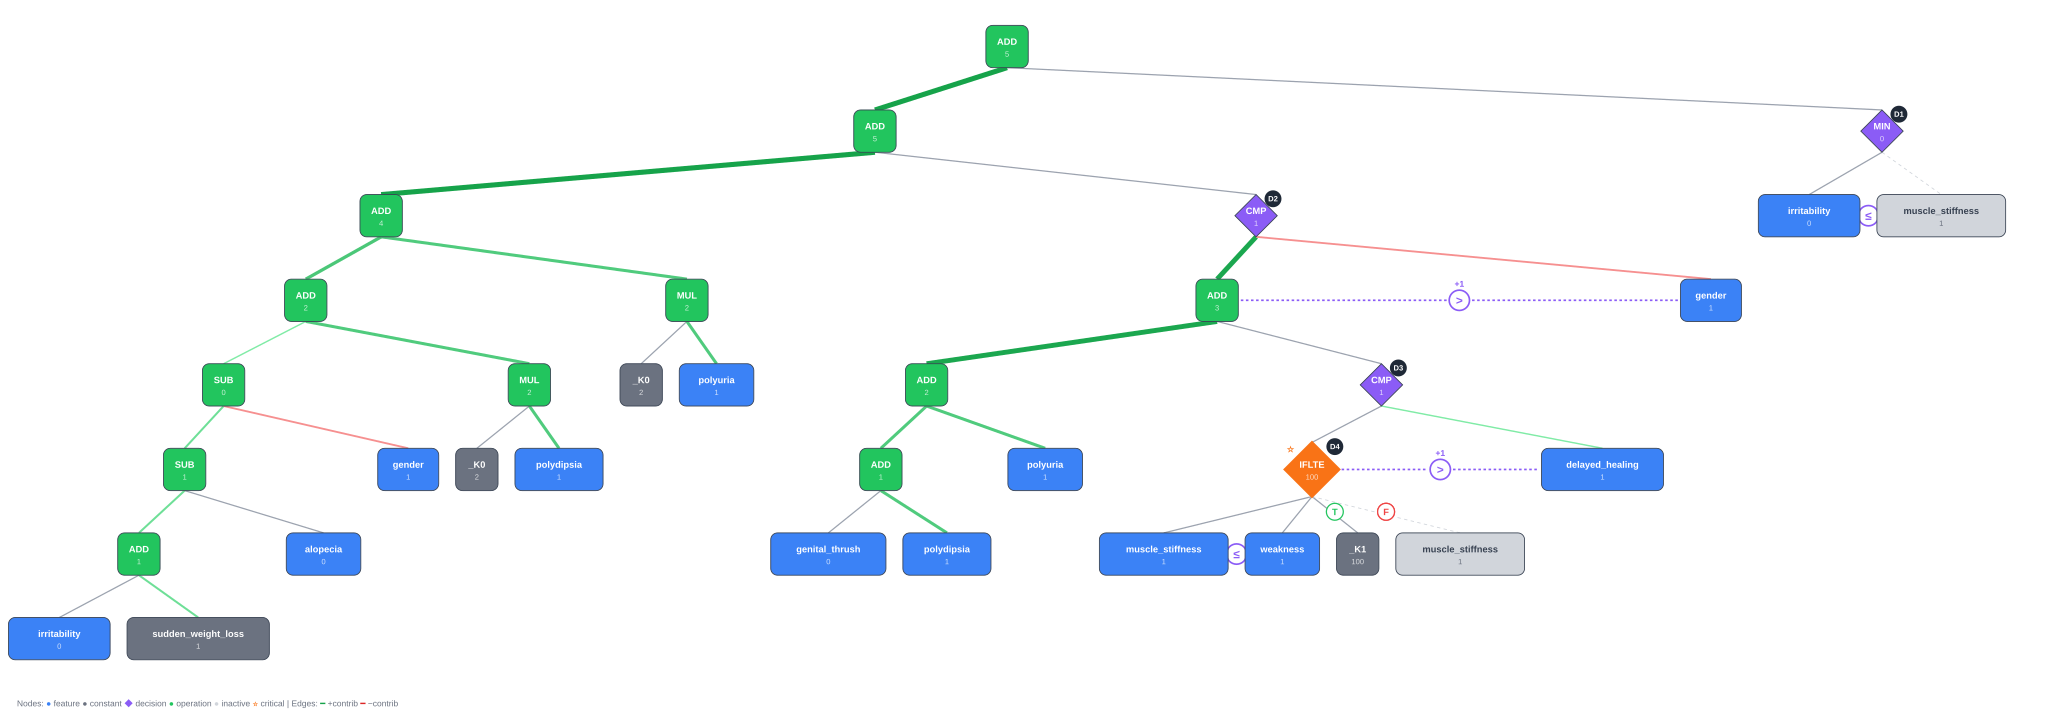


Instance 1: True = Positive (diabetic), Predicted = positive
             Raw score = 6.000

Symptom profile:
  age: 60
  gender: Yes
  polyuria: Yes
  polydipsia: Yes
  sudden_weight_loss: Yes
  weakness: Yes
  polyphagia: Yes
  genital_thrush: No
  visual_blurring: Yes
  itching: Yes
  irritability: Yes
  delayed_healing: Yes
  partial_paresis: Yes
  muscle_stiffness: Yes
  alopecia: Yes
  obesity: Yes

Top value contributors:
  muscle_stiffness <= weakness: 50.0%
  irritability <= muscle_stiffness: 50.0%
  polydipsia: 23.7%
  polyuria: 23.7%
  irritability: 21.1%


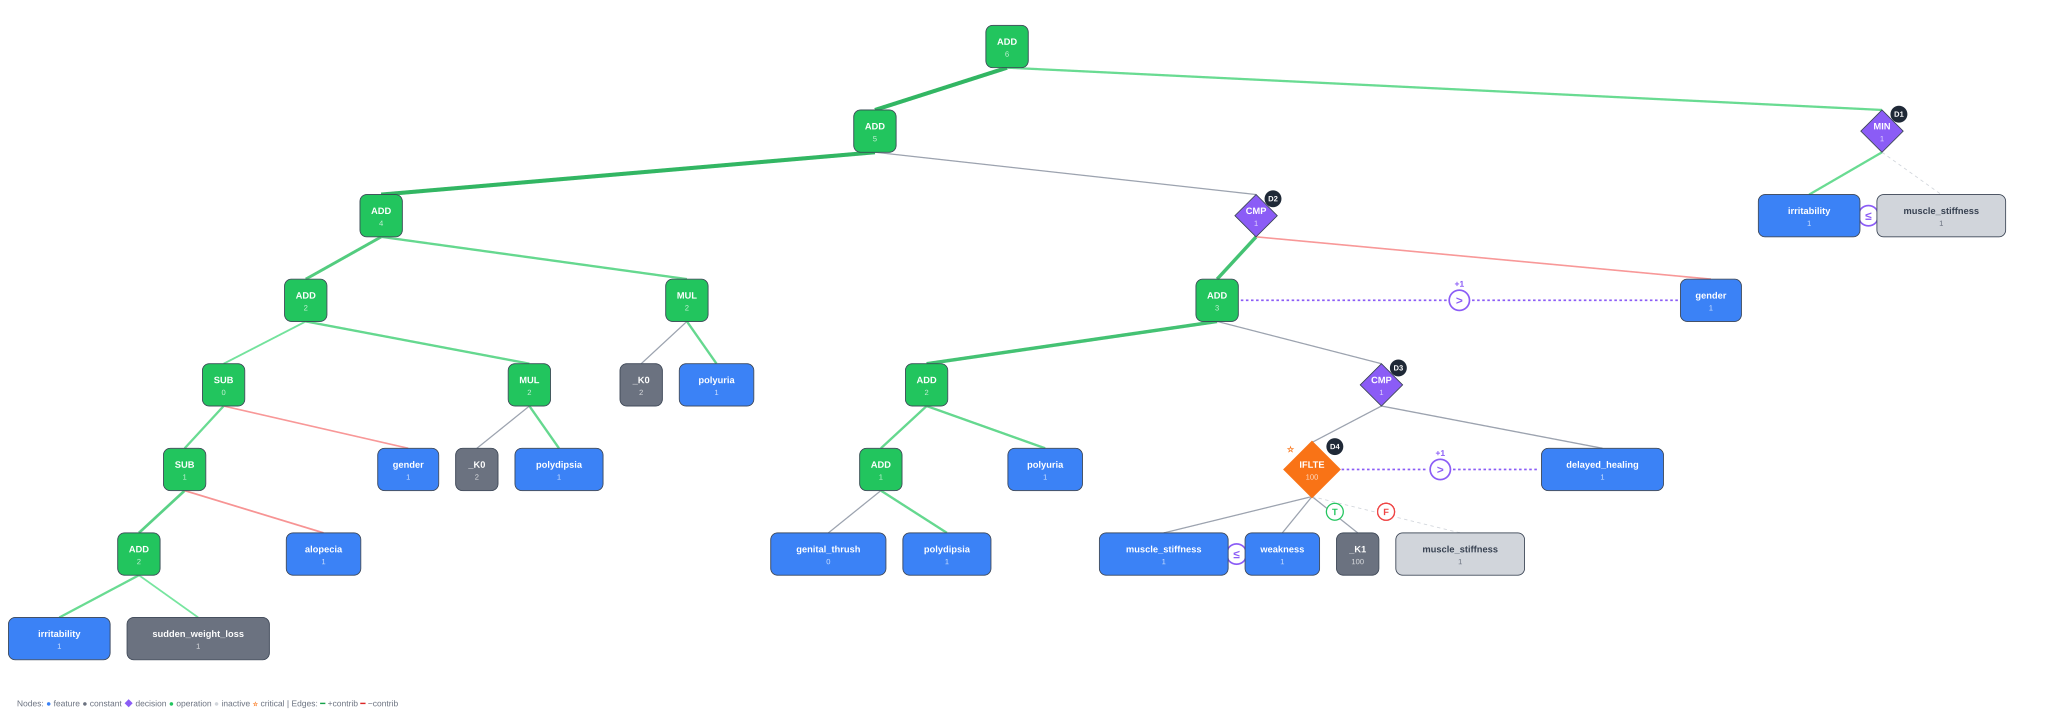


Instance 2: True = Positive (diabetic), Predicted = positive
             Raw score = 5.000

Symptom profile:
  age: 50
  gender: No
  polyuria: Yes
  polydipsia: Yes
  sudden_weight_loss: No
  weakness: Yes
  polyphagia: Yes
  genital_thrush: No
  visual_blurring: No
  itching: No
  irritability: No
  delayed_healing: Yes
  partial_paresis: Yes
  muscle_stiffness: No
  alopecia: No
  obesity: No

Top value contributors:
  irritability <= muscle_stiffness: 50.0%
  polydipsia: 46.7%
  polyuria: 46.7%
  muscle_stiffness <= weakness: 25.0%
  (((genital_thrush + polydipsia) + polyuria) + cmp(if(muscle_stiffness<=weakness, _K1, _), delayed_healing)) > gender: 12.5%


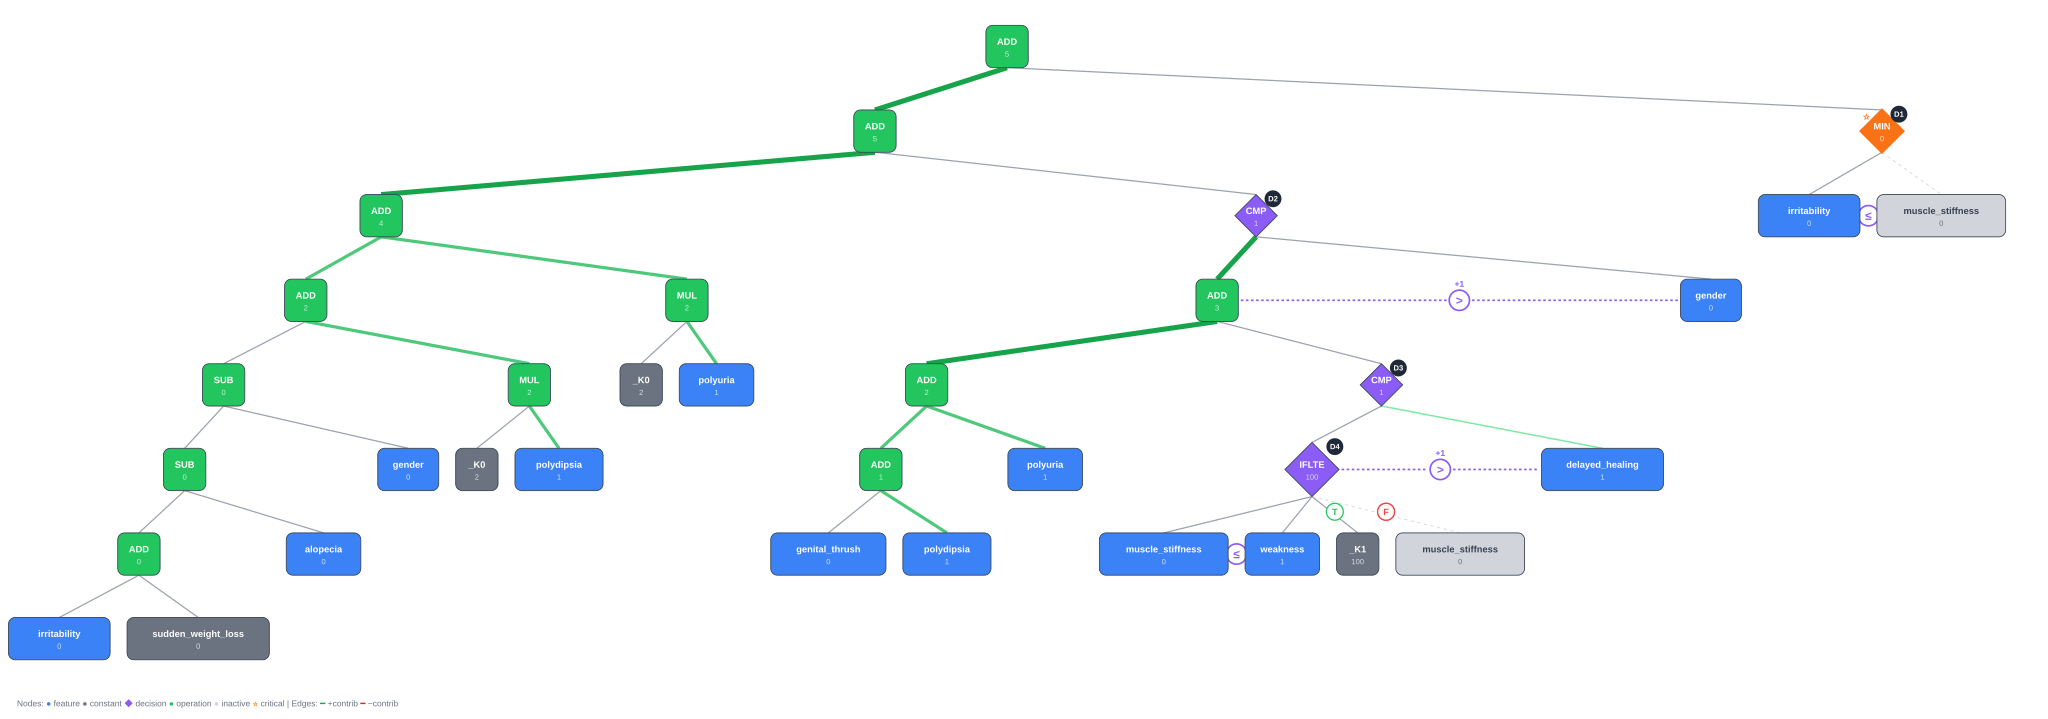

In [ ]:
from deap import gp
import numpy as np

from IPython.display import display, SVG

func_d = gp.compile(results_d['best_tree'], results_d['pset'])
y_pred_d = []
for xi in X_test_d:
    try:
        score = func_d(*xi)
        y_pred_d.append(1 if score > 0 else 0)
    except Exception:
        y_pred_d.append(0)
y_pred_d = np.array(y_pred_d)

metrics_d = evaluate_classification(y_test_d, y_pred_d)
print("Diabetes Classification Metrics:")
for k, v in metrics_d.items():
    if isinstance(v, float):
        print(f"  {k}: {v:.4f}")
    else:
        print(f"  {k}: {v}")

print(f"\nEvolved expression: {results_d['best_tree']}")

# %%
# Display FCP explanations for diabetes predictions

for i, (explanation, svg) in enumerate(zip(results_d['explanations'], results_d['svgs'])):
    true_label = explanation.get('true_label', '?')
    pred_label = explanation.get('prediction_label', '?')
    score = explanation.get('score', '?')

    true_str = "Positive (diabetic)" if true_label == 1 else "Negative"
    pred_str = pred_label if isinstance(pred_label, str) else (
        "Positive" if pred_label == 1 else "Negative"
    )

    print(f"\n{'='*60}")
    print(f"Instance {i}: True = {true_str}, Predicted = {pred_str}")
    if isinstance(score, (int, float)):
        print(f"             Raw score = {score:.3f}")

    # Show symptom profile for this instance
    idx = explanation.get('instance_idx', i)
    print(f"\nSymptom profile:")
    for j, name in enumerate(info_d.names):
        val = X_test_d[idx, j]
        if name in info_d.binary_features:
            display_val = "Yes" if val == 1 else "No"
        else:
            display_val = f"{val:.0f}"
        print(f"  {name}: {display_val}")

    # Show attribution
    exp = explanation.get('explanation', None)
    if exp is not None:
        print(f"\nTop value contributors:")
        for factor in exp.primary_factors[:5]:
            print(f"  {factor.name}: {factor.importance:.1%}")

        # Decision contributions are particularly interesting for binary features
        if hasattr(exp, 'decision_factors') and exp.decision_factors:
            print(f"\nTop decision contributors:")
            for factor in exp.decision_factors[:5]:
                print(f"  {factor.name}: {factor.importance:.1%}")

    # Display tree SVG
    if svg is not None:
        display(SVG(svg))

Using 156 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


  0%|          | 0/156 [00:00<?, ?it/s]

[<Figure size 1600x600 with 2 Axes>,
 <Figure size 1600x600 with 2 Axes>,
 <Figure size 1600x600 with 2 Axes>]

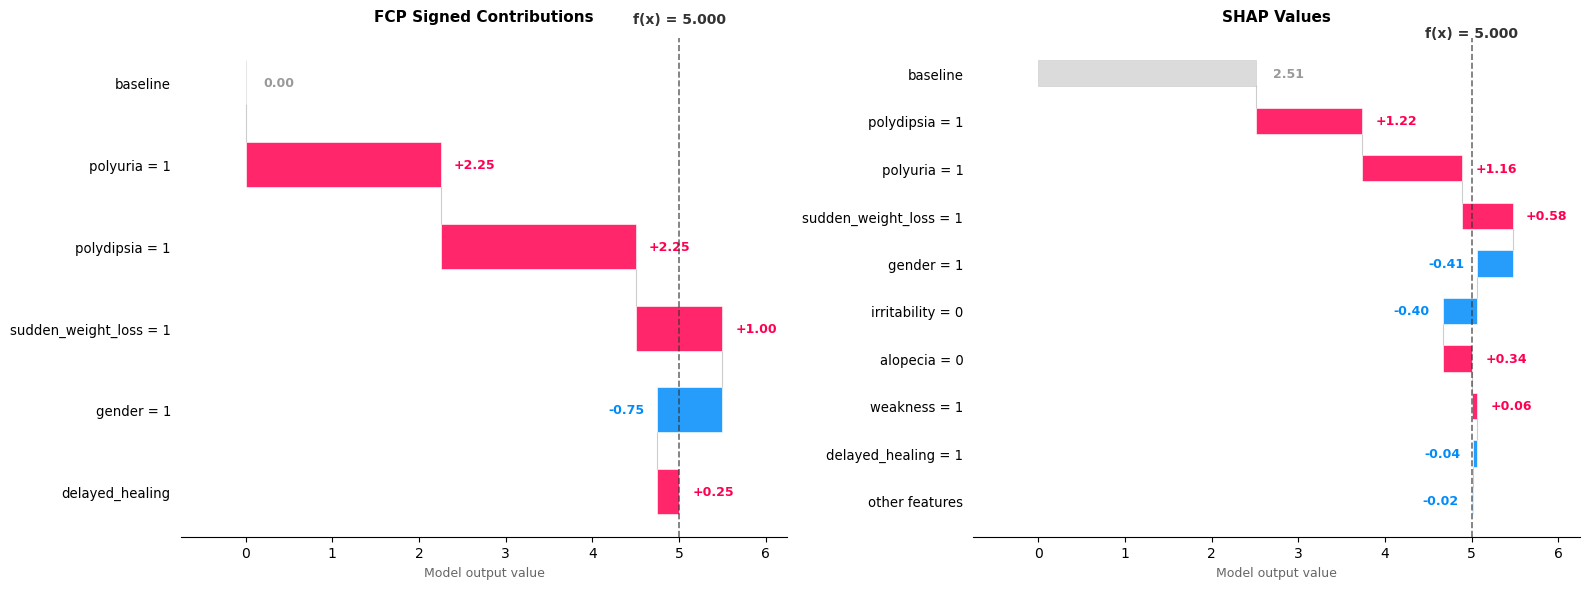

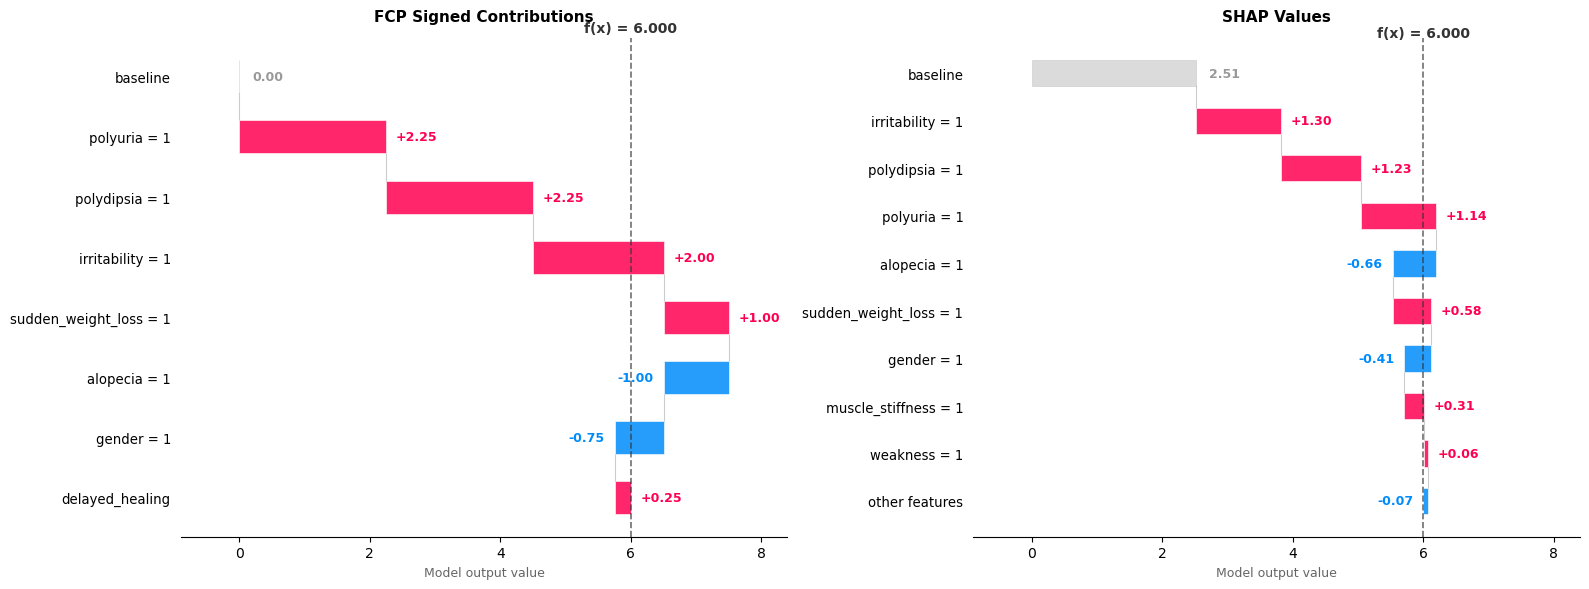

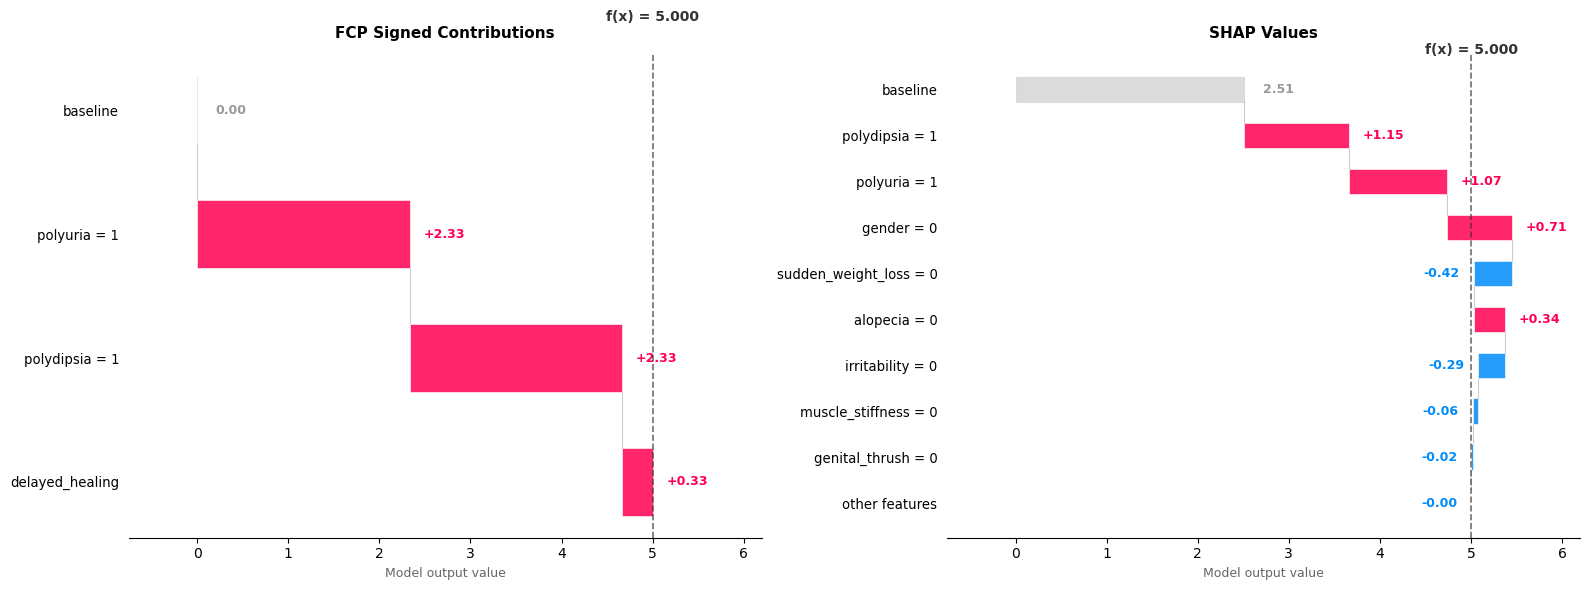

In [ ]:
import shap
import numpy as np
from deap import gp
from fcp_waterfall import plot_fcp_vs_shap, make_fcp_shap_comparison

make_fcp_shap_comparison(results_d, X_test_d, info_d)

 ---
 # Report Figure & Table Generation

 Run these cells AFTER all three experiments (german credit, concrete, diabetes)
 have completed and produced `results_g`, `results_c`, `results_d` etc.

 This generates:
 - Side-by-side FCP vs SHAP waterfall plots for each instance
 - Decision contribution plots for instances with conditionals
 - LaTeX tables for the report (dataset summary, GP config, performance, timing)

In [ ]:
# ── Imports and setup ────────────────────────────────────────────────

import os
import time
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

# Publication figure style
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Palatino", "Times New Roman", "DejaVu Serif"],
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.05,
})

POSITIVE_COLOR = "#d62728"
NEGATIVE_COLOR = "#1f77b4"
DECISION_COLOR = "#7b2d8e"

FIGURE_DIR = "./report_figures"
TABLE_DIR = "./report_tables"
os.makedirs(FIGURE_DIR, exist_ok=True)
os.makedirs(TABLE_DIR, exist_ok=True)

print(f"Figures will be saved to: {FIGURE_DIR}/")
print(f"Tables will be saved to:  {TABLE_DIR}/")


# %%
# ── Helper: extract attribution data from an explanation dict ────────

def extract_instance_data(explanation, X_test, feature_names, dataset_label=""):
    """
    Pull FCP signed contributions, decision contributions, and feature
    values out of a single explanation dict from run_experiment().

    Returns a flat dict ready for the plotting functions.
    """
    idx = explanation.get("instance_idx", 0)
    result = explanation["result"]       # EvaluationResult
    tv = result.output                   # TrackedValue
    sc = tv.signed_contributions         # SignedContributions

    # ── Value contributions (signed, sum to output) ──
    fcp_contribs = {}
    for name in feature_names:
        val = sc.contributions.get(name, 0.0)
        if abs(val) > 1e-10:
            fcp_contribs[name] = val
    fcp_baseline = sc.baseline

    # ── Decision contributions ──
    dc = tv.decision_contributions if hasattr(tv, "decision_contributions") else {}
    decision_contribs = {}
    if isinstance(dc, dict):
        for name in feature_names:
            val = dc.get(name, 0.0)
            if abs(val) > 1e-10:
                decision_contribs[name] = val

    # ── Decision margin (from the closest decision point) ──
    margin = None
    condition_desc = None
    if hasattr(result, "decisions") and result.decisions:
        critical = result.get_critical_decision() if hasattr(result, "get_critical_decision") else None
        if critical is not None:
            margin = getattr(critical, "distance_to_flip", None) or getattr(critical, "margin", None)

    # ── Feature values for this instance ──
    feature_values = {}
    for j, name in enumerate(feature_names):
        feature_values[name] = float(X_test[idx, j])

    output_value = result.output.value
    label = dataset_label or f"Instance {idx}"

    return {
        "idx": idx,
        "feature_values": feature_values,
        "fcp_contribs": fcp_contribs,
        "fcp_baseline": fcp_baseline,
        "decision_contribs": decision_contribs,
        "output_value": output_value,
        "prediction": explanation.get("prediction"),
        "prediction_label": explanation.get("prediction_label"),
        "score": explanation.get("score"),
        "true_label": explanation.get("true_label"),
        "margin": margin,
        "condition_desc": condition_desc,
        "label": label,
    }


# %%
# ── Helper: compute SHAP values for one instance ────────────────────

def compute_shap_for_instance(tree_str, pset, X_train, instance_row, feature_names,
                               n_samples=500):
    """
    Compute KernelSHAP values for a single instance.

    Parameters
    ----------
    tree_str : str
        String representation of the GP tree (str(best_tree)).
    pset : gp.PrimitiveSet
        The evolution primitive set (NOT tracked).
    X_train : np.ndarray
        Training data used as SHAP background.
    instance_row : np.ndarray
        Single instance (1-d array of feature values).
    feature_names : list of str
    n_samples : int
        Number of SHAP samples.

    Returns
    -------
    dict with 'shap_contribs' (dict) and 'shap_baseline' (float)
    """
    import shap
    from deap import gp

    func = gp.compile(gp.PrimitiveTree.from_string(tree_str, pset), pset)

    def model_fn(X):
        out = []
        for row in X:
            try:
                val = func(*row)
                out.append(val if np.isfinite(val) else 0.0)
            except Exception:
                out.append(0.0)
        return np.array(out)

    # Use a subsample of training data as background
    bg_size = min(100, len(X_train))
    bg_idx = np.random.choice(len(X_train), bg_size, replace=False)
    background = X_train[bg_idx]

    explainer = shap.KernelExplainer(model_fn, background)
    sv = explainer.shap_values(instance_row.reshape(1, -1), nsamples=n_samples)

    shap_contribs = {}
    for j, name in enumerate(feature_names):
        val = float(sv[0][j])
        if abs(val) > 1e-10:
            shap_contribs[name] = val

    return {
        "shap_contribs": shap_contribs,
        "shap_baseline": float(explainer.expected_value),
    }


# %%
# ── Waterfall plot function ──────────────────────────────────────────

def waterfall_plot(contributions, baseline, output_value,
                   feature_values=None, title="", max_features=10,
                   ax=None, positive_color=POSITIVE_COLOR,
                   negative_color=NEGATIVE_COLOR):
    """SHAP-style waterfall: baseline → contributions → output."""
    if ax is None:
        n_feats = min(len(contributions), max_features)
        fig, ax = plt.subplots(figsize=(5.5, max(3, 0.4 * n_feats + 1.5)))
    else:
        fig = ax.figure

    sorted_items = sorted(contributions.items(), key=lambda x: abs(x[1]), reverse=True)
    if len(sorted_items) > max_features:
        top = sorted_items[:max_features]
        rest = sum(v for _, v in sorted_items[max_features:])
        if abs(rest) > 1e-8:
            top.append(("other features", rest))
    else:
        top = sorted_items
    top = [(k, v) for k, v in top if abs(v) > 1e-6]

    n = len(top)
    bar_h = 0.55
    cumulative = baseline

    lefts, widths, colors, labels = [], [], [], []
    for name, contrib in top:
        lefts.append(min(cumulative, cumulative + contrib))
        widths.append(abs(contrib))
        colors.append(positive_color if contrib >= 0 else negative_color)
        if feature_values and name in feature_values:
            fv = feature_values[name]
            if isinstance(fv, float) and fv == int(fv):
                labels.append(f"{name} = {int(fv)}")
            elif isinstance(fv, float):
                labels.append(f"{name} = {fv:.2f}")
            else:
                labels.append(f"{name} = {fv}")
        else:
            labels.append(name)
        cumulative += contrib

    y_pos = list(range(n))
    ax.barh(y_pos, widths, left=lefts, height=bar_h,
            color=colors, edgecolor="white", linewidth=0.5)

    # Connecting dashes
    cum = baseline
    for i in range(n - 1):
        cum += top[i][1]
        ax.plot([cum, cum],
                [y_pos[i] + bar_h / 2, y_pos[i + 1] - bar_h / 2],
                color="#cccccc", linewidth=0.8, linestyle="--", zorder=0)

    # Value annotations inside bars
    for i, (name, contrib) in enumerate(top):
        ax.text(lefts[i] + widths[i] / 2, y_pos[i], f"{contrib:+.2f}",
                ha="center", va="center", fontsize=8, fontweight="bold",
                color="white")

    ax.set_yticks(y_pos)
    ax.set_yticklabels(labels)
    ax.invert_yaxis()
    ax.axvline(baseline, color="#999", linewidth=0.8, linestyle=":", zorder=0)
    ax.axvline(output_value, color="black", linewidth=0.8, linestyle=":", zorder=0)
    ax.text(baseline, n + 0.1, f"base = {baseline:.2f}",
            ha="center", va="top", fontsize=8, color="#999")
    ax.text(output_value, n + 0.5, f"f(x) = {output_value:.2f}",
            ha="center", va="top", fontsize=8, fontweight="bold")
    ax.set_ylim(n + 0.8, -0.5)
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("Output value")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    return fig


# %%
# ── Decision bar chart function ──────────────────────────────────────

def decision_bar_plot(decision_contribs, feature_values=None,
                      title="FCP Decision Contributions",
                      max_features=10, margin=None, ax=None):
    """Horizontal bars showing which features drove branching."""
    if ax is None:
        n = min(len(decision_contribs), max_features)
        fig, ax = plt.subplots(figsize=(5.5, max(2.5, 0.4 * n + 1)))
    else:
        fig = ax.figure

    items = sorted(decision_contribs.items(), key=lambda x: abs(x[1]), reverse=True)
    items = [(k, v) for k, v in items if abs(v) > 1e-6][:max_features]

    if not items:
        ax.text(0.5, 0.5, "No decision contributions\n(no conditional nodes)",
                ha="center", va="center", transform=ax.transAxes, fontsize=10, color="#999")
        ax.set_title(title, fontweight="bold")
        return fig

    names = [k for k, _ in items]
    vals = [v for _, v in items]
    labels = []
    for name in names:
        if feature_values and name in feature_values:
            fv = feature_values[name]
            if isinstance(fv, float) and fv == int(fv):
                labels.append(f"{name} = {int(fv)}")
            elif isinstance(fv, float):
                labels.append(f"{name} = {fv:.2f}")
            else:
                labels.append(f"{name} = {fv}")
        else:
            labels.append(name)

    y_pos = range(len(items))
    ax.barh(y_pos, vals, height=0.55, color=DECISION_COLOR, alpha=0.85,
            edgecolor="white", linewidth=0.5)
    for i, v in enumerate(vals):
        ax.text(v + max(vals) * 0.02, i, f"{v:.3f}", va="center", ha="left", fontsize=8)

    ax.set_yticks(y_pos)
    ax.set_yticklabels(labels)
    ax.invert_yaxis()
    ax.set_xlabel("Decision attribution")
    ax.set_title(title, fontweight="bold")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    if margin is not None:
        ax.text(0.98, 0.02, f"Decision margin: {margin:+.3f}",
                transform=ax.transAxes, ha="right", va="bottom", fontsize=8,
                bbox=dict(boxstyle="round,pad=0.3", facecolor="#f0e6f6",
                          edgecolor=DECISION_COLOR, alpha=0.8))
    return fig


# %%
# ── Master function: generate all figures for one dataset ────────────

def generate_dataset_figures(
    results,          # from run_experiment()
    config,           # GPConfig
    info,             # FeatureInfo / ConcreteFeatureInfo / etc.
    X_train,
    X_test,
    y_test,
    dataset_tag,      # short label: "german", "concrete", "diabetes"
    dataset_title,    # display name: "German Credit", etc.
    n_shap_samples=500,
):
    """
    Generate all comparison figures for one dataset.

    For each explained instance, produces:
    - Side-by-side FCP vs SHAP waterfall  (2-panel or 3-panel if decisions exist)
    - Standalone decision contribution plot (if applicable)

    Returns list of per-instance metadata dicts (for later table generation).
    """
    feature_names = info.names if hasattr(info, "names") else info.feature_names
    tree_str = str(results["best_tree"])
    pset = results["pset"]

    instance_records = []

    for i, explanation in enumerate(results["explanations"]):
        if "error" in explanation:
            print(f"  [{dataset_tag}] Instance {i}: skipped (error: {explanation['error']})")
            continue

        idx = explanation.get("instance_idx", i)
        print(f"  [{dataset_tag}] Instance {i} (idx={idx})...", end=" ")

        # ── Extract FCP data ──
        inst = extract_instance_data(explanation, X_test, feature_names,
                                     dataset_label=f"{dataset_title} — Instance {idx}")

        # ── Compute SHAP ──
        try:
            shap_data = compute_shap_for_instance(
                tree_str, pset, X_train, X_test[idx], feature_names,
                n_samples=n_shap_samples,
            )
        except Exception as e:
            print(f"SHAP failed ({e}), using zeros")
            shap_data = {"shap_contribs": {}, "shap_baseline": 0.0}

        has_decisions = bool(inst["decision_contribs"])

        # ── Build figure ──
        if has_decisions:
            # Three-panel: FCP value | SHAP | FCP decision
            fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 4.5))
            waterfall_plot(inst["fcp_contribs"], inst["fcp_baseline"],
                           inst["output_value"], feature_values=inst["feature_values"],
                           title="FCP Value Contributions", ax=ax1)
            waterfall_plot(shap_data["shap_contribs"], shap_data["shap_baseline"],
                           inst["output_value"], feature_values=inst["feature_values"],
                           title="SHAP Values", ax=ax2)
            decision_bar_plot(inst["decision_contribs"],
                              feature_values=inst["feature_values"],
                              margin=inst["margin"], ax=ax3)
            fig.suptitle(inst["label"], fontsize=12, fontweight="bold", y=1.02)
            fig.tight_layout()
        else:
            # Two-panel: FCP value | SHAP
            fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))
            waterfall_plot(inst["fcp_contribs"], inst["fcp_baseline"],
                           inst["output_value"], feature_values=inst["feature_values"],
                           title="FCP Value Contributions", ax=ax1)
            waterfall_plot(shap_data["shap_contribs"], shap_data["shap_baseline"],
                           inst["output_value"], feature_values=inst["feature_values"],
                           title="SHAP Values", ax=ax2)
            fig.suptitle(inst["label"], fontsize=12, fontweight="bold", y=1.02)
            fig.tight_layout()

        fname = f"{dataset_tag}_instance_{i}.pdf"
        fig.savefig(os.path.join(FIGURE_DIR, fname))
        plt.close(fig)
        print(f"saved {fname}", end="")

        # ── Save tree visualisation as PNG ──
        png_saved = False
        svg_str = None

        # Try results['svgs'] list first (parallel to explanations)
        if "svgs" in results and i < len(results["svgs"]) and results["svgs"][i]:
            svg_str = results["svgs"][i]
        # Fallback: try explanation['visualization'].to_svg()
        elif "visualization" in explanation:
            viz = explanation["visualization"]
            if hasattr(viz, "to_svg"):
                try:
                    svg_str = viz.to_svg()
                except Exception:
                    pass

        if svg_str:
            png_fname = f"{dataset_tag}_tree_{i}.png"
            try:
                import cairosvg
                cairosvg.svg2png(
                    bytestring=svg_str.encode("utf-8"),
                    write_to=os.path.join(FIGURE_DIR, png_fname),
                    scale=2,
                )
                png_saved = True
            except ImportError:
                # Fallback: save as SVG if cairosvg not available
                fallback = f"{dataset_tag}_tree_{i}.svg"
                with open(os.path.join(FIGURE_DIR, fallback), "w", encoding="utf-8") as f:
                    f.write(svg_str)
                png_fname = fallback
                png_saved = True
            except Exception as e:
                print(f"\n    PNG conversion failed ({e})", end="")

        if png_saved:
            print(f" + {png_fname}")
        else:
            print()

        # ── Record metadata ──
        inst["shap_contribs"] = shap_data["shap_contribs"]
        inst["shap_baseline"] = shap_data["shap_baseline"]
        inst["has_decisions"] = has_decisions
        inst["dataset"] = dataset_tag

        # ── Extract textual explanation and counterfactuals ──
        expl_obj = explanation.get("explanation")  # Explanation dataclass
        narrative_text = ""
        counterfactual_text = ""

        if expl_obj is not None:
            # Textual narrative
            if hasattr(expl_obj, "narrative"):
                try:
                    narrative_text = expl_obj.narrative()
                except Exception:
                    pass
            if not narrative_text and hasattr(expl_obj, "summary"):
                try:
                    narrative_text = expl_obj.summary()
                except Exception:
                    pass

            # Structured text fallback: build from primary_factors
            if not narrative_text and hasattr(expl_obj, "primary_factors"):
                lines = []
                pred = inst.get("prediction_label", str(inst["output_value"]))
                lines.append(f"Prediction: {pred} (score: {inst['output_value']:.2f})")
                lines.append("")
                lines.append("Key factors:")
                for f in expl_obj.primary_factors[:5]:
                    fv = inst["feature_values"].get(f.name, "?")
                    lines.append(f"  {f.name} = {fv} (importance: {f.importance:.0%})")
                if hasattr(expl_obj, "stability_score") and expl_obj.stability_score is not None:
                    lines.append(f"\nConfidence: {expl_obj.stability_score:.0%}")
                if hasattr(expl_obj, "critical_decision") and expl_obj.critical_decision is not None:
                    cd = expl_obj.critical_decision
                    obs = getattr(cd, "observation_source", "?")
                    thr = getattr(cd, "threshold_source", "?")
                    margin = getattr(cd, "margin", None) or getattr(cd, "distance_to_flip", None)
                    lines.append(f"Critical decision: {obs} vs {thr}")
                    if margin is not None:
                        lines.append(f"Margin: {margin:+.2f}")
                narrative_text = "\n".join(lines)

            # Counterfactuals (classification datasets only)
            # Verify each candidate by re-evaluating the tree with the
            # modified input to confirm the output actually flips.
            raw_cfs = []
            if hasattr(expl_obj, "counterfactuals") and expl_obj.counterfactuals:
                raw_cfs = expl_obj.counterfactuals
            elif hasattr(expl_obj, "easiest_counterfactual") and expl_obj.easiest_counterfactual:
                raw_cfs = [expl_obj.easiest_counterfactual]

            if raw_cfs and dataset_tag != "concrete":
                from deap import gp as gp_module
                original_output = inst["output_value"]
                original_sign = (original_output > 0)

                # Compile the tree for fast re-evaluation
                try:
                    compiled_func = gp_module.compile(results["best_tree"], results["pset"])
                except Exception:
                    compiled_func = None

                verified_cfs = []
                unverified_cfs = []

                for cf in raw_cfs:
                    if compiled_func is not None:
                        # Build modified input vector
                        modified_vals = dict(inst["feature_values"])
                        modified_vals[cf.feature] = cf.required_value
                        try:
                            new_output = compiled_func(
                                *[modified_vals.get(fn, 0.0) for fn in feature_names]
                            )
                            if not np.isfinite(new_output):
                                new_output = 0.0
                            new_sign = (new_output > 0)
                            flipped = (new_sign != original_sign)
                            verified_cfs.append({
                                "cf": cf,
                                "new_output": new_output,
                                "flipped": flipped,
                            })
                        except Exception:
                            unverified_cfs.append(cf)
                    else:
                        unverified_cfs.append(cf)

                # Build counterfactual text
                confirmed = [v for v in verified_cfs if v["flipped"]]
                not_confirmed = [v for v in verified_cfs if not v["flipped"]]

                cf_lines = []
                if confirmed:
                    cf_lines.append("Verified counterfactuals (output flips):")
                    for v in sorted(confirmed, key=lambda x: abs(x["cf"].change_magnitude)):
                        cf = v["cf"]
                        change = cf.required_value - cf.current_value
                        direction = "Increase" if change > 0 else "Decrease"
                        cf_lines.append(
                            f"  {direction} {cf.feature} from {cf.current_value:.2f} "
                            f"to {cf.required_value:.2f} (delta: {change:+.2f})"
                        )
                        cf_lines.append(
                            f"    Output: {original_output:.2f} -> {v['new_output']:.2f}"
                        )
                        if hasattr(cf, "description") and cf.description:
                            cf_lines.append(f"    ({cf.description})")

                if not_confirmed:
                    cf_lines.append("")
                    cf_lines.append("Branch-flipping changes (output does NOT flip):")
                    for v in sorted(not_confirmed, key=lambda x: abs(x["cf"].change_magnitude)):
                        cf = v["cf"]
                        change = cf.required_value - cf.current_value
                        direction = "Increase" if change > 0 else "Decrease"
                        cf_lines.append(
                            f"  {direction} {cf.feature} from {cf.current_value:.2f} "
                            f"to {cf.required_value:.2f} (delta: {change:+.2f})"
                        )
                        cf_lines.append(
                            f"    Output: {original_output:.2f} -> {v['new_output']:.2f} (same sign)"
                        )

                if unverified_cfs:
                    cf_lines.append("")
                    cf_lines.append("Unverified (could not re-evaluate):")
                    for cf in unverified_cfs:
                        change = cf.required_value - cf.current_value
                        direction = "Increase" if change > 0 else "Decrease"
                        cf_lines.append(
                            f"  {direction} {cf.feature} from {cf.current_value:.2f} "
                            f"to {cf.required_value:.2f} (delta: {change:+.2f})"
                        )

                counterfactual_text = "\n".join(cf_lines)

                # Store structured data for tables
                inst["verified_counterfactuals"] = confirmed
                inst["unverified_counterfactuals"] = not_confirmed

        inst["narrative"] = narrative_text
        inst["counterfactuals"] = counterfactual_text

        # ── Save textual explanation to file ──
        txt_fname = f"{dataset_tag}_instance_{i}_explanation.txt"
        txt_path = os.path.join(FIGURE_DIR, txt_fname)
        with open(txt_path, "w", encoding="utf-8") as f:
            f.write(f"{'=' * 60}\n")
            f.write(f"{inst['label']}\n")
            f.write(f"{'=' * 60}\n\n")
            f.write(f"True label: {inst.get('true_label', '?')}\n")
            f.write(f"Prediction: {inst.get('prediction_label', '?')} "
                    f"(score: {inst['output_value']:.2f})\n\n")

            f.write("--- FCP Value Contributions ---\n")
            for name, val in sorted(inst["fcp_contribs"].items(),
                                     key=lambda x: abs(x[1]), reverse=True):
                fv = inst["feature_values"].get(name, "?")
                f.write(f"  {name} = {fv}: {val:+.4f}\n")
            f.write(f"  Baseline: {inst['fcp_baseline']:.4f}\n")
            f.write(f"  Output:   {inst['output_value']:.4f}\n\n")

            if inst["decision_contribs"]:
                f.write("--- FCP Decision Contributions ---\n")
                for name, val in sorted(inst["decision_contribs"].items(),
                                         key=lambda x: abs(x[1]), reverse=True):
                    fv = inst["feature_values"].get(name, "?")
                    f.write(f"  {name} = {fv}: {val:.4f}\n")
                if inst.get("margin") is not None:
                    f.write(f"  Decision margin: {inst['margin']:+.3f}\n")
                f.write("\n")

            if narrative_text:
                f.write("--- Textual Explanation ---\n")
                f.write(narrative_text)
                f.write("\n\n")

            if counterfactual_text:
                f.write("--- Counterfactual Analysis ---\n")
                f.write(counterfactual_text)
                f.write("\n\n")

            f.write("--- SHAP Values (for comparison) ---\n")
            for name, val in sorted(shap_data.get("shap_contribs", {}).items(),
                                     key=lambda x: abs(x[1]), reverse=True):
                fv = inst["feature_values"].get(name, "?")
                f.write(f"  {name} = {fv}: {val:+.4f}\n")
            f.write(f"  Baseline: {shap_data.get('shap_baseline', 0):.4f}\n")

        print(f" + {txt_fname}")

        instance_records.append(inst)

    return instance_records


# %%
# ═══════════════════════════════════════════════════════════════════════
# SYNTHETIC PROBLEM VALIDATION
# ═══════════════════════════════════════════════════════════════════════
#
# Hand-crafted GP trees with known ground-truth attributions.
# Purpose: validate that FCP produces correct attributions when the
# answer is known by construction. No SHAP here — the comparison
# against SHAP belongs in the real-world experiments where it's
# meaningful (trained model, real data distribution).

print("=" * 60)
print("Synthetic problem validation")
print("=" * 60)

from fcp_tracker import (
    TrackedValue, SignedContributions, create_tracked_pset,
    evaluate_with_tracking,
)
from deap import gp

TOL = 0.01

synthetic_results = []


# ── Test 1: Additive ─────────────────────────────────────────────────

print("\n  1. Additive: x1 + x2 + x3")
pset_s1 = create_tracked_pset("s1", ["x1", "x2", "x3"])
tree_s1 = gp.PrimitiveTree.from_string("ADD(ADD(x1, x2), x3)", pset_s1)
inp_s1 = {"x1": 3.0, "x2": 5.0, "x3": -2.0}

r_s1 = evaluate_with_tracking(tree_s1, pset_s1, inp_s1)
sc_s1 = r_s1.output.signed_contributions
fcp_s1 = dict(sc_s1.contributions)
out_s1 = r_s1.output.value

gt_s1 = {"x1": 3.0, "x2": 5.0, "x3": -2.0}
fcp_ok_s1 = all(abs(fcp_s1.get(k, 0) - v) < TOL for k, v in gt_s1.items())
completeness_s1 = abs(sum(fcp_s1.values()) + sc_s1.baseline - out_s1) < TOL

print(f"     Output: {out_s1:.2f}  (expected 6.0)")
print(f"     FCP:  {fcp_s1}  baseline={sc_s1.baseline:.2f}")
print(f"     Ground truth: {gt_s1}")
print(f"     Correct: {fcp_ok_s1}  Completeness: {completeness_s1}")

synthetic_results.append({
    "name": "Additive",
    "tree_expr": "$x_1 + x_2 + x_3$",
    "tree_str": "ADD(ADD(x1, x2), x3)",
    "input": inp_s1,
    "output": out_s1,
    "fcp_contribs": fcp_s1,
    "fcp_baseline": sc_s1.baseline,
    "ground_truth": gt_s1,
    "fcp_correct": fcp_ok_s1,
    "completeness": completeness_s1,
    "decision_contribs": {},
    "notes": "Contributions pass through linearly; each feature's contribution equals its value.",
})


# ── Test 2: Multiplicative ───────────────────────────────────────────

print("\n  2. Multiplicative: x * y")
pset_s2 = create_tracked_pset("s2", ["x", "y"])
tree_s2 = gp.PrimitiveTree.from_string("MUL(x, y)", pset_s2)
inp_s2 = {"x": 2.0, "y": 3.0}

r_s2 = evaluate_with_tracking(tree_s2, pset_s2, inp_s2)
sc_s2 = r_s2.output.signed_contributions
fcp_s2 = dict(sc_s2.contributions)
out_s2 = r_s2.output.value

completeness_s2 = abs(sum(fcp_s2.values()) + sc_s2.baseline - out_s2) < TOL
fcp_ok_s2 = completeness_s2 and abs(out_s2 - 6.0) < TOL

# ANOVA: 2*3 = 1 + (2-1) + (3-1) + (2-1)(3-1) = 1 + 1 + 2 + 2 = 6
# baseline=1, x main effect=1, y main effect=2, interaction=2
# Interaction distributed proportionally across x and y
print(f"     Output: {out_s2:.2f}  (expected 6.0)")
print(f"     FCP:  {fcp_s2}  baseline={sc_s2.baseline:.2f}")
print(f"     ANOVA: base=1, x_main=1, y_main=2, interaction=2")
print(f"     Completeness: {completeness_s2}")

synthetic_results.append({
    "name": "Multiplicative",
    "tree_expr": "$x \\times y$",
    "tree_str": "MUL(x, y)",
    "input": inp_s2,
    "output": out_s2,
    "fcp_contribs": fcp_s2,
    "fcp_baseline": sc_s2.baseline,
    "ground_truth": {"note": "ANOVA: base=1 + main effects + interaction = 6"},
    "fcp_correct": fcp_ok_s2,
    "completeness": completeness_s2,
    "decision_contribs": {},
    "notes": "ANOVA decomposition; completeness verified. "
             "Interaction distributed proportionally across operands.",
})


# ── Test 3: Conditional (IF-THEN-ELSE) ───────────────────────────────

print("\n  3. Conditional: IF(x1 <= 0, x2, x3)  with x1=5")
pset_s3 = create_tracked_pset("s3", ["x1", "x2", "x3"])
pset_s3.addTerminal(TrackedValue.from_constant(0.0, "ZERO"), name="ZERO")

tree_s3 = gp.PrimitiveTree.from_string("IFLTE(x1, ZERO, x2, x3)", pset_s3)
inp_s3 = {"x1": 5.0, "x2": 10.0, "x3": -3.0}

r_s3 = evaluate_with_tracking(tree_s3, pset_s3, inp_s3)
sc_s3 = r_s3.output.signed_contributions
fcp_s3 = dict(sc_s3.contributions)
out_s3 = r_s3.output.value

dc_s3 = r_s3.output.decision_contributions if hasattr(r_s3.output, "decision_contributions") else {}
dc_s3 = dict(dc_s3) if isinstance(dc_s3, dict) else {}

# Ground truth: x1=5 > 0, so FALSE branch taken → output = x3 = -3
gt_val_s3 = {"x3": -3.0}
fcp_val_ok = abs(fcp_s3.get("x3", 0) - (-3.0)) < TOL
fcp_x2_zero = abs(fcp_s3.get("x2", 0)) < TOL
fcp_ok_s3 = fcp_val_ok and fcp_x2_zero
completeness_s3 = abs(sum(fcp_s3.values()) + sc_s3.baseline - out_s3) < TOL

dc_x1 = dc_s3.get("x1", 0)
decision_correct = dc_x1 > 0

print(f"     Output: {out_s3:.2f}  (expected -3.0, false branch)")
print(f"     FCP value:    {fcp_s3}  baseline={sc_s3.baseline:.2f}")
print(f"     FCP decision: {dc_s3}")
print(f"     Value correct: {fcp_ok_s3}  (x2 zero: {fcp_x2_zero})")
print(f"     Decision correct (x1 drives branch): {decision_correct}")
print(f"     Completeness: {completeness_s3}")

synthetic_results.append({
    "name": "Conditional",
    "tree_expr": "IF($x_1 \\leq 0$, $x_2$, $x_3$)",
    "tree_str": "IFLTE(x1, ZERO, x2, x3)",
    "input": inp_s3,
    "output": out_s3,
    "fcp_contribs": fcp_s3,
    "fcp_baseline": sc_s3.baseline,
    "ground_truth": gt_val_s3,
    "fcp_correct": fcp_ok_s3,
    "completeness": completeness_s3,
    "decision_correct": decision_correct,
    "decision_contribs": dc_s3,
    "notes": "Value from selected branch only (x3); "
             "unselected branch (x2) correctly gets zero. "
             "Decision channel identifies x1 as the branch driver.",
})


# ── Test 4: Irrelevant features ──────────────────────────────────────

print("\n  4. Irrelevant features: x1 + x2 (x3, x4 unused)")
pset_s4 = create_tracked_pset("s4", ["x1", "x2", "x3", "x4"])
tree_s4 = gp.PrimitiveTree.from_string("ADD(x1, x2)", pset_s4)
inp_s4 = {"x1": 7.0, "x2": -2.0, "x3": 100.0, "x4": -50.0}

r_s4 = evaluate_with_tracking(tree_s4, pset_s4, inp_s4)
sc_s4 = r_s4.output.signed_contributions
fcp_s4 = dict(sc_s4.contributions)
out_s4 = r_s4.output.value

fcp_x3_zero = abs(fcp_s4.get("x3", 0)) < TOL
fcp_x4_zero = abs(fcp_s4.get("x4", 0)) < TOL
fcp_ok_s4 = fcp_x3_zero and fcp_x4_zero
completeness_s4 = abs(sum(fcp_s4.values()) + sc_s4.baseline - out_s4) < TOL

print(f"     Output: {out_s4:.2f}  (expected 5.0)")
print(f"     FCP: {fcp_s4}")
print(f"     Irrelevant features: x3={fcp_s4.get('x3', 0):.6f}  x4={fcp_s4.get('x4', 0):.6f}")
print(f"     Correct (both zero): {fcp_ok_s4}  Completeness: {completeness_s4}")

synthetic_results.append({
    "name": "Irrelevant features",
    "tree_expr": "$x_1 + x_2$ ($x_3$, $x_4$ unused)",
    "tree_str": "ADD(x1, x2)",
    "input": inp_s4,
    "output": out_s4,
    "fcp_contribs": fcp_s4,
    "fcp_baseline": sc_s4.baseline,
    "ground_truth": {"x1": 7.0, "x2": -2.0, "x3": 0.0, "x4": 0.0},
    "fcp_correct": fcp_ok_s4,
    "completeness": completeness_s4,
    "decision_contribs": {},
    "notes": "Features not present in the tree receive exactly zero attribution.",
})


# ── Test 5: Nested conditionals ──────────────────────────────────────

print("\n  5. Nested conditionals: IF(x1<=0, IF(x2<=0, x3, x4), x5)")
pset_s5 = create_tracked_pset("s5", ["x1", "x2", "x3", "x4", "x5"])
pset_s5.addTerminal(TrackedValue.from_constant(0.0, "ZERO"), name="ZERO")
pset_s5.addTerminal(TrackedValue.from_constant(0.0, "ZERO2"), name="ZERO2")

tree_s5 = gp.PrimitiveTree.from_string(
    "IFLTE(x1, ZERO, IFLTE(x2, ZERO2, x3, x4), x5)", pset_s5
)
# x1=-1 <=0 → true branch → evaluate inner IF
# x2=2 > 0  → false branch → x4
inp_s5 = {"x1": -1.0, "x2": 2.0, "x3": 99.0, "x4": 7.0, "x5": -10.0}

r_s5 = evaluate_with_tracking(tree_s5, pset_s5, inp_s5)
sc_s5 = r_s5.output.signed_contributions
fcp_s5 = dict(sc_s5.contributions)
out_s5 = r_s5.output.value

dc_s5 = r_s5.output.decision_contributions if hasattr(r_s5.output, "decision_contributions") else {}
dc_s5 = dict(dc_s5) if isinstance(dc_s5, dict) else {}

fcp_val_ok_s5 = abs(fcp_s5.get("x4", 0) - 7.0) < TOL
fcp_x3_zero_s5 = abs(fcp_s5.get("x3", 0)) < TOL
fcp_x5_zero_s5 = abs(fcp_s5.get("x5", 0)) < TOL
completeness_s5 = abs(sum(fcp_s5.values()) + sc_s5.baseline - out_s5) < TOL

dc_x1_s5 = dc_s5.get("x1", 0)
dc_x2_s5 = dc_s5.get("x2", 0)
decision_both = dc_x1_s5 > 0 and dc_x2_s5 > 0

fcp_ok_s5 = fcp_val_ok_s5 and fcp_x3_zero_s5 and fcp_x5_zero_s5 and completeness_s5

print(f"     Output: {out_s5:.2f}  (expected 7.0, outer-true→inner-false→x4)")
print(f"     FCP value:    {fcp_s5}  baseline={sc_s5.baseline:.2f}")
print(f"     FCP decision: {dc_s5}")
print(f"     Path: outer(x1=-1≤0)→true, inner(x2=2>0)→false → x4=7")
print(f"     Value correct: {fcp_val_ok_s5}  Decision both: {decision_both}")
print(f"     Completeness: {completeness_s5}")

synthetic_results.append({
    "name": "Nested conditionals",
    "tree_expr": "IF($x_1 \\leq 0$, IF($x_2 \\leq 0$, $x_3$, $x_4$), $x_5$)",
    "tree_str": "IFLTE(x1, 0, IFLTE(x2, 0, x3, x4), x5)",
    "input": inp_s5,
    "output": out_s5,
    "fcp_contribs": fcp_s5,
    "fcp_baseline": sc_s5.baseline,
    "ground_truth": {"x4": 7.0, "x3": 0.0, "x5": 0.0},
    "fcp_correct": fcp_ok_s5,
    "completeness": completeness_s5,
    "decision_both_correct": decision_both,
    "decision_contribs": dc_s5,
    "notes": "Value only to x4 (selected path through both IFs). "
             "Decision contributions accumulate: x1 drove outer, x2 drove inner.",
})


# %%
# ── Generate synthetic FCP figures ────────────────────────────────────
# Single-panel value waterfall, plus decision bar chart where applicable.
# No SHAP — this section validates FCP against known ground truth.

print("\n── Saving synthetic FCP figures ──")

for sr in synthetic_results:
    tag = sr["name"].lower().replace(" ", "_")
    has_dc = bool(sr.get("decision_contribs"))

    if has_dc:
        # Two-panel: FCP value waterfall + decision bar chart
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
        waterfall_plot(sr["fcp_contribs"], sr["fcp_baseline"], sr["output"],
                       feature_values=sr["input"],
                       title="FCP Value Contributions", ax=ax1)
        decision_bar_plot(sr["decision_contribs"],
                          feature_values=sr["input"],
                          title="FCP Decision Contributions", ax=ax2)
        fig.suptitle(f"Synthetic: {sr['name']} — {sr['tree_expr']}",
                     fontsize=12, fontweight="bold", y=1.02)
    else:
        # Single-panel: FCP value waterfall only
        n_feats = max(len(sr["fcp_contribs"]), 1)
        fig, ax = plt.subplots(figsize=(6, max(3, 0.4 * n_feats + 1.5)))
        waterfall_plot(sr["fcp_contribs"], sr["fcp_baseline"], sr["output"],
                       feature_values=sr["input"],
                       title="FCP Value Contributions", ax=ax)
        fig.suptitle(f"Synthetic: {sr['name']} — {sr['tree_expr']}",
                     fontsize=12, fontweight="bold", y=1.02)

    fig.tight_layout()
    fname = f"synthetic_{tag}.pdf"
    fig.savefig(os.path.join(FIGURE_DIR, fname))
    plt.close(fig)
    print(f"  Saved {fname}")


# %%
# ── Generate synthetic validation LaTeX table ─────────────────────────

print("\n── Saving synthetic validation table ──")

synth_table_lines = [
    r"\begin{table}[ht]",
    r"  \centering",
    r"  \caption{Synthetic validation results. \emph{Value}: FCP attributions match "
    r"ground truth. \emph{Complete}: $\sum c_j + \beta = f(\mathbf{x})$. "
    r"\emph{Decision}: decision contributions correctly identify condition-driving features.}",
    r"  \label{tab:synthetic-validation}",
    r"  \footnotesize",
    r"  \begin{tabular}{@{}lp{3.8cm}rcccp{3.5cm}@{}}",
    r"    \toprule",
    r"    \textbf{Test Case} & \textbf{Expression} & \textbf{$f(\mathbf{x})$} "
    r"& \textbf{Value} & \textbf{Compl.} & \textbf{Decn.} & \textbf{Notes} \\",
    r"    \midrule",
]

for sr in synthetic_results:
    fcp_mark = r"$\checkmark$" if sr["fcp_correct"] else r"$\times$"
    comp_mark = r"$\checkmark$" if sr.get("completeness", False) else r"$\times$"

    # Decision column
    if sr.get("decision_contribs"):
        dc_ok = sr.get("decision_correct", sr.get("decision_both_correct", False))
        dc_mark = r"$\checkmark$" if dc_ok else r"$\times$"
    else:
        dc_mark = "---"

    # Short note for table
    note = sr.get("notes", "").split(".")[0]  # first sentence only
    if len(note) > 50:
        note = note[:47] + "..."

    synth_table_lines.append(
        f"    {sr['name']} & {sr['tree_expr']} & {sr['output']:.1f} "
        f"& {fcp_mark} & {comp_mark} & {dc_mark} & {note} \\\\"
    )

synth_table_lines += [
    r"    \bottomrule",
    r"  \end{tabular}",
    r"\end{table}",
]

synth_table_path = os.path.join(TABLE_DIR, "synthetic_validation.tex")
with open(synth_table_path, "w") as f:
    f.write("\n".join(synth_table_lines))
print(f"  Saved {synth_table_path}")

# Print summary
print(f"\n  Summary: {sum(1 for s in synthetic_results if s['fcp_correct'])}/{len(synthetic_results)} "
      f"FCP correct, "
      f"{sum(1 for s in synthetic_results if s.get('completeness', False))}/{len(synthetic_results)} "
      f"completeness verified")


# %%
# ═══════════════════════════════════════════════════════════════════════
# RUN: Generate figures for all 3 datasets
# ═══════════════════════════════════════════════════════════════════════

print("=" * 60)
print("Generating report figures")
print("=" * 60)

all_records = []

# ── German Credit ──
print("\n── German Credit ──")
records_g = generate_dataset_figures(
    results_g, config_g, info_g,
    X_train_g, X_test_g, y_test_g,
    dataset_tag="german",
    dataset_title="German Credit",
)
all_records.extend(records_g)

# ── Concrete Strength ──
print("\n── Concrete Strength ──")
records_c = generate_dataset_figures(
    results_c, config_c, info_c,
    X_train_c, X_test_c, y_test_c,
    dataset_tag="concrete",
    dataset_title="Concrete Compressive Strength",
)
all_records.extend(records_c)

# ── Diabetes Risk ──
print("\n── Diabetes Risk ──")
records_d = generate_dataset_figures(
    results_d, config_d, info_d,
    X_train_d, X_test_d, y_test_d,
    dataset_tag="diabetes",
    dataset_title="Diabetes Risk Prediction",
)
all_records.extend(records_d)

print(f"\nTotal figures generated: {len(all_records)}")


# %%
# ═══════════════════════════════════════════════════════════════════════
# TIMING COMPARISON: FCP vs SHAP
# ═══════════════════════════════════════════════════════════════════════

print("=" * 60)
print("Timing comparison: FCP vs SHAP")
print("=" * 60)

from fcp_tracker import create_tracked_pset, TrackedValue, evaluate_with_tracking
from deap import gp
import re

def time_fcp(results, config, X_test, feature_names, n_instances=50):
    """Time FCP explanation for n_instances."""
    tree_str = str(results["best_tree"])

    # Build tracked pset once
    tracked_pset = create_tracked_pset(
        "timing", feature_names,
        include_conditionals=True,
        include_comparisons=True,
    )
    # Register constants
    cmap = results["explanations"][0].get("constant_map", {})
    for name, val in cmap.items():
        try:
            tracked_pset.addTerminal(TrackedValue.from_constant(val, name), name=name)
        except Exception:
            pass

    # Preprocess tree string (register ephemeral constants)
    pattern = r'(?<![a-zA-Z_\d])(-?\d+\.?\d*(?:e[+-]?\d+)?)(?![a-zA-Z_\d])'
    ccount = [0]
    registered = {}
    def _replace(m):
        lit = m.group(1)
        if lit in registered:
            return registered[lit]
        val = float(lit)
        name = f"_K{ccount[0]}"
        ccount[0] += 1
        registered[lit] = name
        try:
            tracked_pset.addTerminal(TrackedValue.from_constant(val, name), name=name)
        except Exception:
            pass
        return name
    safe_str = re.sub(pattern, _replace, tree_str)

    try:
        tracked_tree = gp.PrimitiveTree.from_string(safe_str, tracked_pset)
    except Exception as e:
        print(f"  Could not parse tree for timing: {e}")
        return float("nan")

    n = min(n_instances, len(X_test))
    start = time.perf_counter()
    for i in range(n):
        instance = {fn: float(X_test[i, j]) for j, fn in enumerate(feature_names)}
        evaluate_with_tracking(tracked_tree, tracked_pset, instance)
    elapsed = time.perf_counter() - start
    return (elapsed / n) * 1000  # ms per instance


def time_shap(results, X_train, X_test, feature_names, n_instances=50, n_samples=500):
    """Time SHAP explanation for n_instances."""
    import shap
    tree_str = str(results["best_tree"])
    pset = results["pset"]
    func = gp.compile(gp.PrimitiveTree.from_string(tree_str, pset), pset)

    def model_fn(X):
        out = []
        for row in X:
            try:
                val = func(*row)
                out.append(val if np.isfinite(val) else 0.0)
            except Exception:
                out.append(0.0)
        return np.array(out)

    bg_size = min(100, len(X_train))
    bg_idx = np.random.choice(len(X_train), bg_size, replace=False)
    background = X_train[bg_idx]
    explainer = shap.KernelExplainer(model_fn, background)

    n = min(n_instances, len(X_test))
    start = time.perf_counter()
    for i in range(n):
        explainer.shap_values(X_test[i:i+1], nsamples=n_samples)
    elapsed = time.perf_counter() - start
    return (elapsed / n) * 1000  # ms per instance


feature_names_g = info_g.names if hasattr(info_g, "names") else info_g.feature_names
feature_names_c = info_c.names if hasattr(info_c, "names") else info_c.feature_names
feature_names_d = info_d.names if hasattr(info_d, "names") else info_d.feature_names

N_TIMING = 30  # instances to average over

print("\nTiming FCP...")
fcp_ms_g = time_fcp(results_g, config_g, X_test_g, feature_names_g, N_TIMING)
fcp_ms_c = time_fcp(results_c, config_c, X_test_c, feature_names_c, N_TIMING)
fcp_ms_d = time_fcp(results_d, config_d, X_test_d, feature_names_d, N_TIMING)

print("Timing SHAP...")
shap_ms_g = time_shap(results_g, X_train_g, X_test_g, feature_names_g, N_TIMING)
shap_ms_c = time_shap(results_c, X_train_c, X_test_c, feature_names_c, N_TIMING)
shap_ms_d = time_shap(results_d, X_train_d, X_test_d, feature_names_d, N_TIMING)

timing_data = {
    "german":   {"fcp": fcp_ms_g, "shap": shap_ms_g},
    "concrete": {"fcp": fcp_ms_c, "shap": shap_ms_c},
    "diabetes": {"fcp": fcp_ms_d, "shap": shap_ms_d},
}

print(f"\n{'Dataset':<15} {'FCP (ms)':>10} {'SHAP (ms)':>12} {'Speedup':>10}")
print("-" * 50)
for ds, t in timing_data.items():
    speedup = t["shap"] / t["fcp"] if t["fcp"] > 0 else float("inf")
    print(f"{ds:<15} {t['fcp']:>10.2f} {t['shap']:>12.1f} {speedup:>9.0f}x")


# %%
# ═══════════════════════════════════════════════════════════════════════
# GENERATE LATEX TABLES
# ═══════════════════════════════════════════════════════════════════════

print("=" * 60)
print("Generating LaTeX tables")
print("=" * 60)

# ── 1. Dataset summary table ─────────────────────────────────────────

dataset_table = r"""\begin{table}[ht]
  \centering
  \small
  \caption{Summary of datasets. Cost matrix entries (FN/FP) indicate misclassification penalties used in the GP fitness function.}
  \label{tab:datasets}
  \begin{tabular}{@{}lllccll@{}}
    \toprule
    \textbf{Dataset} & \textbf{Task} & \textbf{Features} & \textbf{Inst.} & \textbf{Cost (FN/FP)} & \textbf{Key Metric} & \textbf{FCP Focus} \\
    \midrule
    German Credit & Classification & 24 (mixed) & 1000 & 1 / 5 & Specificity & Decision ch. \\
    Concrete Strength & Regression & 8 continuous & 1030 & --- & $R^2$ & Value ch. \\
    Diabetes Risk & Classification & 15 binary + age & 520 & 2 / 1 & Sensitivity & Decision ch. \\
    \bottomrule
  \end{tabular}
\end{table}"""

with open(os.path.join(TABLE_DIR, "dataset_summary.tex"), "w") as f:
    f.write(dataset_table)
print("  Saved dataset_summary.tex")


# ── 2. GP configuration table ────────────────────────────────────────

def _cfg_val(config, key, default="---"):
    return getattr(config, key, default)

gp_rows = [
    ("Population size ($\\mu$)", _cfg_val(config_g, "mu"), _cfg_val(config_c, "mu"), _cfg_val(config_d, "mu")),
    ("Offspring ($\\lambda$)", _cfg_val(config_g, "lambda_"), _cfg_val(config_c, "lambda_"), _cfg_val(config_d, "lambda_")),
    ("Generations", _cfg_val(config_g, "generations"), _cfg_val(config_c, "generations"), _cfg_val(config_d, "generations")),
    ("Max tree depth", _cfg_val(config_g, "max_depth", 17), _cfg_val(config_c, "max_depth", 17), _cfg_val(config_d, "max_depth", 17)),
    ("Crossover prob.", _cfg_val(config_g, "cx_prob", 0.7), _cfg_val(config_c, "cx_prob", 0.7), _cfg_val(config_d, "cx_prob", 0.7)),
    ("Mutation prob.", _cfg_val(config_g, "mut_prob", 0.2), _cfg_val(config_c, "mut_prob", 0.2), _cfg_val(config_d, "mut_prob", 0.2)),
    ("Tournament size", _cfg_val(config_g, "tournament_size", 5), _cfg_val(config_c, "tournament_size", 5), _cfg_val(config_d, "tournament_size", 5)),
]

gp_table_lines = [
    r"\begin{table}[ht]",
    r"  \centering",
    r"  \caption{GP evolution configuration for each dataset. Cost matrix entries denote misclassification penalties: FN = false negative, FP = false positive.}",
    r"  \label{tab:gp-config}",
    r"  \begin{tabular}{@{}lccc@{}}",
    r"    \toprule",
    r"    \textbf{Parameter} & \textbf{German Credit} & \textbf{Concrete} & \textbf{Diabetes} \\",
    r"    \midrule",
]
for label, gv, cv, dv in gp_rows:
    gp_table_lines.append(f"    {label} & {gv} & {cv} & {dv} \\\\")
# Add fitness function rows with cost matrix detail
gp_table_lines += [
    r"    \midrule",
    r"    Fitness function & Cost matrix & MSE & Cost matrix \\",
    r"    Cost: FN & 1 & --- & 2 \\",
    r"    Cost: FP & 5 & --- & 1 \\",
    r"    Key metric & Specificity & $R^2$ & Sensitivity \\",
    r"    \bottomrule",
    r"  \end{tabular}",
    r"\end{table}",
]

with open(os.path.join(TABLE_DIR, "gp_config.tex"), "w") as f:
    f.write("\n".join(gp_table_lines))
print("  Saved gp_config.tex")


# ── 3. Model performance table ───────────────────────────────────────
# German Credit: FN=1, FP=5  → specificity (avoiding FP) is critical
# Diabetes:      FN=2, FP=1  → sensitivity/recall (avoiding FN) is critical
# Concrete:      regression   → RMSE, R²

def _tree_size(results):
    return len(results["best_tree"])

mg = results_g.get("test_metrics", {})
mc = results_c.get("test_metrics", {})
md = results_d.get("test_metrics", {})

# Compute cost-specific metrics if not already present
# Specificity = TN / (TN + FP) — German Credit cares about this (FP cost=5)
# Sensitivity = TP / (TP + FN) — Diabetes cares about this (FN cost=2)
# Total cost = FN_count * FN_cost + FP_count * FP_cost

def _get_or_compute(metrics, key, fallback=0):
    """Safely get a metric, returning fallback if missing."""
    val = metrics.get(key, fallback)
    return val if val is not None else fallback

perf_lines = [
    r"\begin{table}[ht]",
    r"  \centering",
    r"  \caption{Performance of evolved GP models on held-out test sets. "
    r"For classification datasets, the key metric reflects the cost matrix used "
    r"during evolution: specificity for German Credit (FP cost = 5) and "
    r"sensitivity for Diabetes (FN cost = 2).}",
    r"  \label{tab:performance}",
    r"  \begin{tabular}{@{}llcc@{}}",
    r"    \toprule",
    r"    \textbf{Dataset} & \textbf{Metric} & \textbf{Value} & \textbf{Tree Size} \\",
    r"    \midrule",
    # ── German Credit (FN=1, FP=5 → specificity matters) ──
    f"    \\multirow{{4}}{{*}}{{German Credit}} "
    f"& Accuracy & {_get_or_compute(mg, 'accuracy'):.1%} "
    f"& \\multirow{{4}}{{*}}{{{_tree_size(results_g)} nodes}} \\\\",
    f"    & \\textbf{{Specificity}} & \\textbf{{{_get_or_compute(mg, 'specificity'):.1%}}} & \\\\",
    f"    & Sensitivity & {_get_or_compute(mg, 'sensitivity', _get_or_compute(mg, 'recall')):.1%} & \\\\",
    f"    & Total cost & {_get_or_compute(mg, 'total_cost', '---')} & \\\\",
    r"    \midrule",
    # ── Concrete (regression) ──
    f"    \\multirow{{3}}{{*}}{{Concrete}} "
    f"& RMSE (MPa) & {_get_or_compute(mc, 'rmse'):.2f} "
    f"& \\multirow{{3}}{{*}}{{{_tree_size(results_c)} nodes}} \\\\",
    f"    & MAE (MPa) & {_get_or_compute(mc, 'mae'):.2f} & \\\\",
    f"    & $R^2$ & {_get_or_compute(mc, 'r2'):.3f} & \\\\",
    r"    \midrule",
    # ── Diabetes (FN=2, FP=1 → sensitivity matters) ──
    f"    \\multirow{{4}}{{*}}{{Diabetes}} "
    f"& Accuracy & {_get_or_compute(md, 'accuracy'):.1%} "
    f"& \\multirow{{4}}{{*}}{{{_tree_size(results_d)} nodes}} \\\\",
    f"    & \\textbf{{Sensitivity}} & \\textbf{{{_get_or_compute(md, 'sensitivity', _get_or_compute(md, 'recall')):.1%}}} & \\\\",
    f"    & Specificity & {_get_or_compute(md, 'specificity'):.1%} & \\\\",
    f"    & Total cost & {_get_or_compute(md, 'total_cost', '---')} & \\\\",
    r"    \bottomrule",
    r"  \end{tabular}",
    r"\end{table}",
]

with open(os.path.join(TABLE_DIR, "performance.tex"), "w") as f:
    f.write("\n".join(perf_lines))
print("  Saved performance.tex")


# ── 4. Timing comparison table ────────────────────────────────────────

timing_lines = [
    r"\begin{table}[ht]",
    r"  \centering",
    r"  \caption{Per-instance explanation time: FCP (single forward pass) vs KernelSHAP (500 samples). Averaged over 30 test instances.}",
    r"  \label{tab:timing}",
    r"  \begin{tabular}{@{}lccc@{}}",
    r"    \toprule",
    r"    \textbf{Dataset} & \textbf{FCP (ms)} & \textbf{SHAP (ms)} & \textbf{Speedup} \\",
    r"    \midrule",
]
for ds_name, ds_key in [("German Credit", "german"), ("Concrete", "concrete"), ("Diabetes", "diabetes")]:
    t = timing_data[ds_key]
    sp = t["shap"] / t["fcp"] if t["fcp"] > 0 else float("inf")
    timing_lines.append(f"    {ds_name} & {t['fcp']:.2f} & {t['shap']:.1f} & {sp:.0f}$\\times$ \\\\")
timing_lines += [
    r"    \bottomrule",
    r"  \end{tabular}",
    r"\end{table}",
]

with open(os.path.join(TABLE_DIR, "timing.tex"), "w") as f:
    f.write("\n".join(timing_lines))
print("  Saved timing.tex")


# ── 5. Instance explanation summary table ─────────────────────────────

inst_lines = [
    r"\begin{table}[ht]",
    r"  \centering",
    r"  \footnotesize",
    r"  \caption{Instance-level explanation summary. Top-1 features for FCP value, FCP decision, and SHAP.}",
    r"  \label{tab:instance-summary}",
    r"  \begin{tabular}{@{}llrp{2.5cm}p{2.5cm}p{2.5cm}c@{}}",
    r"    \toprule",
    r"    \textbf{Dataset} & \textbf{Inst.} & \textbf{$f(x)$} & \textbf{FCP Value} & \textbf{FCP Decision} & \textbf{SHAP} & \textbf{Agree} \\",
    r"    \midrule",
]

for rec in all_records:
    ds = rec["dataset"].capitalize()
    idx = rec["idx"]
    output = rec["output_value"]

    # Top FCP value contributor
    fcp_top = max(rec["fcp_contribs"].items(), key=lambda x: abs(x[1]), default=("---", 0))
    fcp_top_str = f"{fcp_top[0]} ({fcp_top[1]:+.2f})"

    # Top FCP decision contributor
    if rec["decision_contribs"]:
        dc_top = max(rec["decision_contribs"].items(), key=lambda x: abs(x[1]), default=("---", 0))
        dc_top_str = f"{dc_top[0]} ({dc_top[1]:.3f})"
    else:
        dc_top_str = "---"

    # Top SHAP contributor
    if rec.get("shap_contribs"):
        shap_top = max(rec["shap_contribs"].items(), key=lambda x: abs(x[1]), default=("---", 0))
        shap_top_str = f"{shap_top[0]} ({shap_top[1]:+.2f})"
    else:
        shap_top_str = "---"

    # Agreement: do FCP and SHAP agree on the top feature?
    agree = fcp_top[0] == (max(rec.get("shap_contribs", {}).items(), key=lambda x: abs(x[1]), default=("", 0))[0]) if rec.get("shap_contribs") else False
    agree_str = r"$\checkmark$" if agree else r"$\times$"

    # Escape underscores
    fcp_top_str = fcp_top_str.replace("_", r"\_")
    dc_top_str = dc_top_str.replace("_", r"\_")
    shap_top_str = shap_top_str.replace("_", r"\_")

    inst_lines.append(f"    {ds} & {idx} & {output:.2f} & {fcp_top_str} & {dc_top_str} & {shap_top_str} & {agree_str} \\\\")

inst_lines += [
    r"    \bottomrule",
    r"  \end{tabular}",
    r"\end{table}",
]

with open(os.path.join(TABLE_DIR, "instance_summary.tex"), "w") as f:
    f.write("\n".join(inst_lines))
print("  Saved instance_summary.tex")

print("\n" + "=" * 60)
print("All tables and figures generated!")
print(f"  Figures: {FIGURE_DIR}/")
print(f"  Tables:  {TABLE_DIR}/")
print("=" * 60)

Figures will be saved to: ./report_figures/
Tables will be saved to:  ./report_tables/
Synthetic problem validation

  1. Additive: x1 + x2 + x3
     Output: 6.00  (expected 6.0)
     FCP:  {'x1': 3.0, 'x2': 5.0, 'x3': -2.0}  baseline=0.00
     Ground truth: {'x1': 3.0, 'x2': 5.0, 'x3': -2.0}
     Correct: True  Completeness: True

  2. Multiplicative: x * y
     Output: 6.00  (expected 6.0)
     FCP:  {'x': 1.8, 'y': 3.2}  baseline=1.00
     ANOVA: base=1, x_main=1, y_main=2, interaction=2
     Completeness: True

  3. Conditional: IF(x1 <= 0, x2, x3)  with x1=5
     Output: -3.00  (expected -3.0, false branch)
     FCP value:    {'x3': -3.0}  baseline=0.00
     FCP decision: {'x1': 1.0}
     Value correct: True  (x2 zero: True)
     Decision correct (x1 drives branch): True
     Completeness: True

  4. Irrelevant features: x1 + x2 (x3, x4 unused)
     Output: 5.00  (expected 5.0)
     FCP: {'x1': 7.0, 'x2': -2.0}
     Irrelevant features: x3=0.000000  x4=0.000000
     Correct (both 

  0%|          | 0/1 [00:00<?, ?it/s]

saved german_instance_0.pdf + german_tree_0.png
 + german_instance_0_explanation.txt
  [german] Instance 1 (idx=1)... 

  0%|          | 0/1 [00:00<?, ?it/s]

saved german_instance_1.pdf + german_tree_1.png
 + german_instance_1_explanation.txt
  [german] Instance 2 (idx=2)... 

  0%|          | 0/1 [00:00<?, ?it/s]

saved german_instance_2.pdf + german_tree_2.png
 + german_instance_2_explanation.txt

── Concrete Strength ──
  [concrete] Instance 0 (idx=0)... 

  0%|          | 0/1 [00:00<?, ?it/s]

saved concrete_instance_0.pdf + concrete_tree_0.png
 + concrete_instance_0_explanation.txt
  [concrete] Instance 1 (idx=1)... 

  0%|          | 0/1 [00:00<?, ?it/s]

saved concrete_instance_1.pdf + concrete_tree_1.png
 + concrete_instance_1_explanation.txt
  [concrete] Instance 2 (idx=2)... 

  0%|          | 0/1 [00:00<?, ?it/s]

saved concrete_instance_2.pdf + concrete_tree_2.png
 + concrete_instance_2_explanation.txt

── Diabetes Risk ──
  [diabetes] Instance 0 (idx=0)... 

  0%|          | 0/1 [00:00<?, ?it/s]

saved diabetes_instance_0.pdf + diabetes_tree_0.png
 + diabetes_instance_0_explanation.txt
  [diabetes] Instance 1 (idx=1)... 

  0%|          | 0/1 [00:00<?, ?it/s]

saved diabetes_instance_1.pdf + diabetes_tree_1.png
 + diabetes_instance_1_explanation.txt
  [diabetes] Instance 2 (idx=2)... 

  0%|          | 0/1 [00:00<?, ?it/s]

saved diabetes_instance_2.pdf + diabetes_tree_2.png
 + diabetes_instance_2_explanation.txt

Total figures generated: 9
Timing comparison: FCP vs SHAP

Timing FCP...
Timing SHAP...


  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]


Dataset           FCP (ms)    SHAP (ms)    Speedup
--------------------------------------------------
german                0.26        500.6      1949x
concrete              0.37        136.2       369x
diabetes              0.26        235.3       902x
Generating LaTeX tables
  Saved dataset_summary.tex
  Saved gp_config.tex
  Saved performance.tex
  Saved timing.tex
  Saved instance_summary.tex

All tables and figures generated!
  Figures: ./report_figures/
  Tables:  ./report_tables/


In [ ]:
from fcp_tracker import synthesize_explanation

e1 = results_g["explanations"][1]
r1 = e1["result"]
idx1 = e1["instance_idx"]
feature_names = info_g.names if hasattr(info_g, "names") else info_g.feature_names
tv1 = {fn: float(X_test_g[idx1, j]) for j, fn in enumerate(feature_names)}
tv1.update(e1["constant_map"])

expl1 = synthesize_explanation(
    r1,
    terminal_values=tv1,
    constant_names=list(e1["constant_map"].keys()),
)
print(f"Counterfactuals: {len(expl1.counterfactuals)}")
for cf in expl1.counterfactuals:
    print(f"  {cf.feature}: {cf.current_value} -> {cf.required_value} ({cf.description})")

Counterfactuals: 7
  other_installments: 0.0 -> 1.000000001 (Flip decision by changing: other_installments)
  checking_status: 0.0 -> 1.000000001 (Flip decision: checking_status <= num_dependents)
  num_dependents: 1.0 -> -1e-09 (Flip decision by changing: num_dependents)
  other_debtors: 0.0 -> 2.000000001 (Flip decision: other_debtors <= num_credits)
  num_credits: 2.0 -> -1e-09 (Flip decision by changing: num_credits)
  other_installments: 0.0 -> 4.0 (Flip decision: other_installments < residence_years)
  residence_years: 4.0 -> -1e-09 (Flip decision by changing: residence_years)
